Running: geom=triangle SDF R-function | n=2 | H=32
Running: geom=triangle SDF R-function | n=2 | H=64
Running: geom=triangle SDF R-function | n=2 | H=128
Running: geom=triangle SDF R-function | n=3 | H=32
Running: geom=triangle SDF R-function | n=3 | H=64
Running: geom=triangle SDF R-function | n=3 | H=128
Running: geom=triangle SDF R-function | n=4 | H=32
Running: geom=triangle SDF R-function | n=4 | H=64
Running: geom=triangle SDF R-function | n=4 | H=128
Running: geom=triangle SDF 90 deg R-function | n=2 | H=32
Running: geom=triangle SDF 90 deg R-function | n=2 | H=64
Running: geom=triangle SDF 90 deg R-function | n=2 | H=128
Running: geom=triangle SDF 90 deg R-function | n=3 | H=32
Running: geom=triangle SDF 90 deg R-function | n=3 | H=64
Running: geom=triangle SDF 90 deg R-function | n=3 | H=128
Running: geom=triangle SDF 90 deg R-function | n=4 | H=32
Running: geom=triangle SDF 90 deg R-function | n=4 | H=64
Running: geom=triangle SDF 90 deg R-function | n=4 | H=128
Running: geom

C:\Users\csapo\AppData\Local\Temp\ipykernel_2612\2989132661.py:441: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cf.collections:


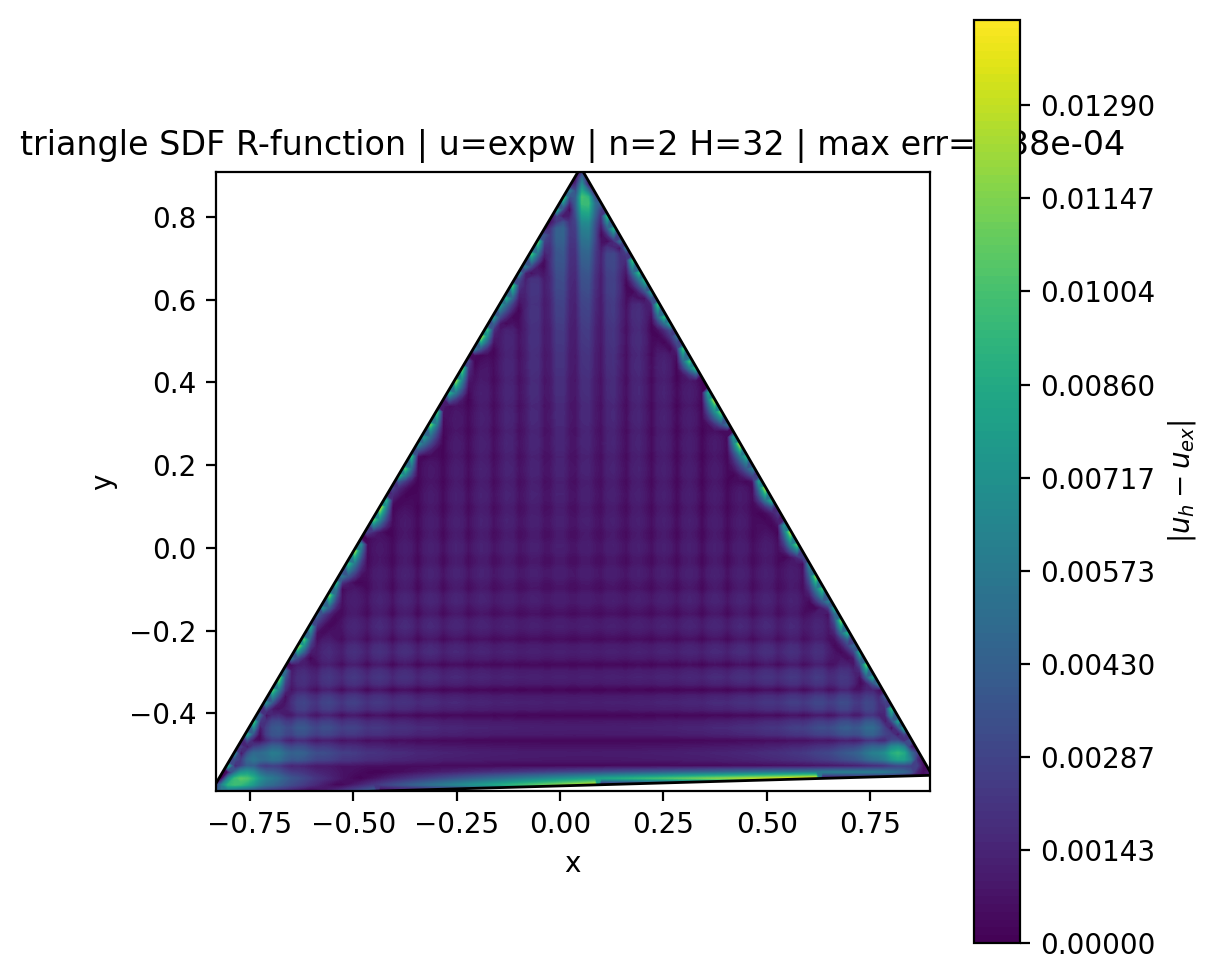

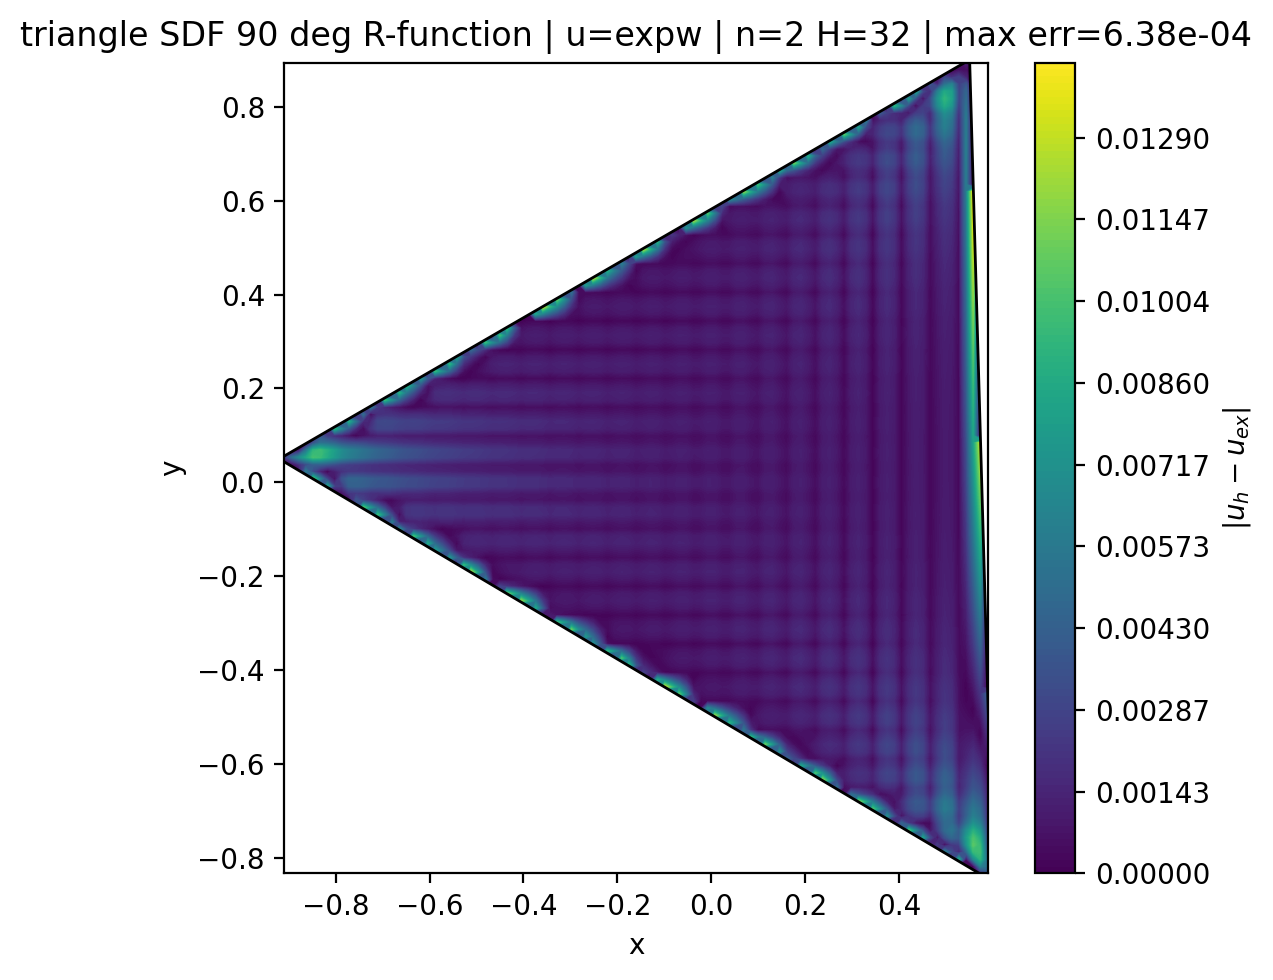

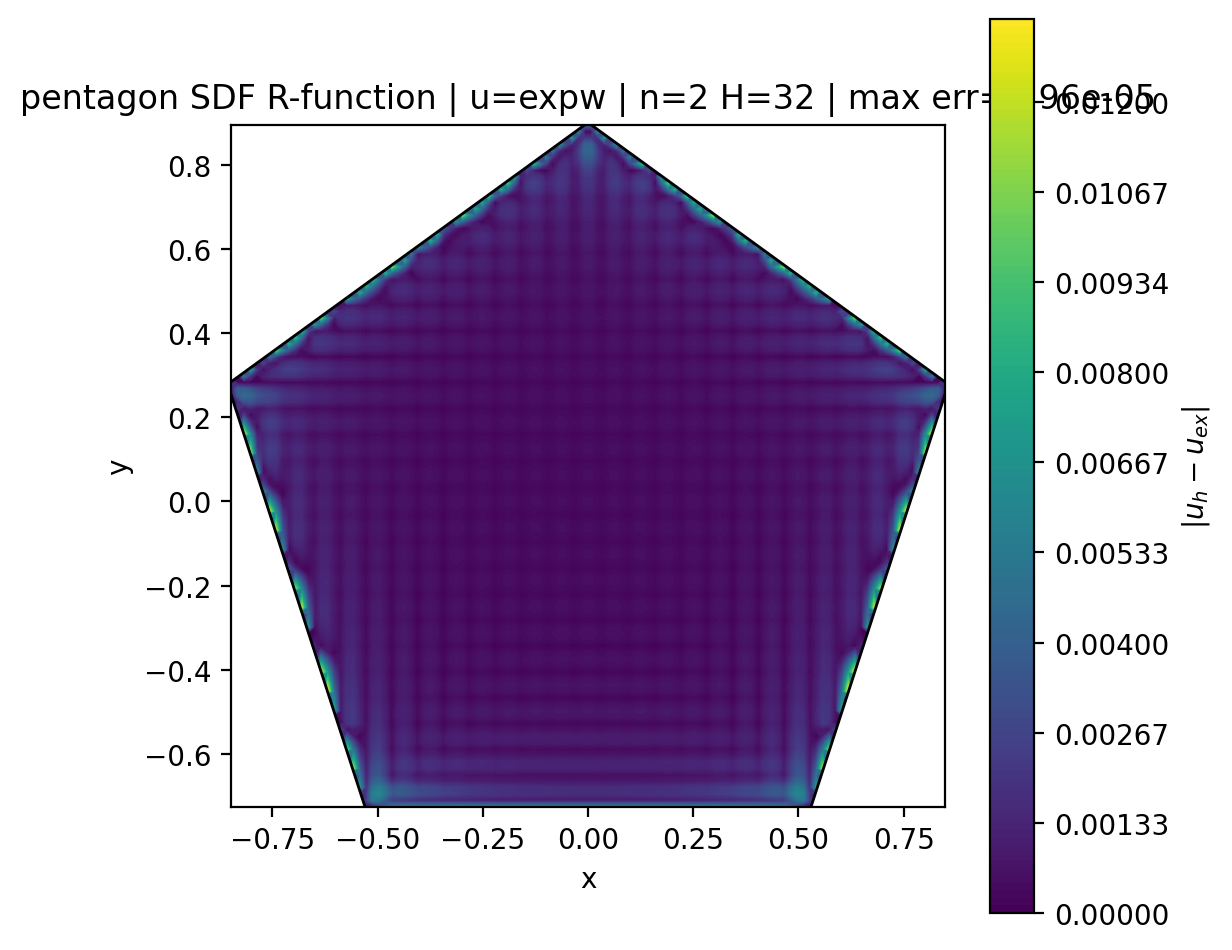

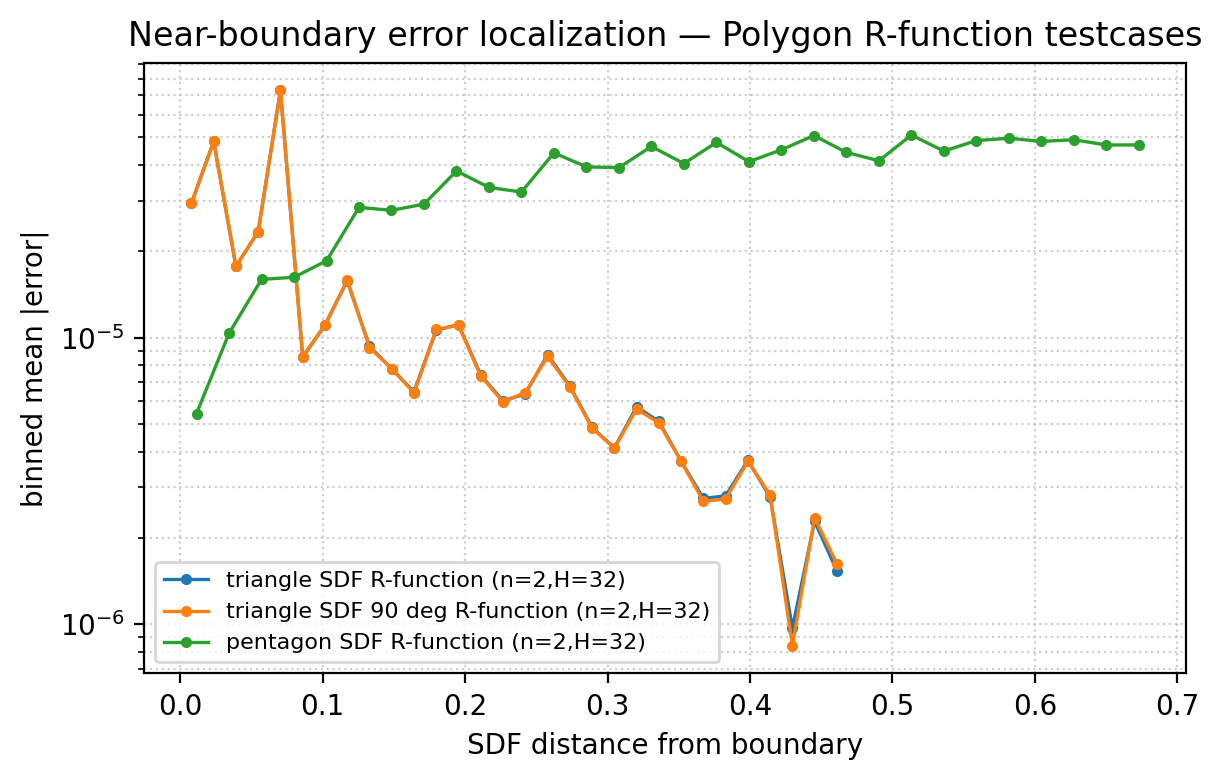

Max error (inside Ω):


n                                      2                             3  \
H                                    32        64        128       32    
geom                                                                     
pentagon SDF R-function         0.000060  0.000019  0.000005  0.000088   
triangle SDF 90 deg R-function  0.000638  0.000014  0.000009  0.000809   
triangle SDF R-function         0.000638  0.000014  0.000008  0.000530   

n                                                          4            \
H                                    64        128       32        64    
geom                                                                     
pentagon SDF R-function         0.000046  0.000007  0.000027  0.000012   
triangle SDF 90 deg R-function  0.000031  0.000005  0.009068  0.000016   
triangle SDF R-function         0.000029  0.000005  0.008110  0.000017   

n                                         
H                                    128  
geom                                      
pentagon SDF R-function         0.000004  
triangle SDF 90 deg R-function  0.000016  
triangle SDF R-function         0.000016

Mean error (inside Ω):


n                                      2                                 3  \
H                                    32        64            128       32    
geom                                                                         
pentagon SDF R-function         0.000032  0.000010  2.646008e-06  0.000040   
triangle SDF 90 deg R-function  0.000016  0.000001  4.123247e-07  0.000024   
triangle SDF R-function         0.000016  0.000002  4.106997e-07  0.000015   

n                                                              4  \
H                                    64            128       32    
geom                                                               
pentagon SDF R-function         0.000011  2.868531e-06  0.000003   
triangle SDF 90 deg R-function  0.000002  4.569823e-07  0.000129   
triangle SDF R-function         0.000002  4.567434e-07  0.000115   

n                                                           
H                                        64            128  
geom                                                        
pentagon SDF R-function         2.173327e-07  2.169005e-08  
triangle SDF 90 deg R-function  1.282468e-07  1.240424e-08  
triangle SDF R-function         2.125535e-07  1.117995e-07

In [10]:
# %% [markdown]
# # Local error distribution study (Collocation)
#
# This notebook mirrors the *local error distribution* workflow used for the FEM/WEB study,
# but uses the WEB-spline **collocation** solver (`collocation_WEB.collocation_2d`).
#
# Key differences vs FEM/WEB weak form:
# - There is **no** `MAX_SUBDIVISION` in collocation.
# - For some geometries we compare **multiple implicit/weight functions** for the same shape
#   (e.g. circle: “distance-like” vs smooth polynomial; L-shape: R-function variants).
#
# We solve manufactured problems of the form:
# - Domain: $\Omega = \{ (x,y): w(x,y) > 0 \}$
# - PDE: $-\Delta u = f$ in $\Omega$, with $u=0$ on $\partial\Omega$
#
# Important numerical note:
# - The collocation operator uses $w, w_x, w_y, w_{xx}, w_{yy}$. If the weight is not sufficiently
#   smooth (e.g. a raw Euclidean distance with a cusp), accuracy can degrade badly. For that reason,
#   we include a *regularized* distance-like circle variant.

# %%
import os
import sys
from dataclasses import dataclass
from typing import Callable, Dict, Optional, Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

# Optional: used only for higher-resolution plotting (upsampling)
try:
    from scipy.interpolate import RectBivariateSpline
except Exception:
    RectBivariateSpline = None

# Allow importing modules from the "Neural Analysis" folder (not a Python package).
NA_DIR = os.path.join(os.getcwd(), "Neural Analysis")
if NA_DIR not in sys.path:
    sys.path.insert(0, NA_DIR)

import collocation_WEB as colloc
import Geomertry as geom

# Ensure the latest geometry code is used (handy while iterating).
import importlib
importlib.reload(geom)
importlib.reload(colloc)

plt.rcParams.update({"figure.dpi": 200})

# %%
# Reproducibility
np.random.seed(0)
torch.manual_seed(0)

# Toggle for quick validation runs
SMOKE = False

# Manufactured solution type.
# - "expw": u = exp(w) - 1  (non-polynomial; usually more informative)
# - "w2":   u = w^2         (can be near-exact for polynomial weights)
U_EXACT_TYPE = "expw"

# Heatmap plotting resolution improvements:
# - We upsample the solution grid for smoother contourf plots (purely for visualization).
# - We recompute u_ex and w on the upsampled grid so the mask and error cover Ω cleanly.
# - This does NOT change the numerical solution, only how we render it.
PLOT_UPSAMPLE = 4 if not SMOKE else 3
CONTOUR_LEVELS = 120

# Plot coverage behavior:
# - If True: plot the full rectangular *physical* domain used for the PDE (e.g. [-1,1]^2 or [0,1]^2)
#            so the contourf fully fills the plotting area.
# - If False: crop and mask to the implicit domain Ω (w>0).
PLOT_FULL_PHYSICAL_DOMAIN = False

# When not plotting full physical domain, crop tightly to Ω.
ZOOM_TO_DOMAIN = not PLOT_FULL_PHYSICAL_DOMAIN
ZOOM_PAD_FRAC = 0 #!0.01

# %%
def zero_fn(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    return np.zeros_like(np.asarray(x, dtype=np.float64))


@dataclass(frozen=True)
class GeometryVariant:
    name: str
    model: torch.nn.Module
    domain: Optional[Dict[str, float]]  # physical coords for PDE; if None, physical=[0,1]^2

def make_manufactured_problem(
    model: torch.nn.Module,
    u_type: str = "expw",
) -> Tuple[
    Callable[[np.ndarray, np.ndarray], np.ndarray],
    Callable[[np.ndarray, np.ndarray], np.ndarray],
    colloc.NeuralWeightFunction,
    ]:
    """Manufactured solution u_ex(w) with homogeneous Dirichlet on w=0.

    Returns f_phys, u_exact_phys, wfct_phys where derivatives are w.r.t the input coordinates.

    u_type:
      - "w2":   u = w^2,        f = -Δu = -[2|∇w|^2 + 2w Δw]
      - "expw": u = exp(w)-1,   f = -Δu = -exp(w)[|∇w|^2 + Δw]
    """
    wfct_phys = colloc.NeuralWeightFunction(model, domain=None, transform=None)

    if u_type == "w2":

        def u_exact_phys(xp: np.ndarray, yp: np.ndarray) -> np.ndarray:
            w, *_ = wfct_phys(xp, yp)
            return w**2

        def f_phys(xp: np.ndarray, yp: np.ndarray) -> np.ndarray:
            w, wx, wy, wxx, wyy = wfct_phys(xp, yp)
            lap_u = 2.0 * (wx**2 + wy**2) + 2.0 * w * (wxx + wyy)
            return -lap_u

    elif u_type == "expw":

        def u_exact_phys(xp: np.ndarray, yp: np.ndarray) -> np.ndarray:
            w, *_ = wfct_phys(xp, yp)
            return np.exp(w) - 1.0

        def f_phys(xp: np.ndarray, yp: np.ndarray) -> np.ndarray:
            w, wx, wy, wxx, wyy = wfct_phys(xp, yp)
            lap_u = np.exp(w) * (wx**2 + wy**2 + wxx + wyy)
            return -lap_u

    else:
        raise ValueError(f"Unknown U_EXACT_TYPE={u_type!r}. Use 'expw' or 'w2'.")

    return f_phys, u_exact_phys, wfct_phys


def transform_grid_to_physical(
    xg: np.ndarray,
    yg: np.ndarray,
    domain: Optional[Dict[str, float]],
) -> Tuple[np.ndarray, np.ndarray]:
    if domain is None:
        return np.asarray(xg, dtype=np.float64), np.asarray(yg, dtype=np.float64)
    sx = domain["x2"] - domain["x1"]
    sy = domain["y2"] - domain["y1"]
    xp = domain["x1"] + np.asarray(xg, dtype=np.float64) * sx
    yp = domain["y1"] + np.asarray(yg, dtype=np.float64) * sy
    return xp, yp


def compute_near_boundary_binning(
    w_inside: np.ndarray,
    err_inside: np.ndarray,
    n_bins: int = 30,
    w_max: Optional[float] = None,
) -> pd.DataFrame:
    w_inside = np.asarray(w_inside, dtype=np.float64).ravel()
    err_inside = np.asarray(err_inside, dtype=np.float64).ravel()

    mask = np.isfinite(w_inside) & np.isfinite(err_inside)
    w_inside = w_inside[mask]
    err_inside = err_inside[mask]

    if w_inside.size == 0:
        return pd.DataFrame({"w_mid": [], "err_mean": [], "count": []})

    if w_max is None:
        w_max = float(np.quantile(w_inside, 0.995))

    w_max = max(w_max, 1e-12)
    edges = np.linspace(0.0, w_max, n_bins + 1)

    rows = []
    for i in range(n_bins):
        a, b = edges[i], edges[i + 1]
        sel = (w_inside >= a) & (w_inside < b)
        if not np.any(sel):
            continue
        rows.append(
            {
                "w_mid": 0.5 * (a + b),
                "err_mean": float(np.mean(err_inside[sel])),
                "count": int(np.sum(sel)),
            }
        )

    return pd.DataFrame(rows)


def _upsample_tensor_grid(
    xP: np.ndarray,
    yP: np.ndarray,
    field: np.ndarray,
    factor: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Upsample a field defined on a tensor-product grid for prettier contourf plots.

    Handles both meshgrid conventions (indexing='xy' and indexing='ij') by detecting
    which axis x/y vary along.
    """
    if factor <= 1:
        return xP, yP, field
    if RectBivariateSpline is None:
        # SciPy not available; fall back to original grid
        return xP, yP, field

    xP = np.asarray(xP, dtype=np.float64)
    yP = np.asarray(yP, dtype=np.float64)
    z = np.asarray(field, dtype=np.float64)

    x_row = xP[0, :]
    x_col = xP[:, 0]
    y_row = yP[0, :]
    y_col = yP[:, 0]

    # Determine which axis corresponds to x variation
    x_row_unique = np.unique(np.round(x_row, 12)).size
    x_col_unique = np.unique(np.round(x_col, 12)).size
    x_var_axis = 1 if x_row_unique > x_col_unique else 0

    if x_var_axis == 1:
        # x varies along columns; y varies along rows
        x1d = x_row
        y1d = y_col
        z2d = z
    else:
        # x varies along rows; y varies along columns
        x1d = x_col
        y1d = y_row
        z2d = z.T

    # Ensure strictly increasing axes for spline evaluation
    x1d = np.asarray(x1d, dtype=np.float64)
    y1d = np.asarray(y1d, dtype=np.float64)

    if x1d[0] > x1d[-1]:
        x1d = x1d[::-1]
        z2d = z2d[:, ::-1]
    if y1d[0] > y1d[-1]:
        y1d = y1d[::-1]
        z2d = z2d[::-1, :]

    # If there are any duplicates (can happen due to roundoff), fall back safely
    if not (np.all(np.diff(x1d) > 0) and np.all(np.diff(y1d) > 0)):
        return xP, yP, field

    x_fine = np.linspace(float(x1d[0]), float(x1d[-1]), x1d.size * factor)
    y_fine = np.linspace(float(y1d[0]), float(y1d[-1]), y1d.size * factor)

    spl = RectBivariateSpline(y1d, x1d, z2d, kx=1, ky=1)
    z_fine = spl(y_fine, x_fine)
    xP_f, yP_f = np.meshgrid(x_fine, y_fine)
    return xP_f, yP_f, z_fine


def _zoom_axes_to_domain(ax, x: np.ndarray, y: np.ndarray, inside: np.ndarray, pad_frac: Optional[float] = None):
    if not ZOOM_TO_DOMAIN:
        return
    if pad_frac is None:
        pad_frac = float(ZOOM_PAD_FRAC)
    try:
        xi = np.asarray(x)[inside]
        yi = np.asarray(y)[inside]
        if xi.size < 10:
            return
        xmin, xmax = float(np.min(xi)), float(np.max(xi))
        ymin, ymax = float(np.min(yi)), float(np.max(yi))
        dx = max(xmax - xmin, 1e-12)
        dy = max(ymax - ymin, 1e-12)
        ax.set_xlim(xmin - pad_frac * dx, xmax + pad_frac * dx)
        ax.set_ylim(ymin - pad_frac * dy, ymax + pad_frac * dy)
    except Exception:
        return


# %%

DOMAIN_M11 = {"x1": -1.0, "x2": 1.0, "y1": -1.0, "y2": 1.0}

# Base triangle vertices used by geom.AnaliticalDistanceTriangle_RFunction defaults
TRI_VERTS = np.array([[-0.85, -0.60], [0.90, -0.55], [0.05, 0.92]], dtype=np.float64)
TRI_VERTS_R90 = TRI_VERTS @ np.array([[0.0, -1.0], [1.0, 0.0]], dtype=np.float64).T

DELTA_HOLLIG = 0.1
GAMMA_HOLLIG = 3

GEOMS: List[GeometryVariant] = [
    GeometryVariant(
        name="triangle SDF R-function",
        model=geom.AnaliticalDistanceTriangle_RFunction(preserve_zero_line=True, vertices=TRI_VERTS),
        domain=DOMAIN_M11,
    ),
    GeometryVariant(
        name="triangle SDF 90 deg R-function",
        model=geom.AnaliticalDistanceTriangle_RFunction(preserve_zero_line=True, vertices=TRI_VERTS_R90),
        domain=DOMAIN_M11,
    ),
    GeometryVariant(
        name="pentagon SDF R-function",
        model=geom.AnaliticalDistancePentagon_RFunction(preserve_zero_line=True),
        domain=DOMAIN_M11,
    ),
    # GeometryVariant(
    #     name="triangle SDF+Hollig",
    #     model=geom.AnaliticalDistanceTriangle_SDF_Hollig(delta=DELTA_HOLLIG, gamma=GAMMA_HOLLIG),
    #     domain=DOMAIN_M11,
    # ),
    # GeometryVariant(
    #     name="triangle SDF+Hollig rotated 90deg",
    #     model=geom.AnaliticalDistanceTriangle_SDF_Hollig(
    #         vertices=TRI_VERTS_R90, delta=DELTA_HOLLIG, gamma=GAMMA_HOLLIG
    #     ),
    #     domain=DOMAIN_M11,
    # ),
    # GeometryVariant(
    #     name="pentagon SDF+Hollig",
    #     model=geom.AnaliticalDistancePentagon_SDF_Hollig(delta=DELTA_HOLLIG, gamma=GAMMA_HOLLIG),
    #     domain=DOMAIN_M11,
    # ),
]

# Sweep parameters
if SMOKE:
    DEGREES = [2, 3]
    HS = [16, 24]
else:
    DEGREES = [2, 3, 4]
    HS = [32, 64, 128]

# %%
def run_one(
    geom_variant: GeometryVariant,
    n: int,
    H: int,
    CD_cache: Dict[int, Dict],
    verbose: bool = False,
):
    """Run collocation and return a result dict with fields for plotting + summary."""

    # Manufactured problem in *physical* coordinates.
    f_phys, u_exact_phys, wfct_phys = make_manufactured_problem(
        geom_variant.model,
        u_type=U_EXACT_TYPE,
    )

    # Weight function for collocation: needs derivatives in *grid* coords.
    # NeuralWeightFunction(domain=...) maps x_grid->x_phys before model eval, and scales derivatives.
    wfct_grid = colloc.NeuralWeightFunction(geom_variant.model, domain=geom_variant.domain, transform=None)

    if n not in CD_cache:
        CD_cache[n] = colloc.compute_collocation_data(n, J_MAX=16)

    Uxy, xB, yB, con, dim_sys, rtimes, recon_info = colloc.collocation_2d(
        n=n,
        H=H,
        wfct=wfct_grid,
        f=f_phys,
        CD=CD_cache[n],
        verbose=verbose,
        domain=geom_variant.domain,
        solve_method="auto",
        dense_threshold=2000,
        g=zero_fn,
        gx=zero_fn,
        gy=zero_fn,
        gxx=zero_fn,
        gyy=zero_fn,
        return_coefficients=True,
    )

    # Transform collocation grid to physical coordinates for error evaluation.
    xP, yP = transform_grid_to_physical(xB, yB, geom_variant.domain)

    # Evaluate w and u_exact in physical coordinates (on the collocation grid).
    wP, *_ = wfct_phys(xP, yP)
    uex = u_exact_phys(xP, yP)

    # Compute true SDF at collocation points (for near-boundary binning).
    # The weight function w is NOT the Euclidean distance from the boundary:
    # for R-functions it is the R0 combination of half-plane distances,
    # for Hollig it saturates to 1 deep inside.  The SDF gives a geometrically
    # meaningful distance axis for the binned error plot.
    with torch.no_grad():
        _crd = torch.tensor(np.stack([xP, yP], axis=-1), dtype=torch.float64)
        _verts = _crd.new_tensor(geom_variant.model._vertices_np)
        sdf_P = geom.convex_polygon_sdf(_crd, _verts).numpy()

    err = np.abs(Uxy - uex)
    inside = wP > 0

    err_inside = err[inside]
    sdf_inside = sdf_P[inside]

    summary = {
        "geom": geom_variant.name,
        "u_exact": U_EXACT_TYPE,
        "n": int(n),
        "H": int(H),
        "dim_sys": int(dim_sys),
        "con": float(con) if con is not None else np.nan,
        "t_sys": float(rtimes.get("sys", np.nan)),
        "t_ext": float(rtimes.get("ext", np.nan)),
        "t_sol": float(rtimes.get("sol", np.nan)),
        "t_total": float(rtimes.get("total", np.nan)),
        "err_mean": float(np.mean(err_inside)) if err_inside.size else np.nan,
        "err_max": float(np.max(err_inside)) if err_inside.size else np.nan,
        "inside_count": int(err_inside.size),
    }

    bins = compute_near_boundary_binning(w_inside=sdf_inside, err_inside=err_inside, n_bins=30)

    return {
        "summary": summary,
        "Uxy": Uxy,
        "xP": xP,
        "yP": yP,
        "wP": wP,
        "err": err,
        "inside": inside,
        "bins": bins,
        # Keep the manufactured functions so plotting can recompute (u_ex, w) on a finer grid
        "u_exact_phys": u_exact_phys,
        "wfct_phys": wfct_phys,
        # B-spline coefficient data for reconstruction at arbitrary points
        "recon_info": recon_info,
        "model": geom_variant.model,
    }


# %%
def _clip_contourf_to_polygon(cf, ax, vertices):
    """Clip contourf collections to a polygon for smooth boundary rendering."""
    from matplotlib.patches import Polygon as MplPolygon
    clip_patch = MplPolygon(vertices, closed=True, transform=ax.transData,
                            facecolor="none", edgecolor="none")
    ax.add_patch(clip_patch)
    for coll in cf.collections:
        coll.set_clip_path(clip_patch)


def plot_error_field(res, title: str):
    xP, yP, Uxy = res["xP"], res["yP"], res["Uxy"]
    u_exact_phys = res["u_exact_phys"]
    wfct_phys = res["wfct_phys"]
    verts_np = res["model"]._vertices_np

    # Upsample u_h for smoother contourf visualization
    xPu, yPu, Uh_u = _upsample_tensor_grid(xP, yP, Uxy, factor=int(PLOT_UPSAMPLE))

    # Recompute u_ex and w on the upsampled grid
    w_u, *_ = wfct_phys(xPu, yPu)
    Uex_u = u_exact_phys(xPu, yPu)
    err_u = np.abs(Uh_u - Uex_u)
    inside_u = w_u > 0

    # Set outside values to 0 so contourf interpolates smoothly at boundary
    err_plot = err_u.copy()
    err_plot[~inside_u] = 0.0

    fig, ax = plt.subplots(figsize=(5.8, 5.0))
    if PLOT_FULL_PHYSICAL_DOMAIN:
        im = ax.contourf(xPu, yPu, err_plot, levels=int(CONTOUR_LEVELS))
    else:
        emax = float(np.max(err_u[inside_u])) if np.any(inside_u) else 1e-10
        im = ax.contourf(xPu, yPu, err_plot,
                         levels=np.linspace(0, emax, int(CONTOUR_LEVELS)))
        _clip_contourf_to_polygon(im, ax, verts_np)
    fig.colorbar(im, ax=ax, label=r"$|u_h-u_{ex}|$")

    # Draw exact polygon boundary
    poly_patch = plt.Polygon(verts_np, closed=True, fill=False,
                             edgecolor="k", linewidth=1.0)
    ax.add_patch(poly_patch)

    if PLOT_FULL_PHYSICAL_DOMAIN:
        ax.set_xlim(float(np.min(xPu)), float(np.max(xPu)))
        ax.set_ylim(float(np.min(yPu)), float(np.max(yPu)))
        ax.margins(0)
    else:
        _zoom_axes_to_domain(ax, xPu, yPu, inside_u)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.tight_layout()
    plt.show()


def plot_near_boundary_curves(bin_dfs: List[pd.DataFrame], labels: List[str], title: str):
    fig, ax = plt.subplots(figsize=(6.2, 4.0))
    for df, lab in zip(bin_dfs, labels):
        if df.empty:
            continue
        ax.plot(df["w_mid"], df["err_mean"], marker="o", ms=3, lw=1.2, label=lab)

    ax.set_yscale("log")
    ax.set_xlabel("SDF distance from boundary")
    ax.set_ylabel("binned mean |error|")
    ax.grid(True, which="both", ls=":", alpha=0.6)
    ax.set_title(title)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


# %%
# Main experiment loop
CD_cache: Dict[int, Dict] = {}

all_summaries = []
all_results = {}  # (geom, n, H) -> res

for gv in GEOMS:
    for n in DEGREES:
        for H in HS:
            key = (gv.name, n, H)
            print(f"Running: geom={gv.name} | n={n} | H={H}")
            res = run_one(gv, n=n, H=H, CD_cache=CD_cache, verbose=False)
            all_results[key] = res
            all_summaries.append(res["summary"])

summary_df = pd.DataFrame(all_summaries)
summary_df = summary_df.sort_values(["geom", "n", "H"]).reset_index(drop=True)
summary_df

# %%
# Local error distribution plots for the polygon testcases

n_show = DEGREES[0]
H_show = HS[0]

# 1) Heatmaps: one per geometry variant
for gv in GEOMS:
    geom_name = gv.name
    res = all_results[(geom_name, n_show, H_show)]
    s = res["summary"]
    plot_error_field(
        res,
        title=f"{geom_name} | u={U_EXACT_TYPE} | n={n_show} H={H_show} | max err={s['err_max']:.2e}",
    )

# 2) Near-boundary curves (triangles + pentagon)
names = [
    "triangle SDF R-function",
    "triangle SDF 90 deg R-function",
    "pentagon SDF R-function",
]
bin_dfs = []
labels = []
for name in names:
    res = all_results[(name, n_show, H_show)]
    bin_dfs.append(res["bins"])
    labels.append(f"{name} (n={n_show},H={H_show})")
plot_near_boundary_curves(bin_dfs, labels, title="Near-boundary error localization — Polygon R-function testcases")

# %%
# Summary pivot tables
pivot_max = summary_df.pivot_table(index=["geom"], columns=["n", "H"], values="err_max")
pivot_mean = summary_df.pivot_table(index=["geom"], columns=["n", "H"], values="err_mean")

print("Max error (inside Ω):")
display(pivot_max)

print("Mean error (inside Ω):")
display(pivot_mean)


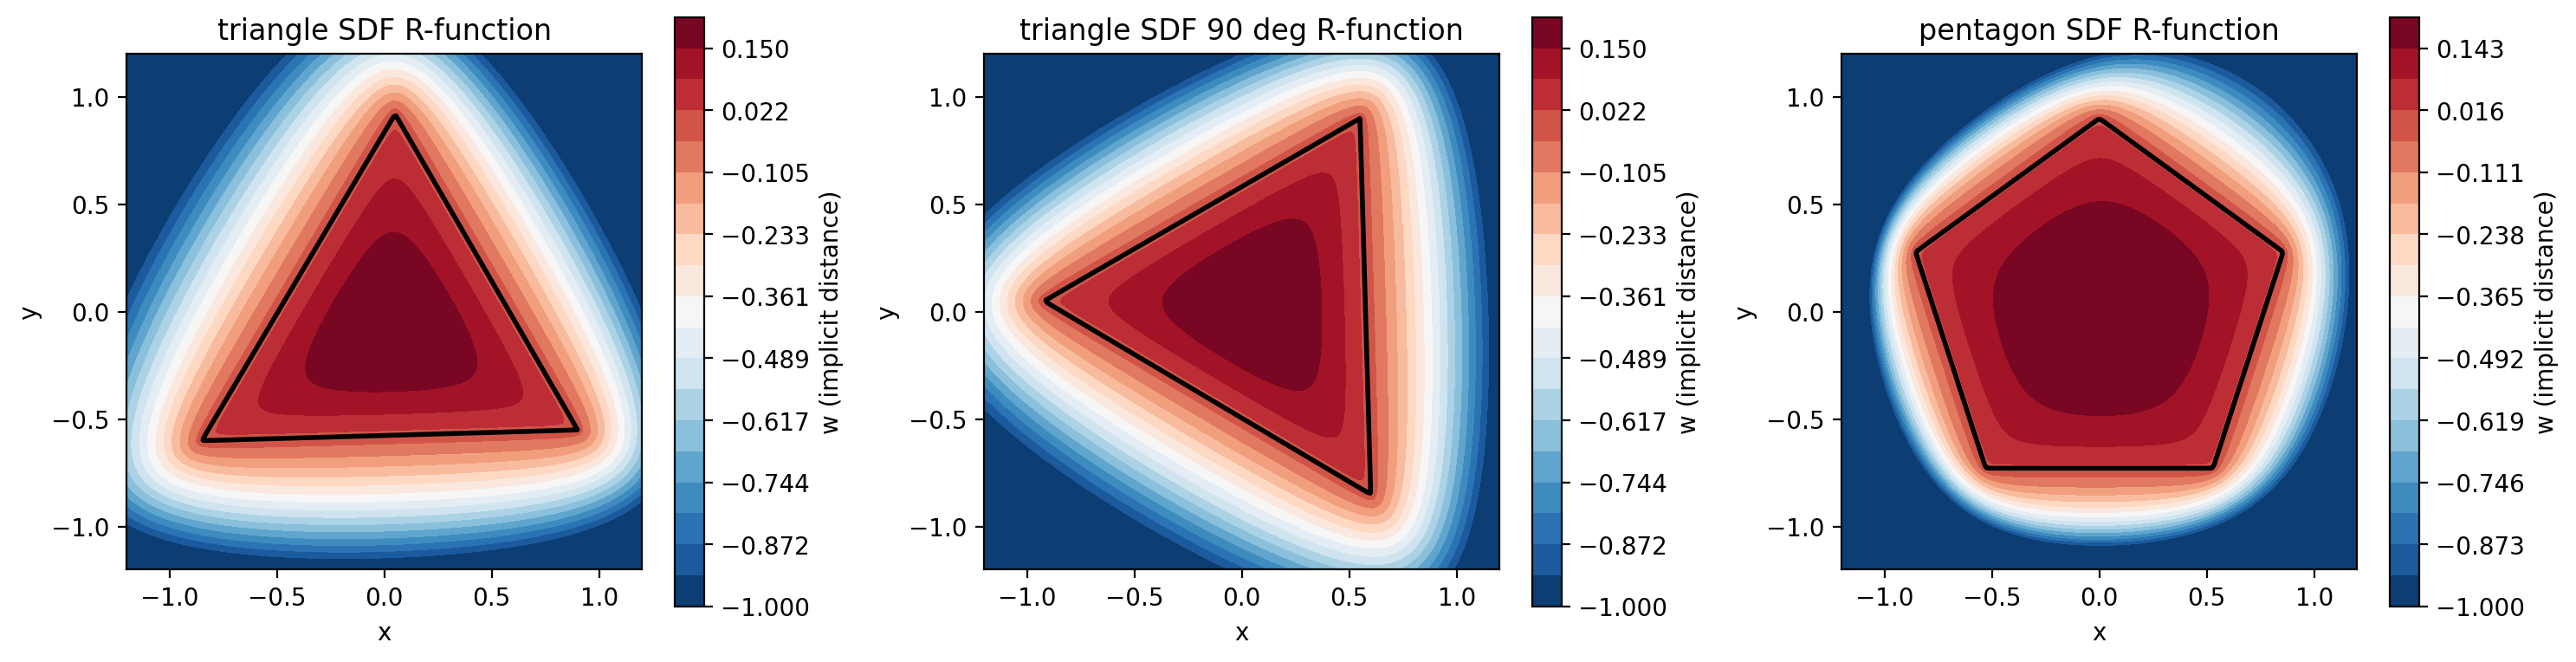

In [11]:
fig, axes = plt.subplots(1, len(GEOMS), figsize=(15, 4))

for idx, gv in enumerate(GEOMS):
    ax = axes[idx] if len(GEOMS) > 1 else axes
    
    # Create a fine grid for visualization
    x = np.linspace(-1.2, 1.2, 200)
    y = np.linspace(-1.2, 1.2, 200)
    xg, yg = np.meshgrid(x, y)
    
    # Evaluate the weight function (implicit distance)
    coords = torch.stack([torch.tensor(xg, dtype=torch.float32), 
                         torch.tensor(yg, dtype=torch.float32)], dim=-1)
    w = gv.model(coords)
    w = w.detach().numpy()
    # w is already computed above from coords
    # w is already a numpy array from the model output
    w = np.clip(w, -1.0, 1.0)  # Optional: clamp for better color scaling
    # Plot contours
    levels = np.linspace(np.min(w), np.max(w), 20)
    cf = ax.contourf(xg, yg, w, levels=levels, cmap="RdBu_r")
    ax.contour(xg, yg, w, levels=[0.0], colors="k", linewidths=2.0)
    
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(gv.name)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(cf, ax=ax, label="w (implicit distance)")

fig.tight_layout()
plt.show()

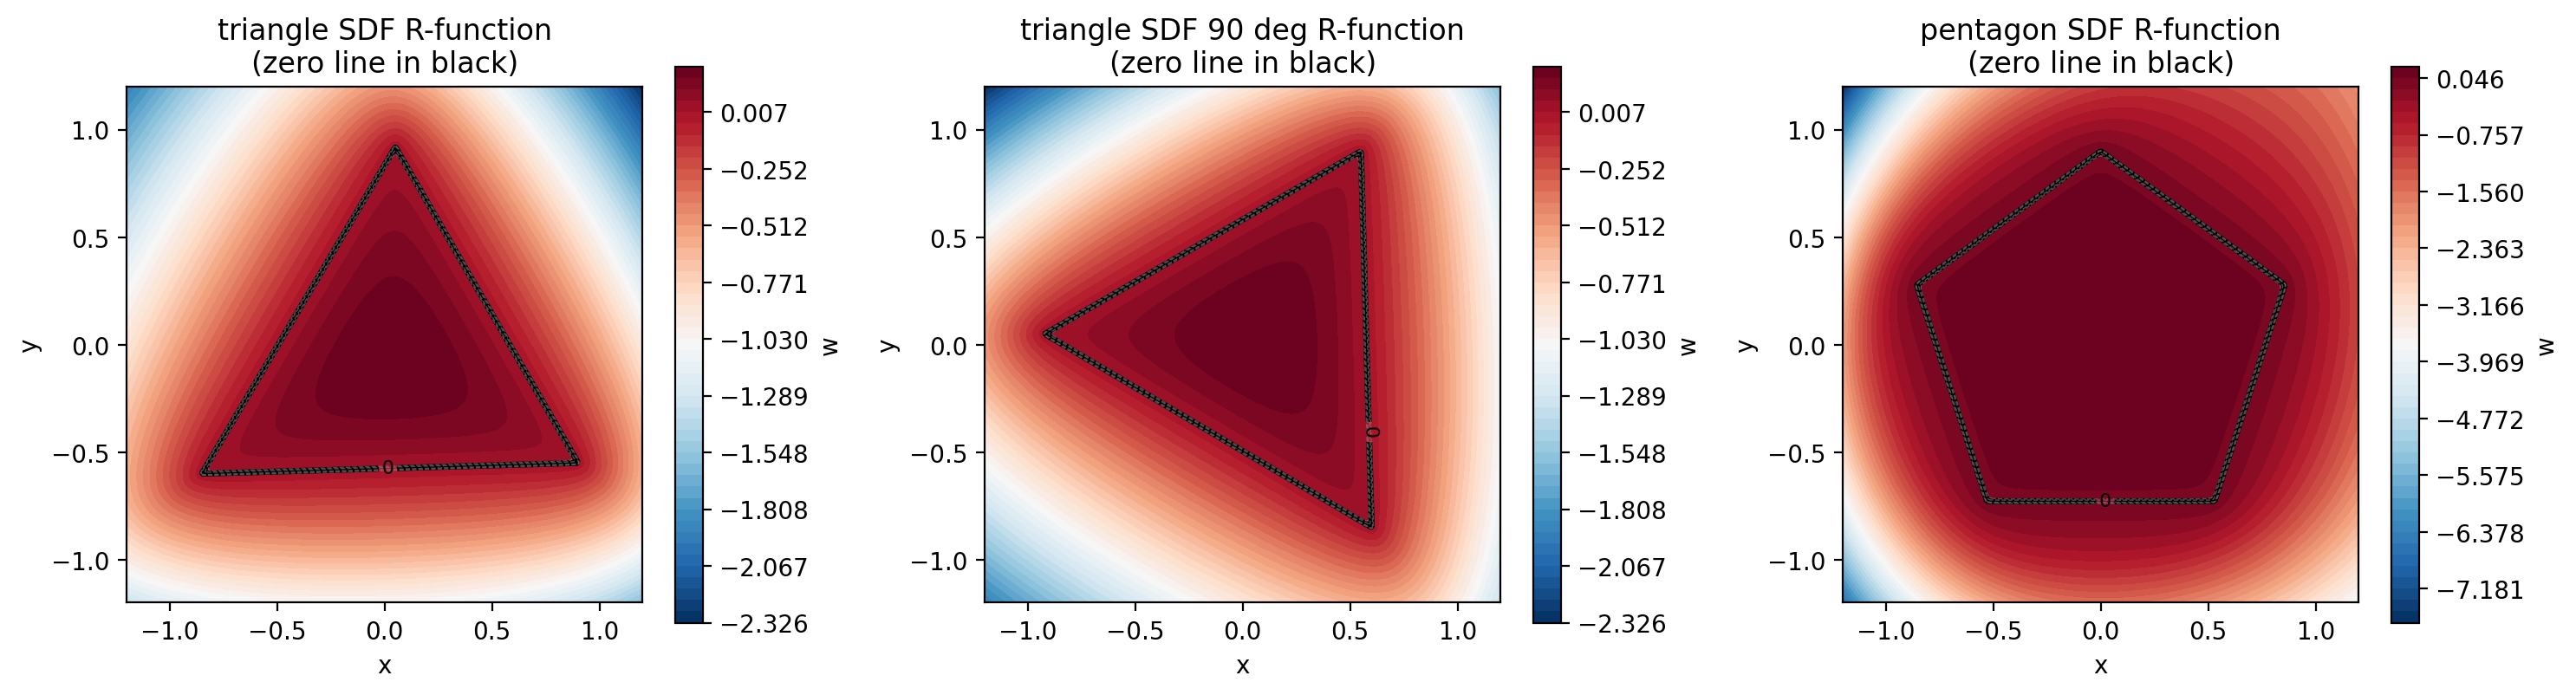

Analytical boundary verification:


triangle SDF R-function:
  Sample boundary points (should have w ≈ 0):
    w values: min=4.12e-04, max=3.09e-02, mean=1.50e-02
  Boundary point count (sign changes): 190

triangle SDF 90 deg R-function:
  Sample boundary points (should have w ≈ 0):
    w values: min=1.37e-04, max=3.61e-02, mean=1.37e-02
  Boundary point count (sign changes): 198

pentagon SDF R-function:
  Sample boundary points (should have w ≈ 0):
    w values: min=3.41e-03, max=3.10e-02, mean=1.32e-02
  Boundary point count (sign changes): 196


In [12]:
# Check the analytical correctness of the zero line (boundary) for each geometry

fig, axes = plt.subplots(1, len(GEOMS), figsize=(15, 4))

for idx, gv in enumerate(GEOMS):
    ax = axes[idx] if len(GEOMS) > 1 else axes
    
    # Create a very fine grid near the boundary
    x = np.linspace(-1.2, 1.2, 400)
    y = np.linspace(-1.2, 1.2, 400)
    xg, yg = np.meshgrid(x, y)
    
    # Evaluate the weight function
    coords = torch.stack([torch.tensor(xg, dtype=torch.float32), 
                         torch.tensor(yg, dtype=torch.float32)], dim=-1)
    w = gv.model(coords).detach().numpy()
    
    # Plot the weight function with focus on the zero level set
    levels = np.linspace(np.min(w), np.max(w), 50)
    cf = ax.contourf(xg, yg, w, levels=levels, cmap="RdBu_r")
    
    # Plot the zero level set (boundary) prominently
    cs = ax.contour(xg, yg, w, levels=[0.0], colors="black", linewidths=2.5)
    ax.clabel(cs, inline=True, fontsize=8)
    
    # Add contour lines very close to zero to check smoothness
    ax.contour(xg, yg, w, levels=[-0.01, -0.005, 0.005, 0.01], 
               colors="gray", linewidths=0.5, linestyles="--", alpha=0.6)
    
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"{gv.name}\n(zero line in black)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(cf, ax=ax, label="w")

fig.tight_layout()
plt.show()

# Quantitative check: sample points on the zero level set and verify they satisfy w=0
print("Analytical boundary verification:\n")
for gv in GEOMS:
    print(f"\n{gv.name}:")
    
    # Find approximate boundary points by sampling
    x_test = np.linspace(-1.2, 1.2, 100)
    y_test = np.linspace(-1.2, 1.2, 100)
    xg_test, yg_test = np.meshgrid(x_test, y_test)
    
    coords_test = torch.stack([torch.tensor(xg_test, dtype=torch.float32), 
                               torch.tensor(yg_test, dtype=torch.float32)], dim=-1)
    w_test = gv.model(coords_test).detach().numpy()
    
    # Find points where w changes sign (approximately on the boundary)
    boundary_mask = (w_test[:-1, :-1] * w_test[1:, 1:] < 0)
    boundary_points = np.where(boundary_mask)
    
    if len(boundary_points[0]) > 0:
        # Sample some boundary points
        sample_idx = np.random.choice(len(boundary_points[0]), min(20, len(boundary_points[0])), replace=False)
        sampled_x = xg_test[boundary_points[0][sample_idx], boundary_points[1][sample_idx]]
        sampled_y = yg_test[boundary_points[0][sample_idx], boundary_points[1][sample_idx]]
        
        # Evaluate w at these points
        coords_boundary = torch.stack([torch.tensor(sampled_x, dtype=torch.float32), 
                                       torch.tensor(sampled_y, dtype=torch.float32)], dim=-1)
        w_boundary = gv.model(coords_boundary).detach().numpy()
        
        print(f"  Sample boundary points (should have w ≈ 0):")
        print(f"    w values: min={np.min(np.abs(w_boundary)):.2e}, max={np.max(np.abs(w_boundary)):.2e}, mean={np.mean(np.abs(w_boundary)):.2e}")
        print(f"  Boundary point count (sign changes): {len(boundary_points[0])}")
    else:
        print(f"  No boundary sign changes detected in coarse search")

In [13]:
# --- Diagnostic: check near-boundary points for the pentagon case ---
# Compare raw collocation-grid data (used by binning) vs upsampled data (used by heatmap)

DIAG_GEOM = "pentagon SDF R-function"
DIAG_N = DEGREES[0]
DIAG_H = HS[0]

res = all_results[(DIAG_GEOM, DIAG_N, DIAG_H)]
xP, yP = res["xP"], res["yP"]
Uxy     = res["Uxy"]
err     = res["err"]
wP      = res["wP"]
inside  = res["inside"]

# Recompute SDF at collocation grid (same as run_one does)
with torch.no_grad():
    _crd = torch.tensor(np.stack([xP, yP], axis=-1), dtype=torch.float64)
    _gv = [gv for gv in GEOMS if gv.name == DIAG_GEOM][0]
    _verts = _crd.new_tensor(_gv.model._vertices_np)
    sdf_all = geom.convex_polygon_sdf(_crd, _verts).numpy()

sdf_inside = sdf_all[inside]
err_inside = err[inside]

# 1) Check for dropped points (non-finite)
n_nonfinite_sdf = np.sum(~np.isfinite(sdf_inside))
n_nonfinite_err = np.sum(~np.isfinite(err_inside))
print(f"Inside points: {inside.sum()}")
print(f"Non-finite SDF inside: {n_nonfinite_sdf}")
print(f"Non-finite err inside: {n_nonfinite_err}")

# 2) Sort by SDF — show the 30 points closest to the boundary
order = np.argsort(sdf_inside)
print(f"\n--- 30 closest-to-boundary COLLOCATION grid points ({DIAG_GEOM}, n={DIAG_N}, H={DIAG_H}) ---")
print(f"{'idx':>5}  {'SDF':>12}  {'|err|':>12}  {'w':>12}  {'x':>9}  {'y':>9}")
flat_x = xP[inside]
flat_y = yP[inside]
flat_w = wP[inside]
for rank in range(min(30, len(order))):
    j = order[rank]
    print(f"{rank:5d}  {sdf_inside[j]:12.6e}  {err_inside[j]:12.6e}  {flat_w[j]:12.6e}  {flat_x[j]:9.4f}  {flat_y[j]:9.4f}")

# 3) Print the actual bins DataFrame
print(f"\n--- Bins DataFrame ---")
bins_df = res["bins"]
print(bins_df.to_string())

# 4) Now check the HEATMAP path: upsample and look at near-boundary errors
xPu, yPu, Uh_u = _upsample_tensor_grid(xP, yP, Uxy, factor=int(PLOT_UPSAMPLE))
wfct_phys = res["wfct_phys"]
u_exact_phys = res["u_exact_phys"]
w_u, *_ = wfct_phys(xPu, yPu)
Uex_u = u_exact_phys(xPu, yPu)
err_u = np.abs(Uh_u - Uex_u)
inside_u = w_u > 0

with torch.no_grad():
    _crd_u = torch.tensor(np.stack([xPu, yPu], axis=-1), dtype=torch.float64)
    sdf_u = geom.convex_polygon_sdf(_crd_u, _verts).numpy()

sdf_u_inside = sdf_u[inside_u]
err_u_inside = err_u[inside_u]
x_u_inside = xPu[inside_u]
y_u_inside = yPu[inside_u]

order_u = np.argsort(sdf_u_inside)
print(f"\n--- 30 closest-to-boundary UPSAMPLED grid points ---")
print(f"{'idx':>5}  {'SDF':>12}  {'|err|':>12}  {'x':>9}  {'y':>9}")
for rank in range(min(30, len(order_u))):
    j = order_u[rank]
    print(f"{rank:5d}  {sdf_u_inside[j]:12.6e}  {err_u_inside[j]:12.6e}  {x_u_inside[j]:9.4f}  {y_u_inside[j]:9.4f}")

# 5) Compare summary stats
print(f"\n--- Summary ---")
print(f"Collocation grid: max err near boundary (SDF < 0.05) = ", end="")
near_mask = sdf_inside < 0.05
print(f"{err_inside[near_mask].max():.4e}" if near_mask.any() else "no points")
print(f"Collocation grid: max err overall = {err_inside.max():.4e}")
print(f"Upsampled grid:   max err near boundary (SDF < 0.05) = ", end="")
near_mask_u = sdf_u_inside < 0.05
print(f"{err_u_inside[near_mask_u].max():.4e}" if near_mask_u.any() else "no points")
print(f"Upsampled grid:   max err overall = {err_u_inside.max():.4e}")

Inside points: 496
Non-finite SDF inside: 0
Non-finite err inside: 0

--- 30 closest-to-boundary COLLOCATION grid points (pentagon SDF R-function, n=2, H=32) ---
  idx           SDF         |err|             w          x          y
    0  7.605559e-04  3.278128e-06  7.292569e-04     0.5312    -0.7188
    1  7.605559e-04  3.260390e-06  7.290308e-04    -0.5312    -0.7188
    2  4.229322e-03  8.873258e-08  4.168295e-03     0.1562     0.7812
    3  4.229322e-03  5.715598e-07  4.157564e-03    -0.1562     0.7812
    4  4.635459e-03  1.485012e-05  3.797994e-03     0.8438     0.2812
    5  4.635459e-03  6.200251e-06  3.789248e-03    -0.8438     0.2812
    6  8.973696e-03  1.143937e-06  8.805562e-03     0.4062     0.5938
    7  8.973696e-03  8.574264e-07  8.756572e-03    -0.4062     0.5938
    8  9.365295e-03  2.253203e-05  8.557514e-03    -0.4688    -0.7188
    9  9.365295e-03  1.133212e-05  8.906871e-03    -0.4062    -0.7188
   10  9.365295e-03  5.886171e-06  9.022452e-03    -0.3438    -0.718

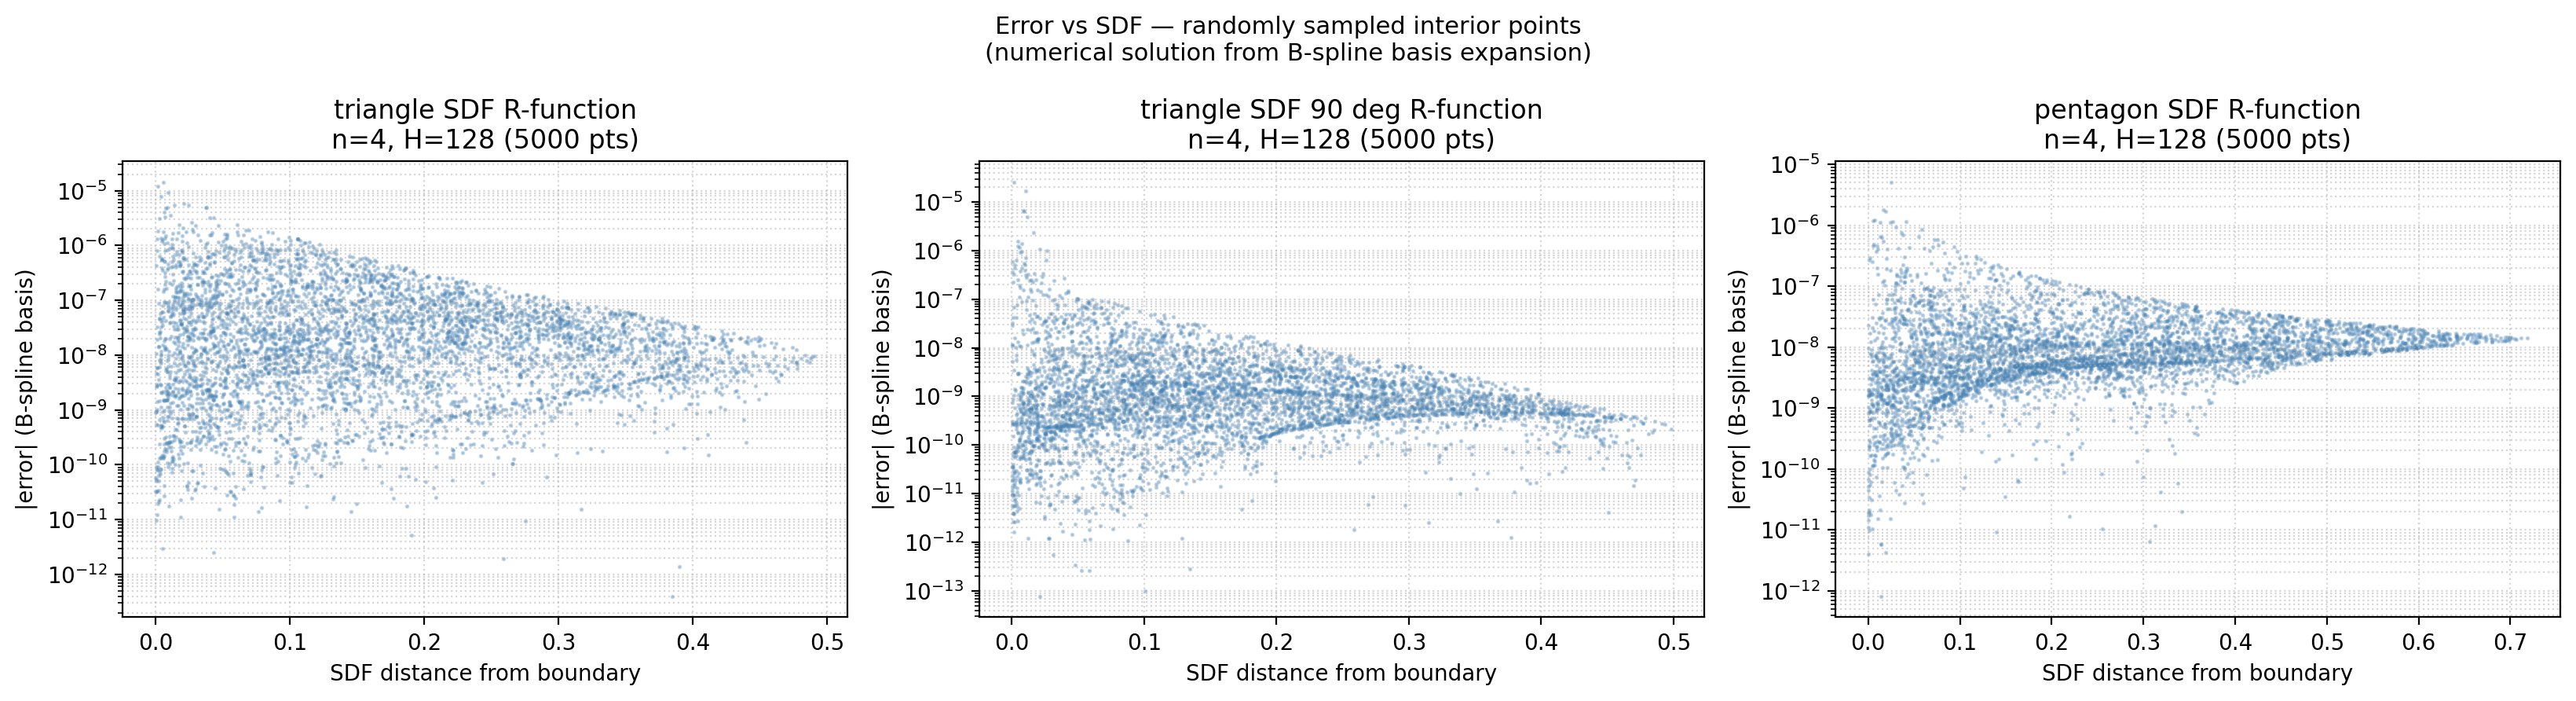

In [14]:
# --- Scatter plot: error vs SDF with randomly sampled interior points ---
# Evaluate the numerical solution at random interior points using the
# B-spline basis expansion (not grid interpolation).

N_RANDOM = 5000  # number of interior random points per geometry
RNG = np.random.default_rng(42)

n_show_r = DEGREES[-1]
H_show_r = HS[-1]

fig, axes = plt.subplots(1, len(GEOMS), figsize=(5.5 * len(GEOMS), 4.5), squeeze=False)
axes = axes[0]

for idx, gv in enumerate(GEOMS):
    ax = axes[idx]
    res = all_results[(gv.name, n_show_r, H_show_r)]
    recon_info = res["recon_info"]
    wfct_phys = res["wfct_phys"]
    u_exact_phys = res["u_exact_phys"]

    # Determine bounding box of the polygon
    verts_np = gv.model._vertices_np
    xmin, xmax = float(verts_np[:, 0].min()), float(verts_np[:, 0].max())
    ymin, ymax = float(verts_np[:, 1].min()), float(verts_np[:, 1].max())

    # Rejection sampling: generate random points inside the polygon
    pts_x, pts_y = [], []
    while len(pts_x) < N_RANDOM:
        batch = max(N_RANDOM * 3, 10000)
        rx = RNG.uniform(xmin, xmax, size=batch)
        ry = RNG.uniform(ymin, ymax, size=batch)
        crd = torch.tensor(np.stack([rx, ry], axis=-1), dtype=torch.float64)
        verts_t = crd.new_tensor(verts_np)
        inside_mask = geom._point_in_convex_polygon_ccw(crd, verts_t).numpy()
        pts_x.append(rx[inside_mask])
        pts_y.append(ry[inside_mask])
    pts_x = np.concatenate(pts_x)[:N_RANDOM]
    pts_y = np.concatenate(pts_y)[:N_RANDOM]

    # Evaluate numerical solution via B-spline basis expansion
    u_h = colloc.reconstruct_collocation_at_points(pts_x, pts_y, recon_info, wfct_phys)
    u_ex = u_exact_phys(pts_x, pts_y)
    err_rand = np.abs(u_h - u_ex)

    # Compute true SDF at these random points
    with torch.no_grad():
        crd_rand = torch.tensor(np.stack([pts_x, pts_y], axis=-1), dtype=torch.float64)
        verts_t = crd_rand.new_tensor(verts_np)
        sdf_rand = geom.convex_polygon_sdf(crd_rand, verts_t).numpy()

    # Filter out any NaN from evaluation (points outside grid)
    valid = np.isfinite(err_rand) & np.isfinite(sdf_rand) & (sdf_rand > 0)
    sdf_v = sdf_rand[valid]
    err_v = err_rand[valid]

    ax.scatter(sdf_v, err_v, s=1, alpha=0.3, c="steelblue", rasterized=True)
    ax.set_yscale("log")
    ax.set_xlabel("SDF distance from boundary")
    ax.set_ylabel("|error| (B-spline basis)")
    ax.set_title(f"{gv.name}\nn={n_show_r}, H={H_show_r} ({len(sdf_v)} pts)")
    ax.grid(True, which="both", ls=":", alpha=0.5)

fig.suptitle(
    "Error vs SDF \u2014 randomly sampled interior points\n"
    "(numerical solution from B-spline basis expansion)",
    fontsize=11,
)
fig.tight_layout()
plt.show()


triangle SDF R-function | u=expw | n=2 H=32
  u_x    max=3.817e-02  mean=3.676e-04
  u_y    max=5.842e-02  mean=6.574e-04
  u_xx   max=1.127e+01  mean=2.333e-02
  u_yy   max=1.095e+01  mean=6.934e-02


C:\Users\csapo\AppData\Local\Temp\ipykernel_2612\2989132661.py:441: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cf.collections:


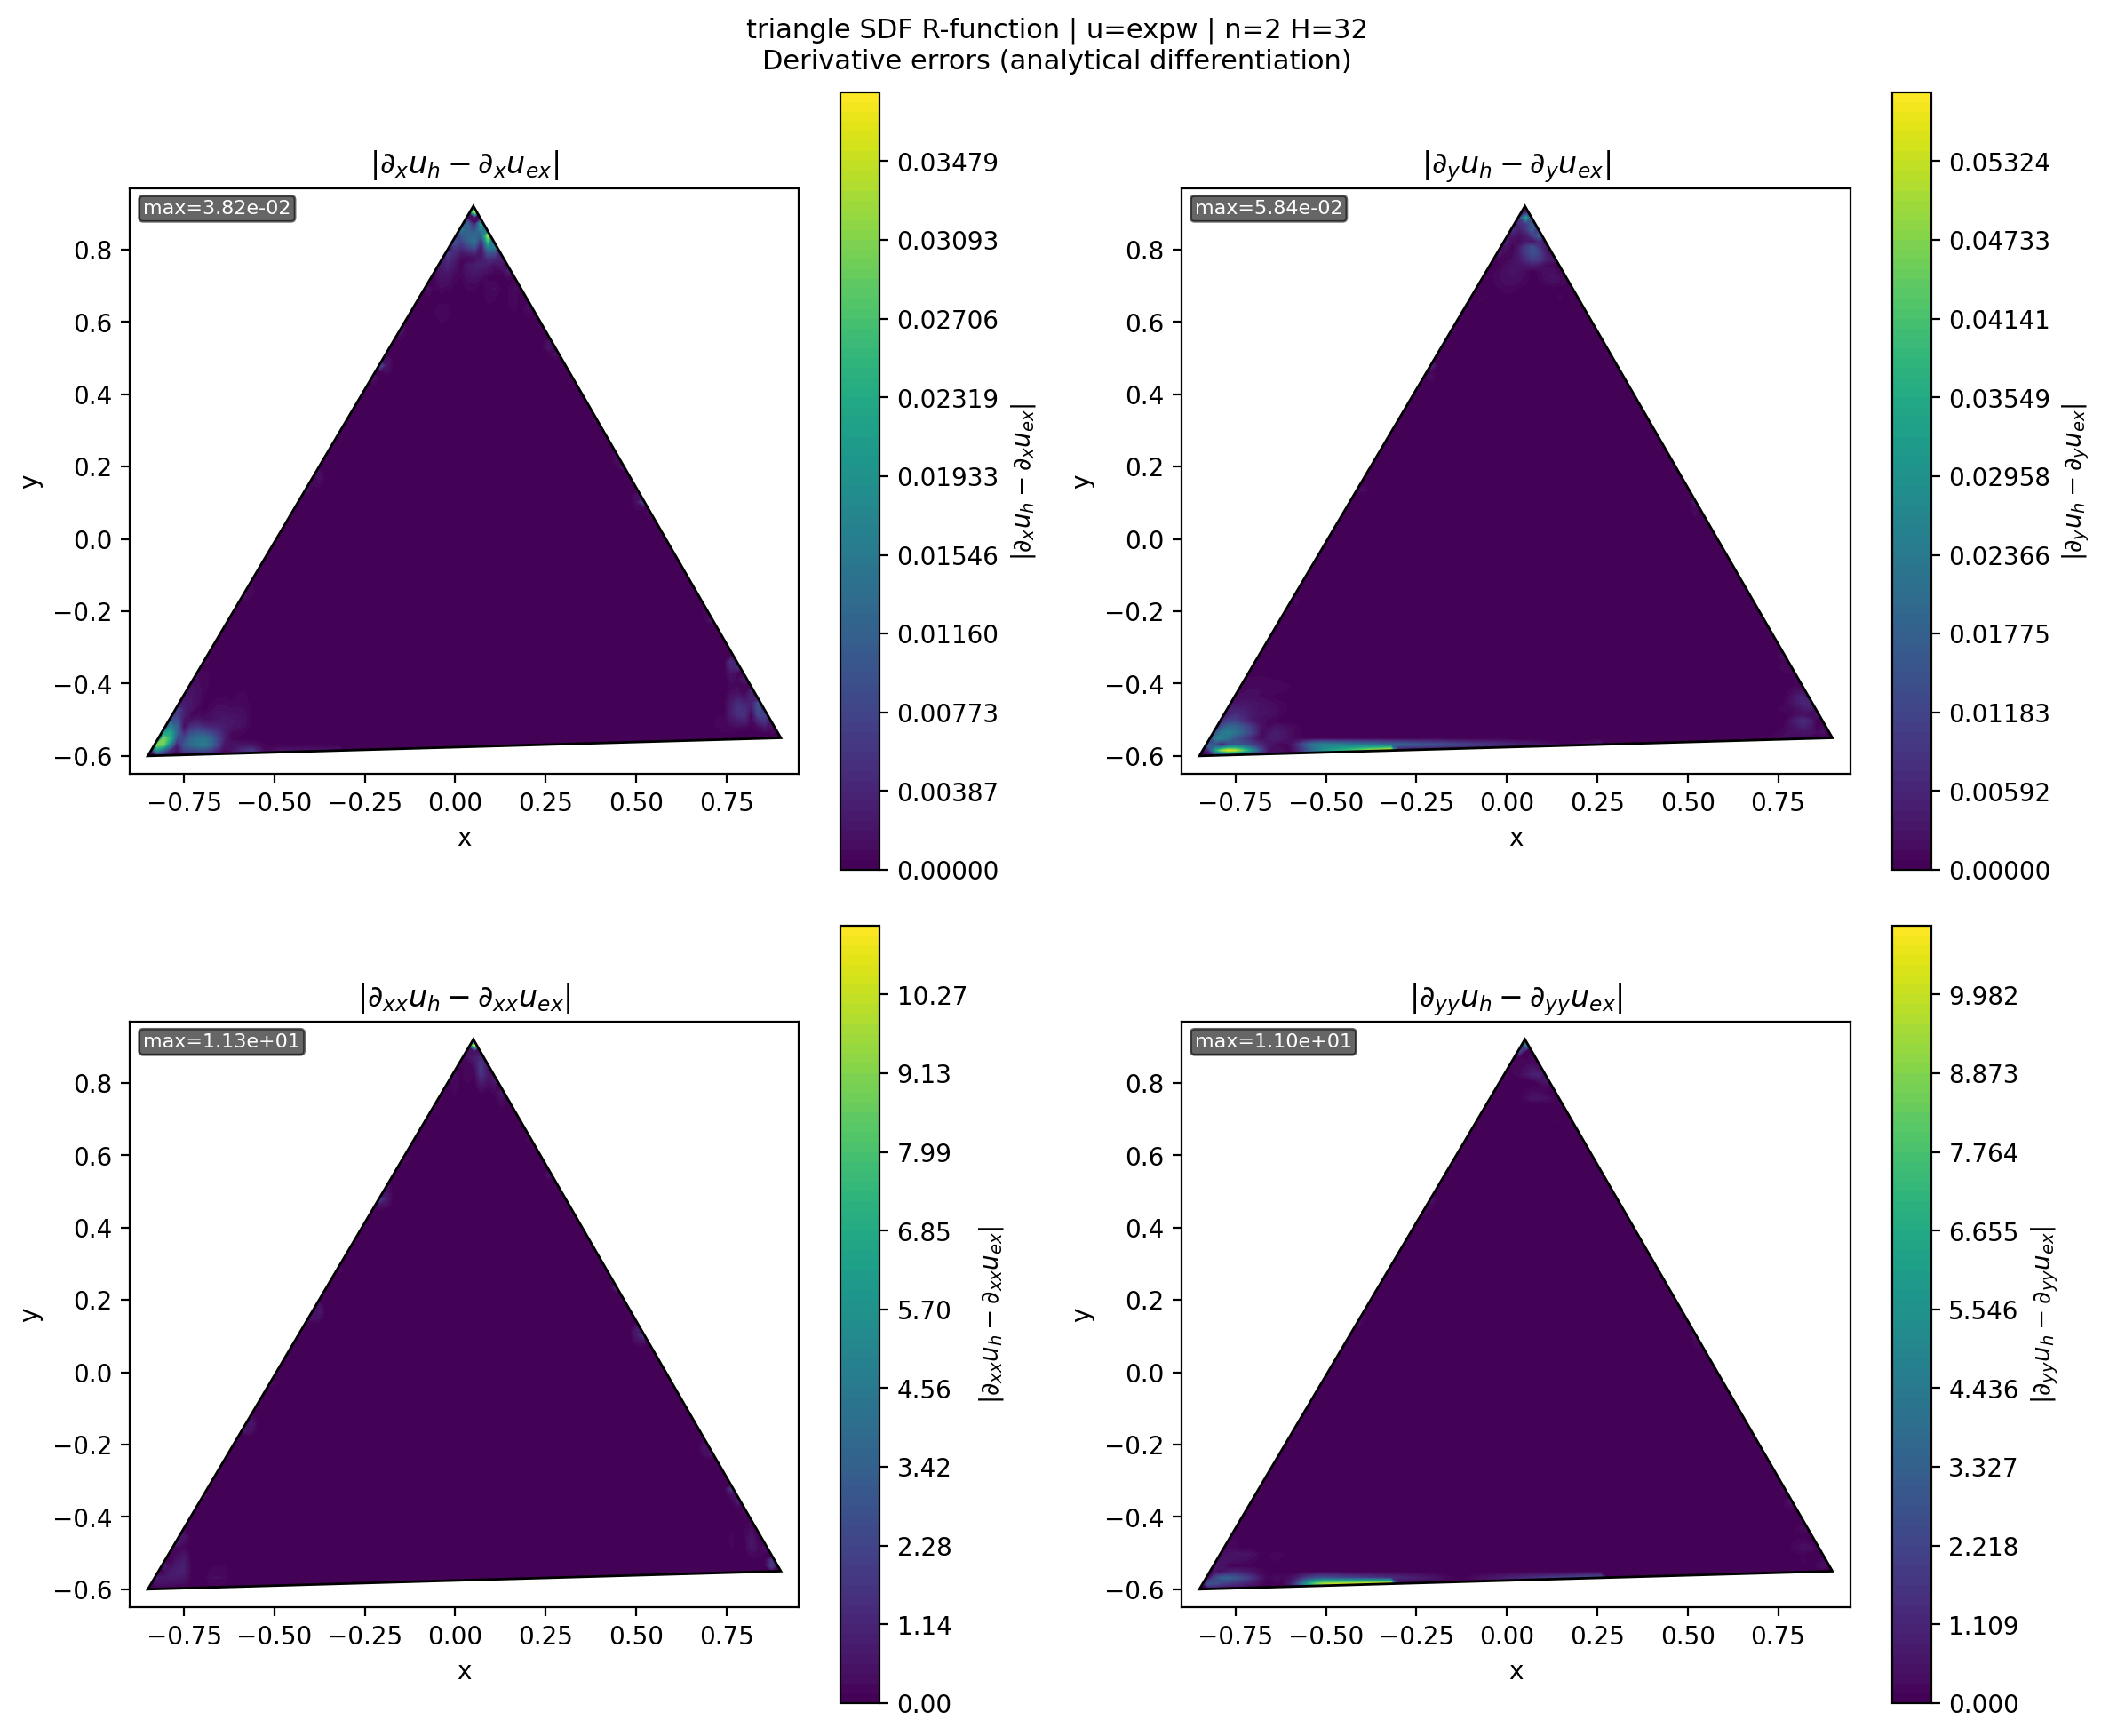

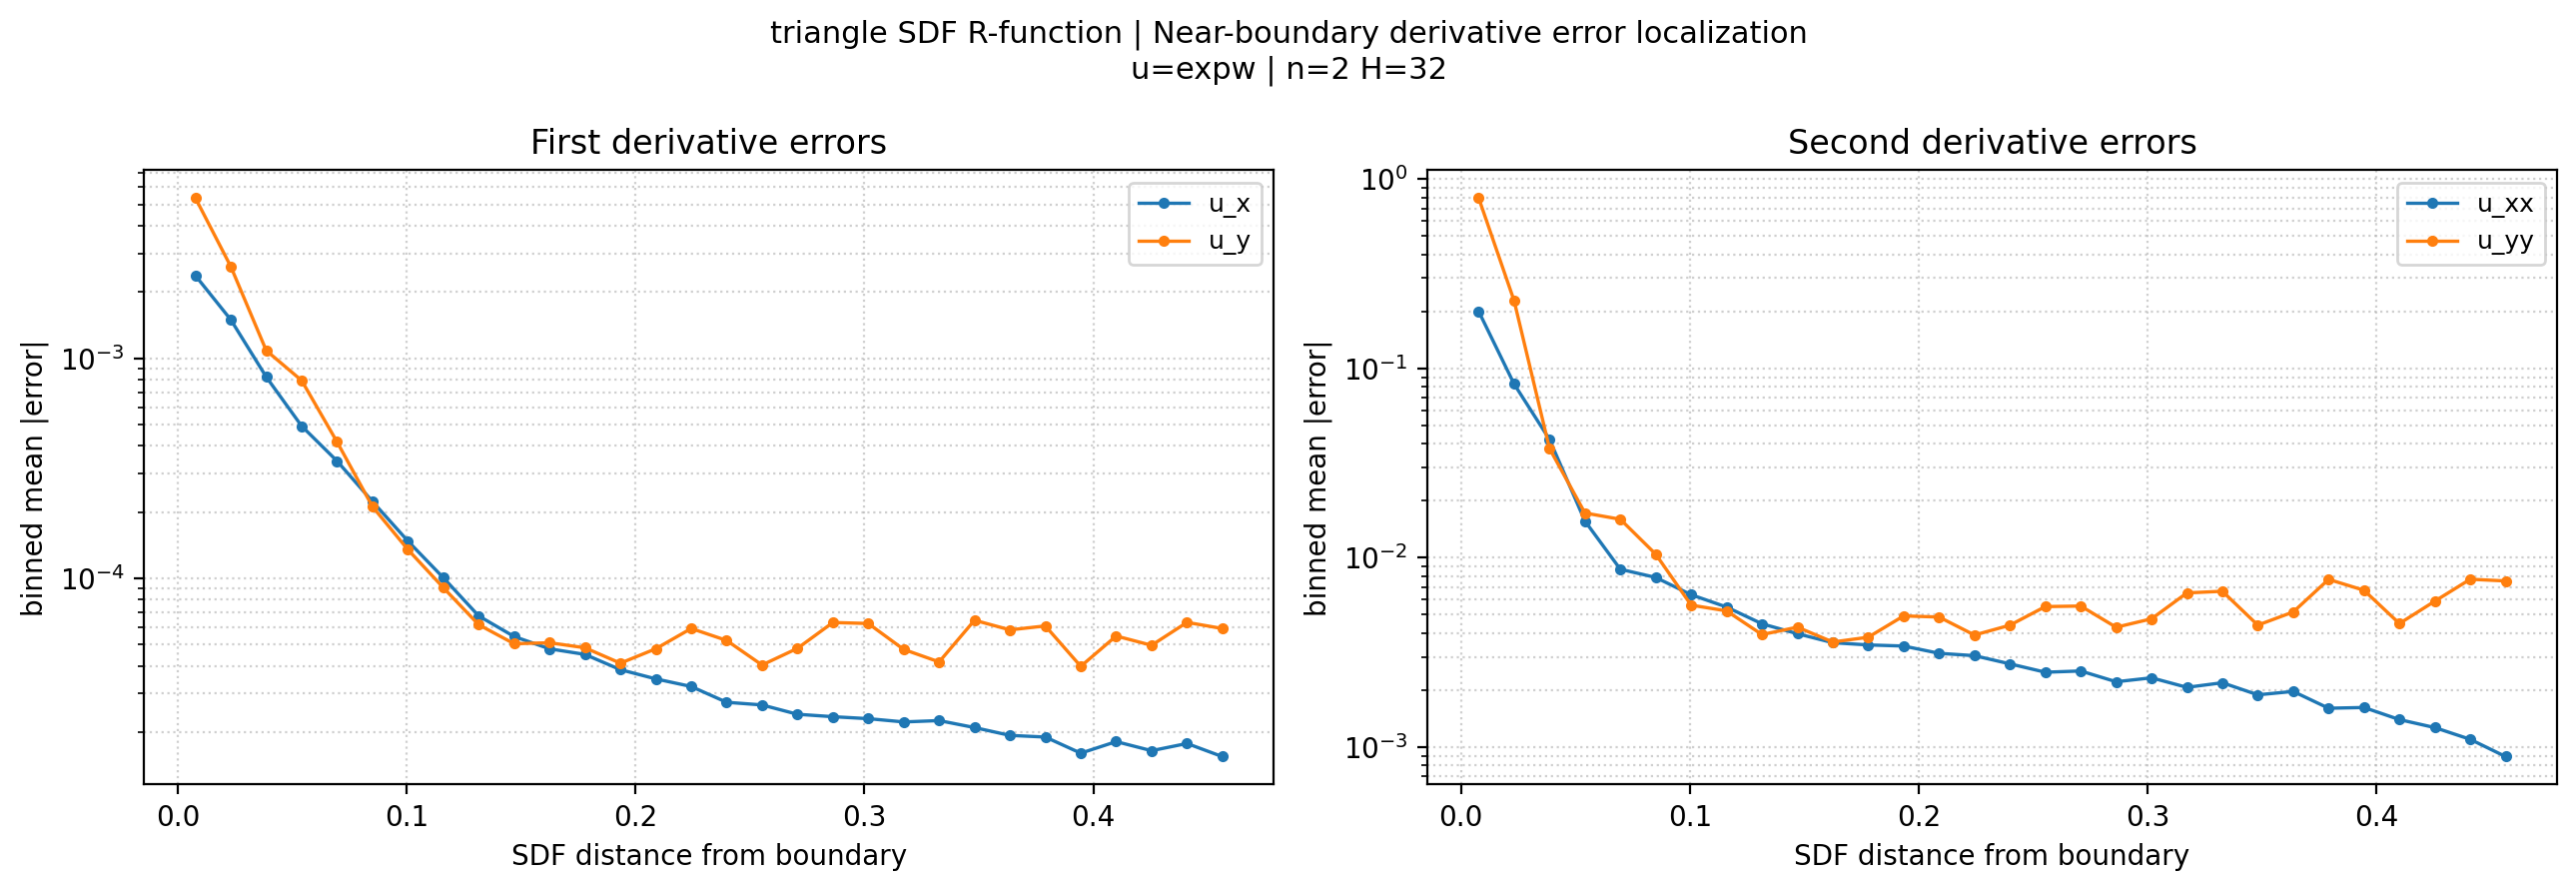


triangle SDF 90 deg R-function | u=expw | n=2 H=32
  u_x    max=5.842e-02  mean=6.572e-04
  u_y    max=3.817e-02  mean=3.673e-04
  u_xx   max=1.095e+01  mean=6.929e-02
  u_yy   max=1.127e+01  mean=2.328e-02


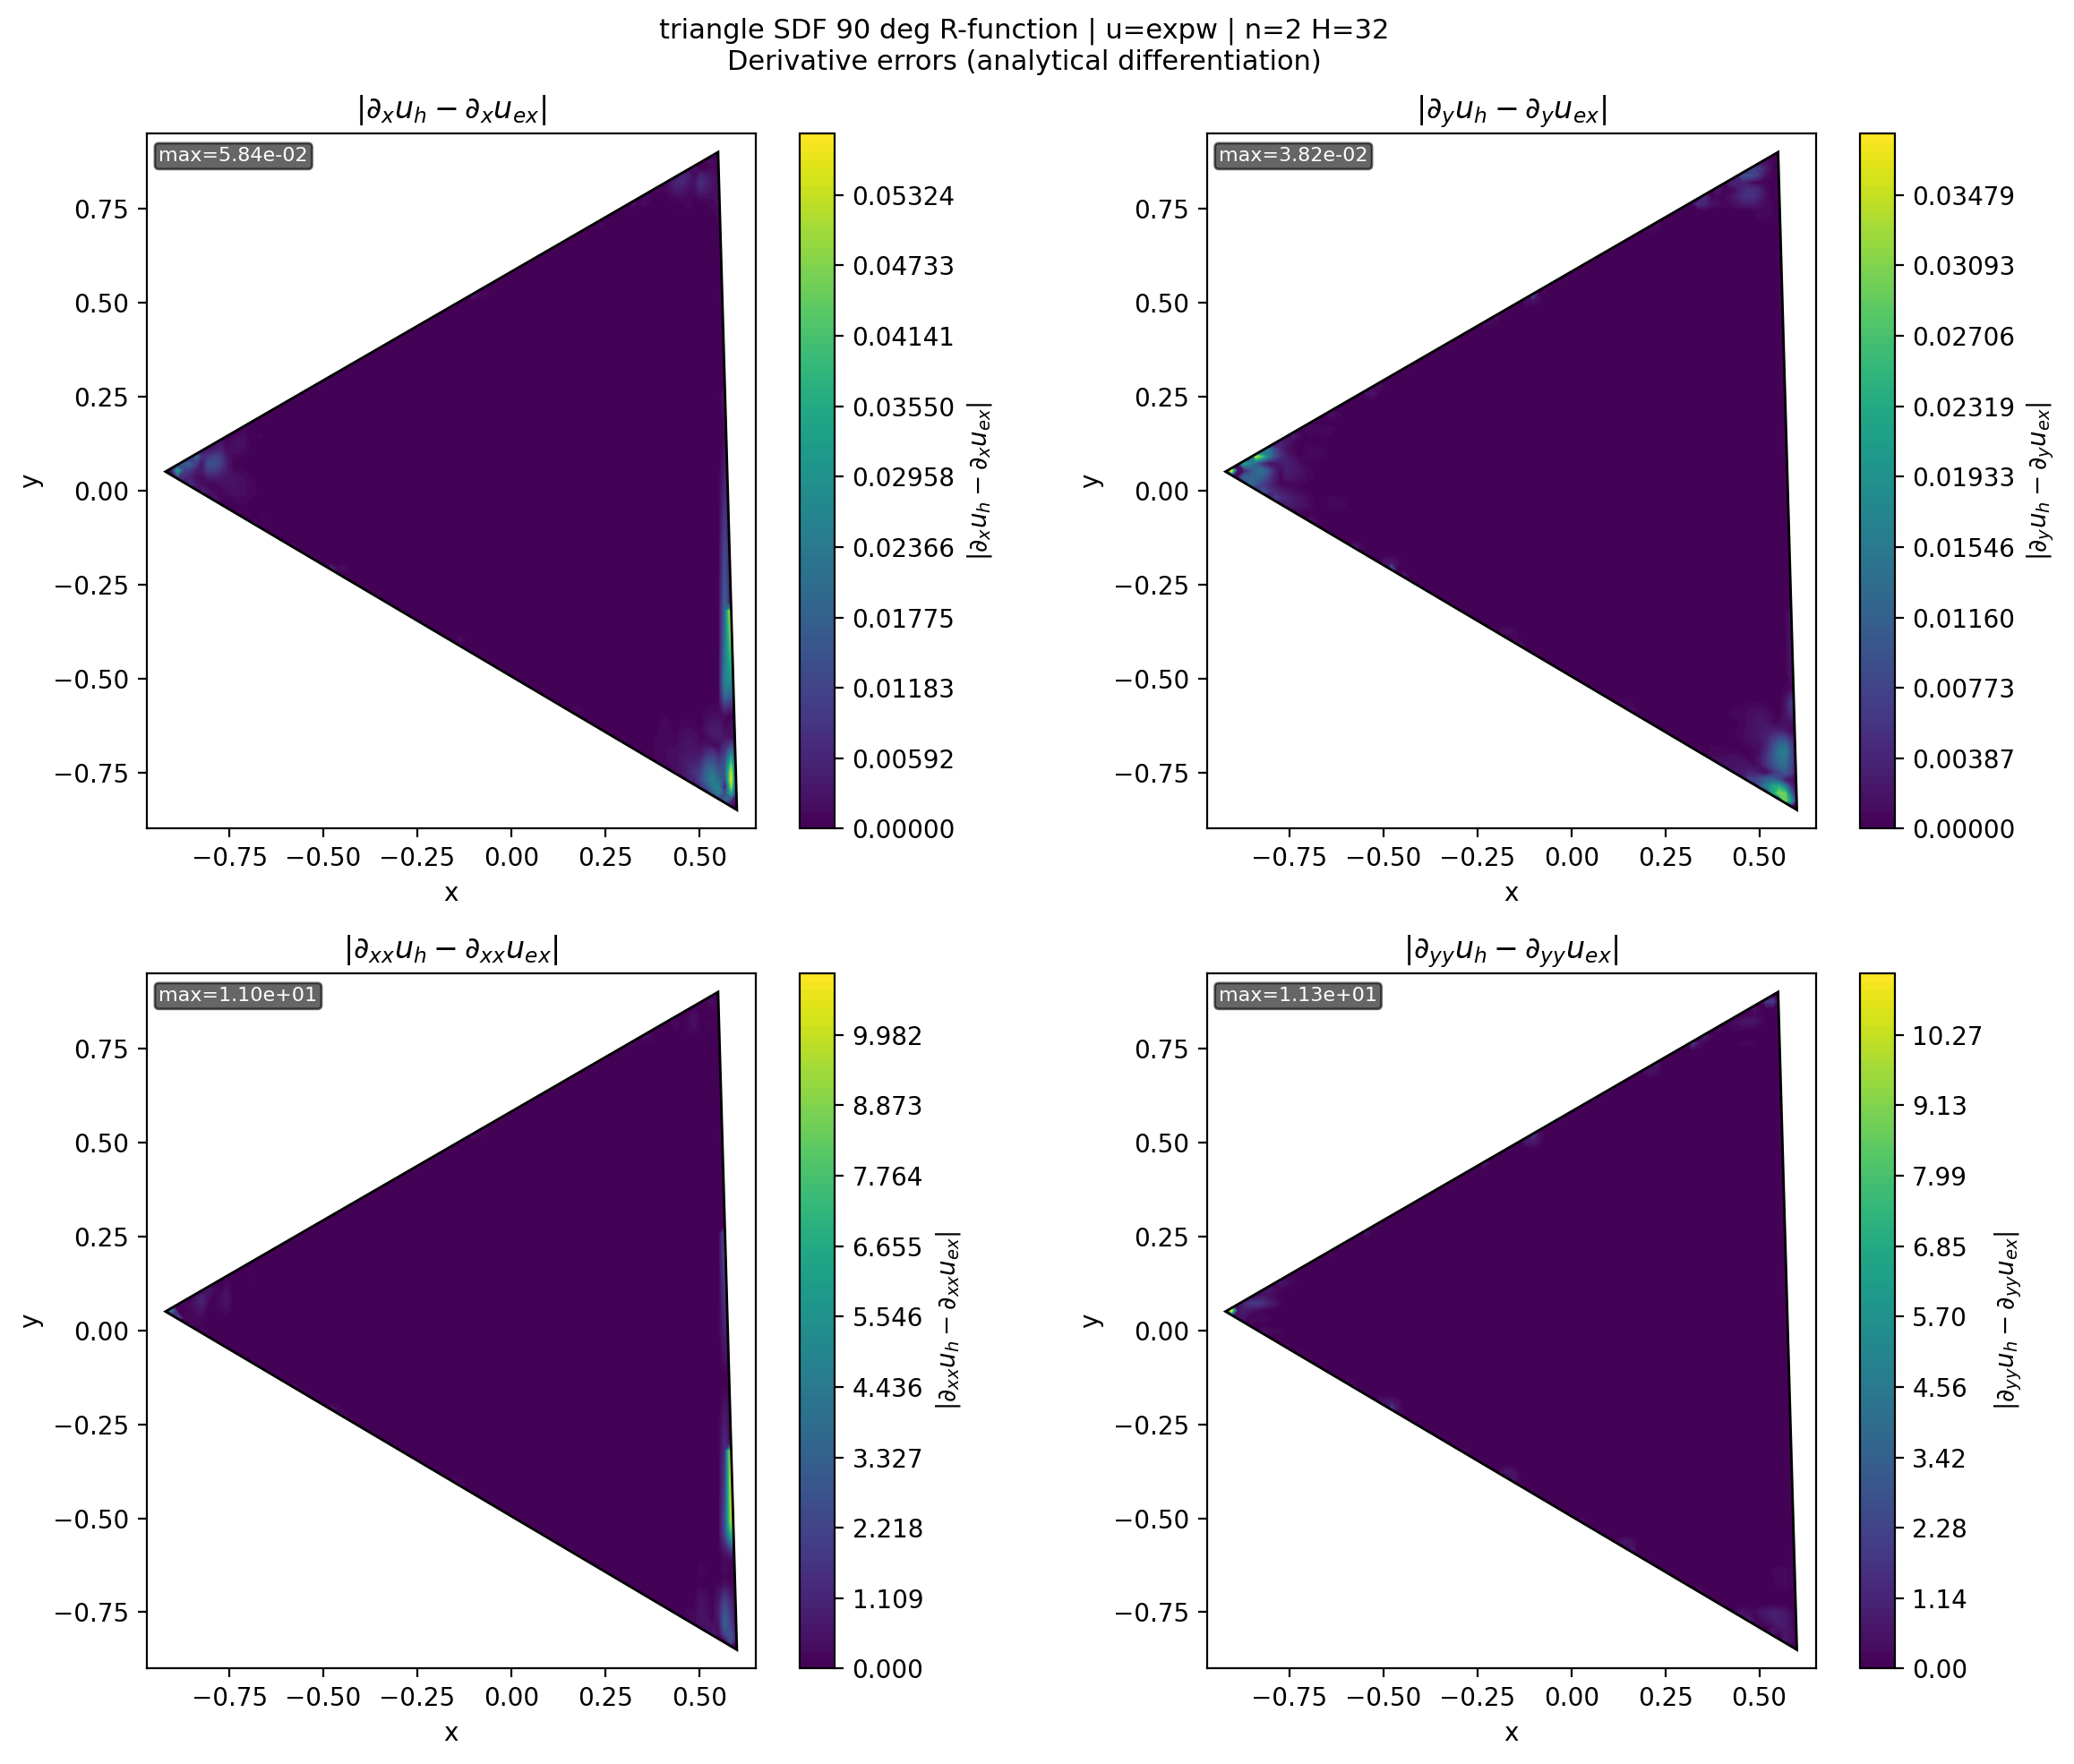

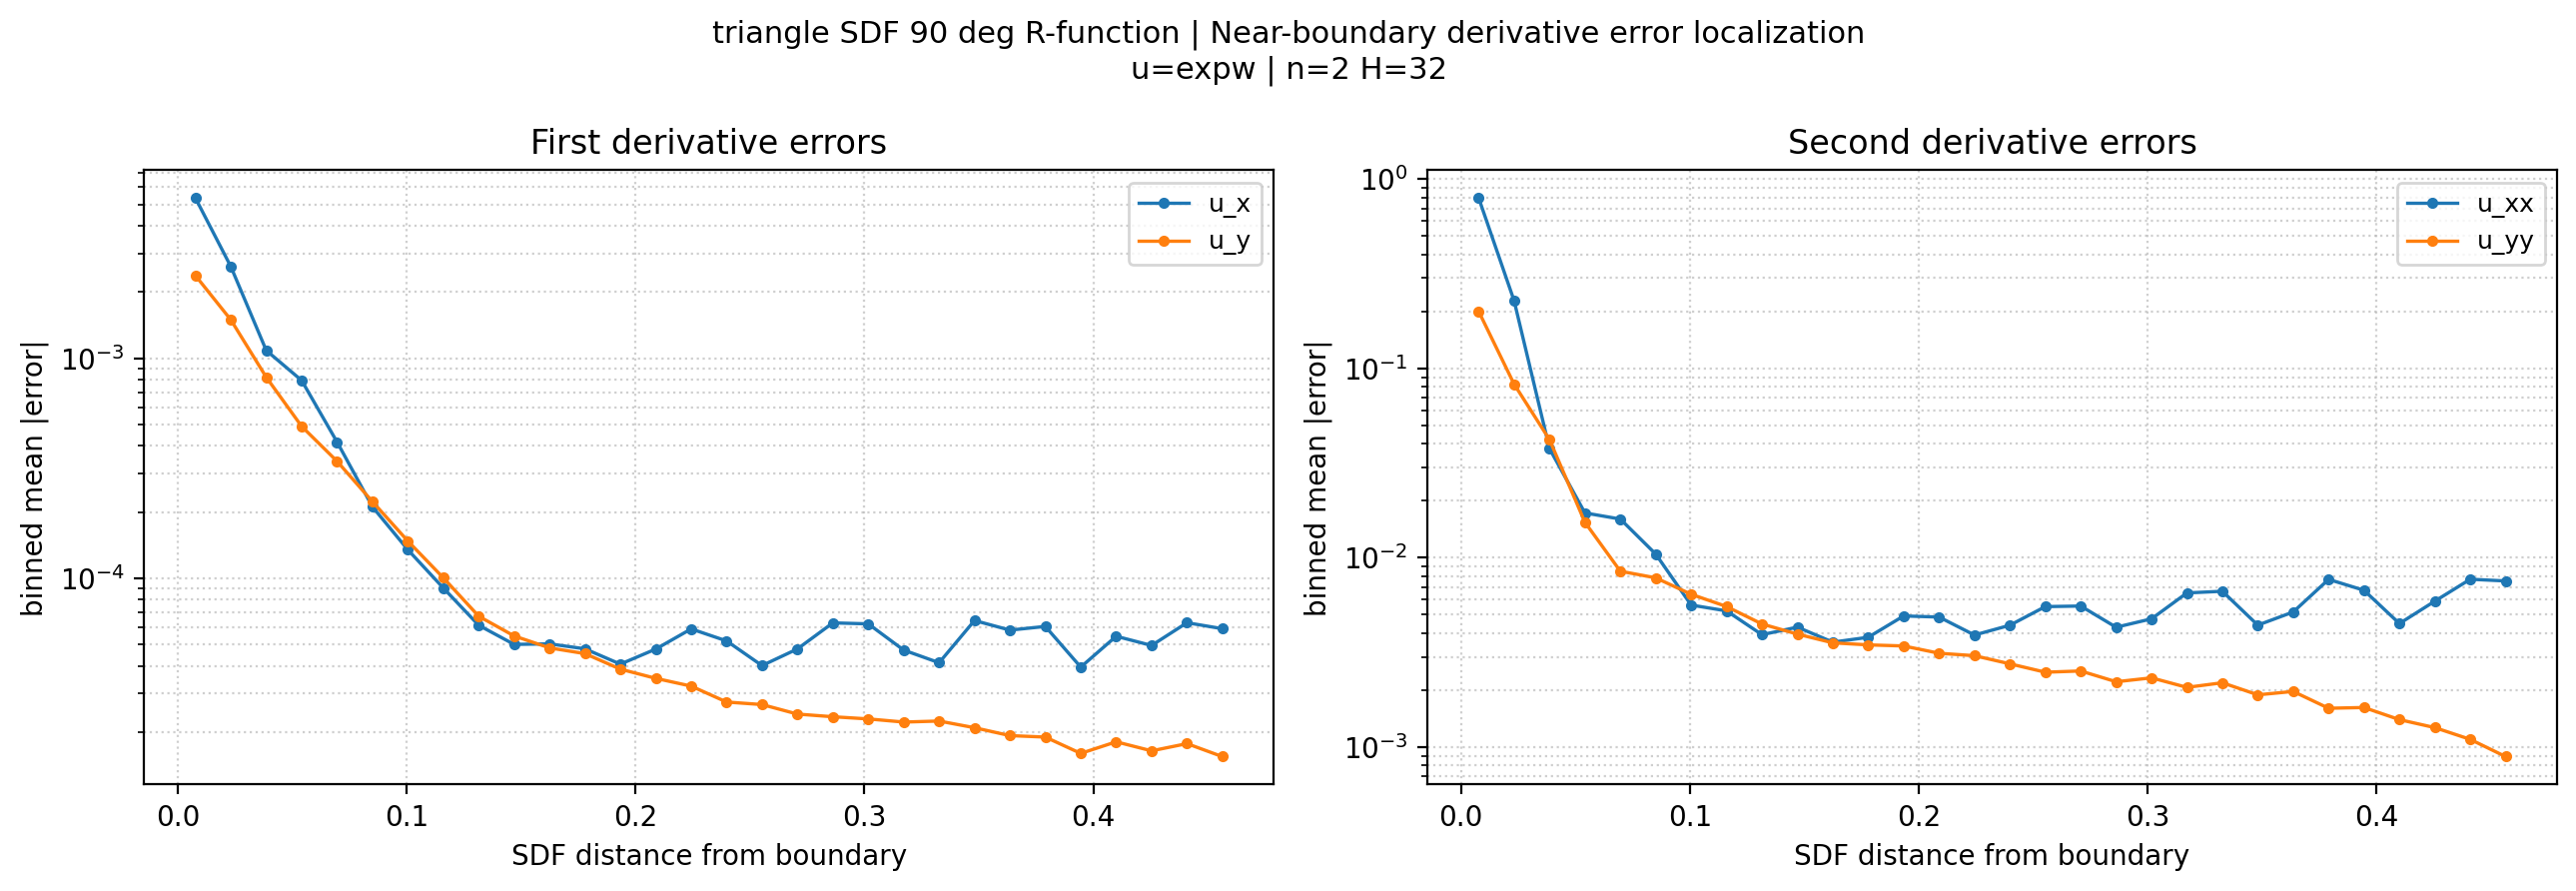


pentagon SDF R-function | u=expw | n=2 H=32
  u_x    max=1.271e-02  mean=1.257e-04
  u_y    max=8.308e-03  mean=1.456e-04
  u_xx   max=3.551e+00  mean=1.404e-02
  u_yy   max=1.074e+00  mean=8.395e-03


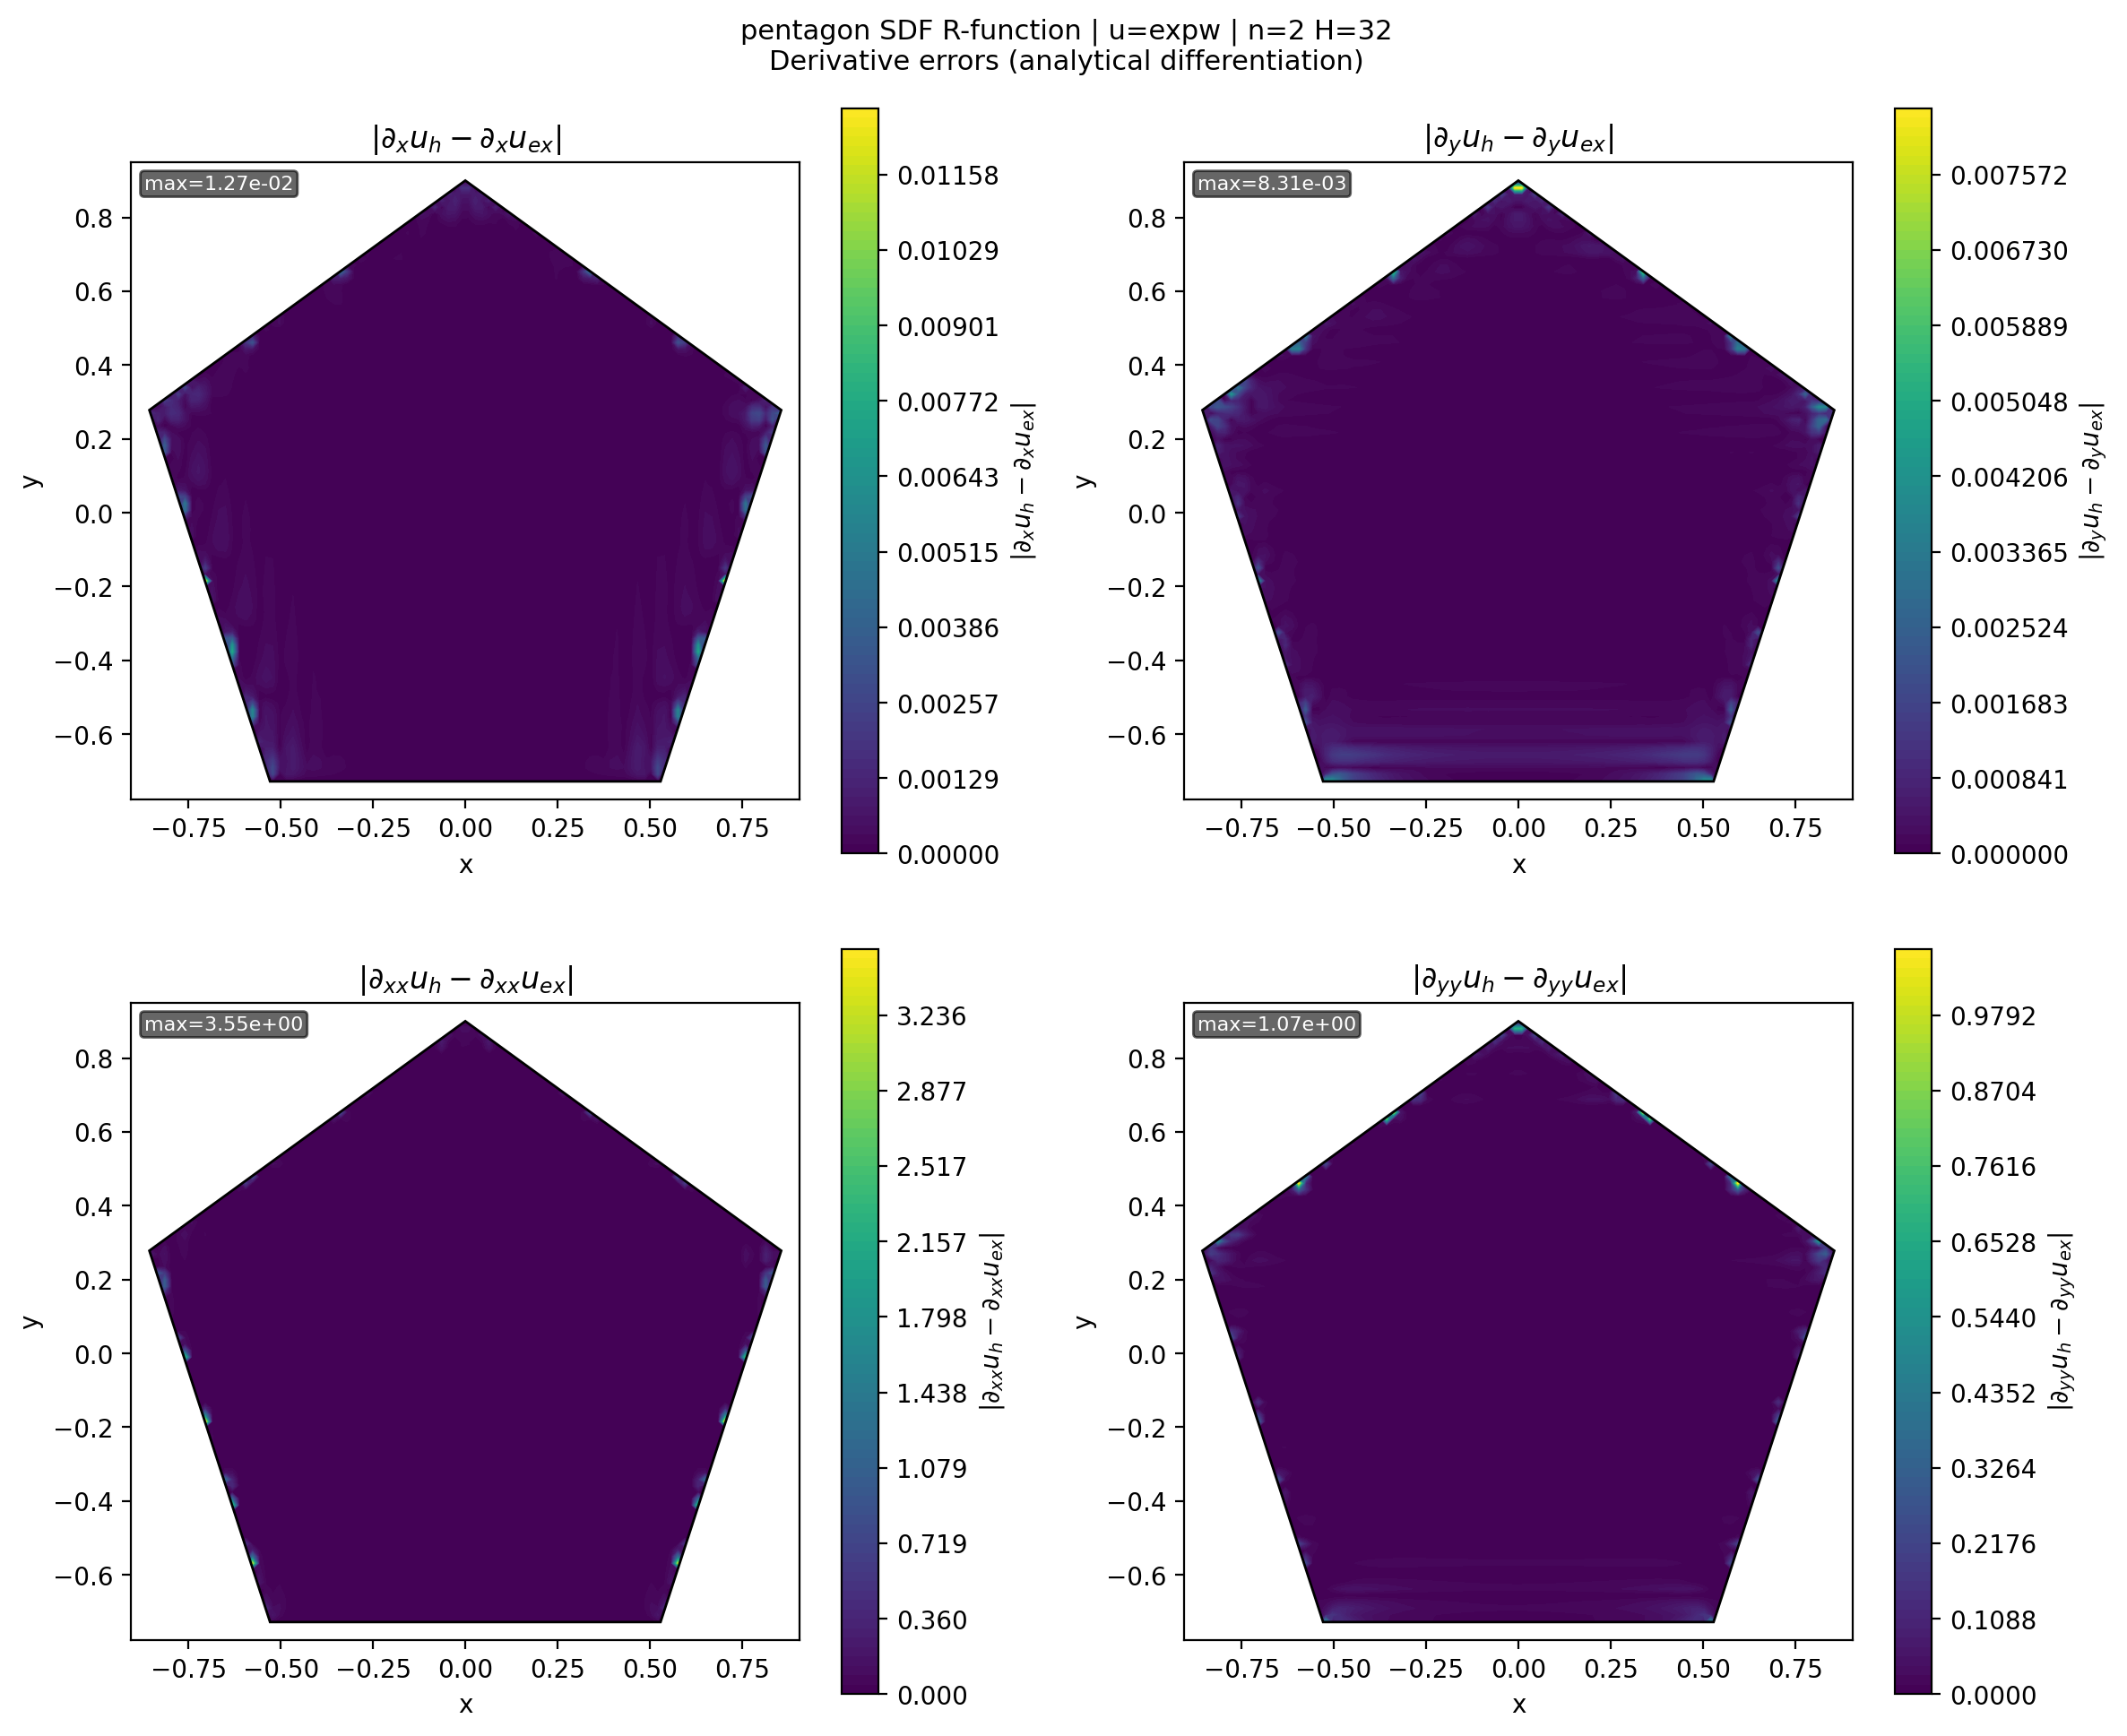

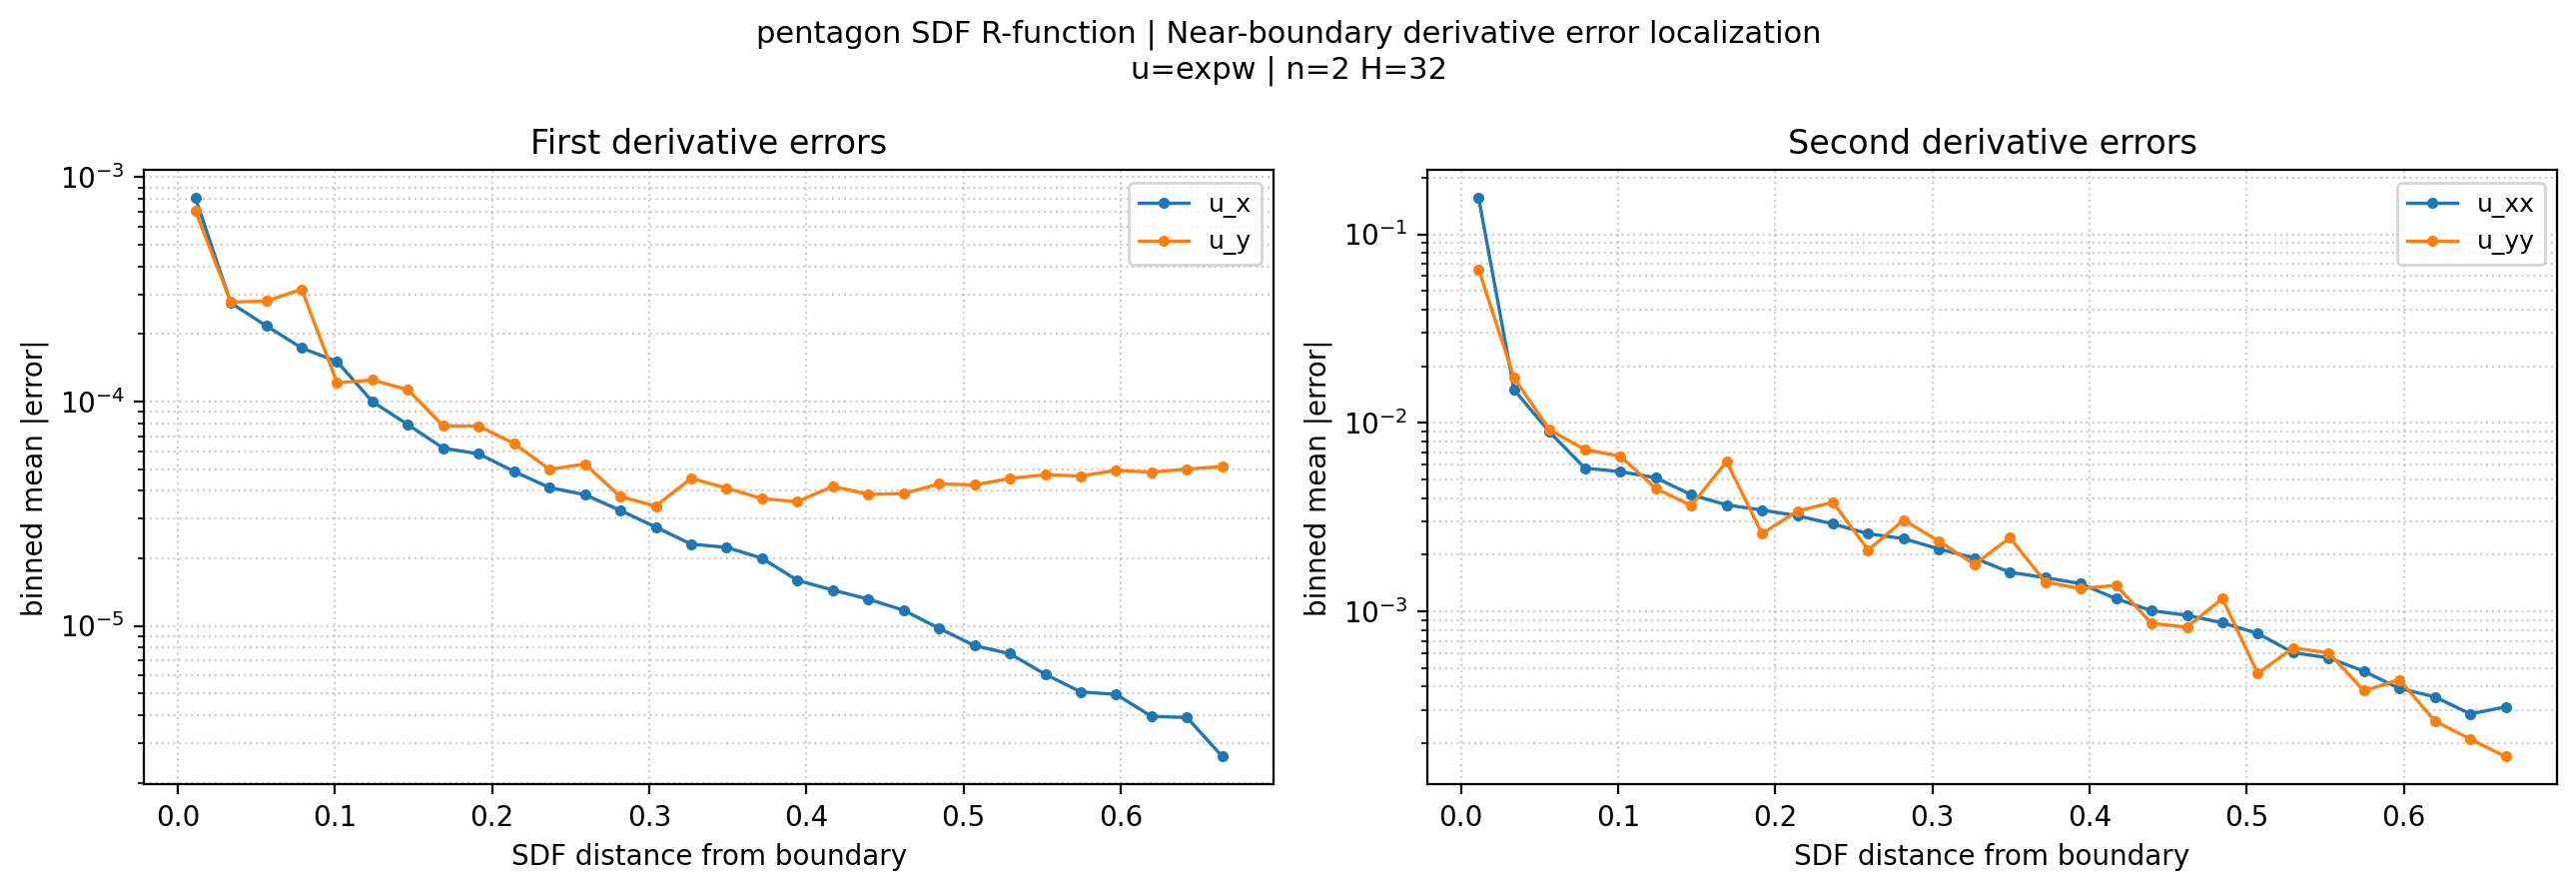

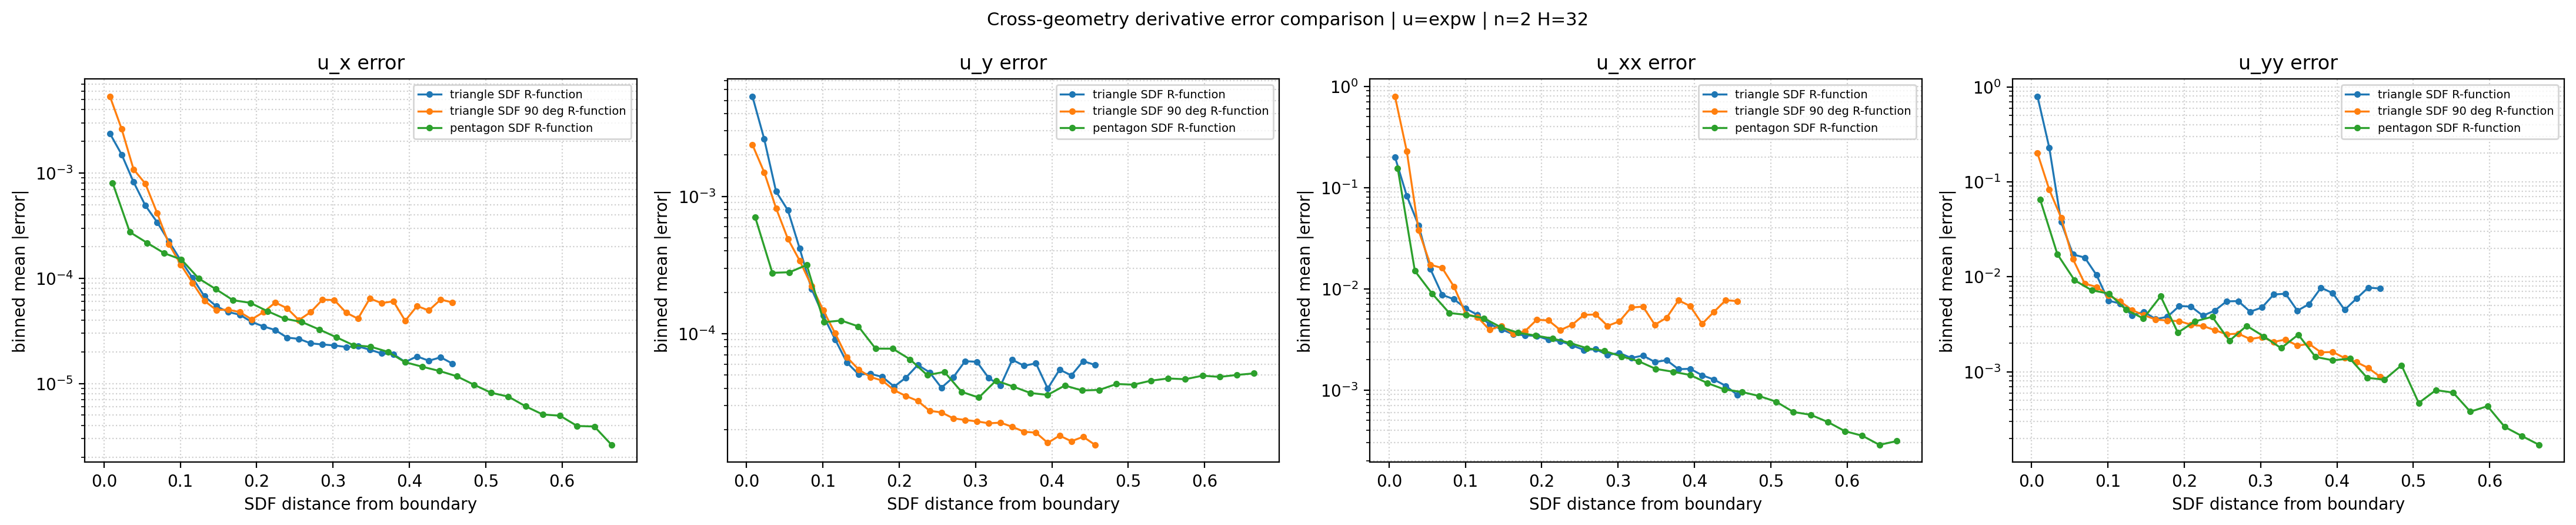

In [15]:
# ==========================================================================
# DERIVATIVE ERROR ANALYSIS
# ==========================================================================
# Compute and plot errors of first and second derivatives of the solution
# using analytical differentiation (NO numeric finite differences).
#
# Exact solution derivatives (u = exp(w) - 1):
#   u_x   = exp(w) * w_x
#   u_y   = exp(w) * w_y
#   u_xx  = exp(w) * (w_x^2 + w_xx)
#   u_yy  = exp(w) * (w_y^2 + w_yy)
#
# WEB spline numerical solution: u_h = max(w,0) * v(x,y)
#   Derivatives via product rule on the B-spline basis expansion,
#   computed analytically by reconstruct_collocation_hessian_diag.

def compute_exact_derivatives(wfct_phys, pts_x, pts_y, u_type="expw"):
    """Analytical first and second partial derivatives of the manufactured solution."""
    w, wx, wy, wxx, wyy = wfct_phys(pts_x, pts_y)
    w, wx, wy, wxx, wyy = [np.asarray(a).ravel() for a in (w, wx, wy, wxx, wyy)]
    if u_type == "expw":
        ew = np.exp(w)
        return ew * wx, ew * wy, ew * (wx**2 + wxx), ew * (wy**2 + wyy)
    elif u_type == "w2":
        return (2 * w * wx, 2 * w * wy,
                2 * (wx**2 + w * wxx), 2 * (wy**2 + w * wyy))
    raise ValueError(f"Unknown u_type={u_type}")


n_d = DEGREES[0]
H_d = HS[0]
GRID_RES = 100

# Storage for cross-geometry comparison
all_deriv_bins = {}

for gv in GEOMS:
    res = all_results[(gv.name, n_d, H_d)]
    recon_info = res["recon_info"]
    wfct_phys = res["wfct_phys"]
    verts_np = res["model"]._vertices_np

    # Fine evaluation grid covering the polygon
    xmin_v = float(verts_np[:, 0].min()) - 0.05
    xmax_v = float(verts_np[:, 0].max()) + 0.05
    ymin_v = float(verts_np[:, 1].min()) - 0.05
    ymax_v = float(verts_np[:, 1].max()) + 0.05
    gx = np.linspace(xmin_v, xmax_v, GRID_RES)
    gy = np.linspace(ymin_v, ymax_v, GRID_RES)
    GX, GY = np.meshgrid(gx, gy)
    flat_x, flat_y = GX.ravel(), GY.ravel()

    # Numerical derivatives from WEB spline (analytical via B-spline calculus + product rule)
    u_h, ux_h, uy_h, uxx_h, uyy_h = colloc.reconstruct_collocation_hessian_diag(
        flat_x, flat_y, recon_info, wfct_phys)

    # Exact derivatives (analytical from manufactured solution)
    ux_ex, uy_ex, uxx_ex, uyy_ex = compute_exact_derivatives(
        wfct_phys, flat_x, flat_y, U_EXACT_TYPE)

    # Inside-domain mask
    w_vals, *_ = wfct_phys(flat_x, flat_y)
    w_vals = np.asarray(w_vals).ravel()
    inside = w_vals > 0
    valid_grid = inside.reshape(GX.shape)

    # Derivative errors
    deriv_data = [
        (r"$|\partial_x u_h - \partial_x u_{ex}|$", "u_x", np.abs(ux_h - ux_ex)),
        (r"$|\partial_y u_h - \partial_y u_{ex}|$", "u_y", np.abs(uy_h - uy_ex)),
        (r"$|\partial_{xx} u_h - \partial_{xx} u_{ex}|$", "u_xx", np.abs(uxx_h - uxx_ex)),
        (r"$|\partial_{yy} u_h - \partial_{yy} u_{ex}|$", "u_yy", np.abs(uyy_h - uyy_ex)),
    ]

    # SDF for near-boundary binning
    with torch.no_grad():
        crd = torch.tensor(np.stack([flat_x, flat_y], axis=-1), dtype=torch.float64)
        verts_t = crd.new_tensor(verts_np)
        sdf_flat = geom.convex_polygon_sdf(crd, verts_t).numpy().ravel()
    sdf_inside = sdf_flat[inside]

    # --- Print summary ---
    print(f"\n{'='*70}")
    print(f"{gv.name} | u={U_EXACT_TYPE} | n={n_d} H={H_d}")
    print(f"{'='*70}")
    for latex_label, short_label, err_flat in deriv_data:
        ei = err_flat[inside]
        print(f"  {short_label:5s}  max={np.max(ei):.3e}  mean={np.mean(ei):.3e}")

    # --- Heatmap: 2x2 grid of derivative errors ---
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    for ax, (latex_label, short_label, err_flat) in zip(axes.ravel(), deriv_data):
        err_grid = err_flat.reshape(GX.shape)
        # Set outside to 0 for smooth interpolation at boundary
        err_plot = err_grid.copy()
        err_plot[~valid_grid] = 0.0
        ei = err_flat[inside]
        emax = float(np.max(ei)) if ei.size else 1e-10
        im = ax.contourf(GX, GY, err_plot,
                         levels=np.linspace(0, emax, 80))
        _clip_contourf_to_polygon(im, ax, verts_np)
        fig.colorbar(im, ax=ax, label=latex_label)
        # Draw exact polygon boundary
        poly_patch = plt.Polygon(verts_np, closed=True, fill=False,
                                 edgecolor="k", linewidth=1.0)
        ax.add_patch(poly_patch)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(latex_label)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.text(0.02, 0.98, f"max={emax:.2e}", transform=ax.transAxes,
                va="top", ha="left", fontsize=8, color="white",
                bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.6))

    fig.suptitle(
        f"{gv.name} | u={U_EXACT_TYPE} | n={n_d} H={H_d}\n"
        "Derivative errors (analytical differentiation)", fontsize=11)
    fig.tight_layout()
    plt.show()

    # --- Binned error vs SDF for first and second derivatives ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    for latex_label, short_label, err_flat in deriv_data[:2]:
        bins = compute_near_boundary_binning(sdf_inside, err_flat[inside], n_bins=30)
        all_deriv_bins[(gv.name, short_label)] = bins
        if not bins.empty:
            ax1.plot(bins["w_mid"], bins["err_mean"],
                     marker="o", ms=3, lw=1.2, label=short_label)
    ax1.set_yscale("log")
    ax1.set_xlabel("SDF distance from boundary")
    ax1.set_ylabel("binned mean |error|")
    ax1.set_title("First derivative errors")
    ax1.legend(fontsize=9)
    ax1.grid(True, which="both", ls=":", alpha=0.6)

    for latex_label, short_label, err_flat in deriv_data[2:]:
        bins = compute_near_boundary_binning(sdf_inside, err_flat[inside], n_bins=30)
        all_deriv_bins[(gv.name, short_label)] = bins
        if not bins.empty:
            ax2.plot(bins["w_mid"], bins["err_mean"],
                     marker="o", ms=3, lw=1.2, label=short_label)
    ax2.set_yscale("log")
    ax2.set_xlabel("SDF distance from boundary")
    ax2.set_ylabel("binned mean |error|")
    ax2.set_title("Second derivative errors")
    ax2.legend(fontsize=9)
    ax2.grid(True, which="both", ls=":", alpha=0.6)

    fig.suptitle(
        f"{gv.name} | Near-boundary derivative error localization\n"
        f"u={U_EXACT_TYPE} | n={n_d} H={H_d}", fontsize=11)
    fig.tight_layout()
    plt.show()


# --- Cross-geometry comparison: binned derivative errors ---
deriv_labels = ["u_x", "u_y", "u_xx", "u_yy"]
fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
for ax, dlabel in zip(axes, deriv_labels):
    for gv in GEOMS:
        bins = all_deriv_bins.get((gv.name, dlabel))
        if bins is not None and not bins.empty:
            ax.plot(bins["w_mid"], bins["err_mean"],
                    marker="o", ms=3, lw=1.2, label=gv.name)
    ax.set_yscale("log")
    ax.set_xlabel("SDF distance from boundary")
    ax.set_ylabel("binned mean |error|")
    ax.set_title(f"{dlabel} error")
    ax.legend(fontsize=7)
    ax.grid(True, which="both", ls=":", alpha=0.6)

fig.suptitle(
    f"Cross-geometry derivative error comparison | u={U_EXACT_TYPE} | n={n_d} H={H_d}",
    fontsize=11)
fig.tight_layout()
plt.show()

# Neural correction for collocation solver

Ansatz: $u = u_{\text{colloc}} + \psi \cdot u_{\text{nn}}$ where $\psi = \varphi(w) \cdot w$
and $\varphi(w) = \exp(-w^2 / (2\sigma^2))$ is a Gaussian cutoff.

The neural network $u_{\text{nn}}$ takes as input the signed halfplane distances
from each edge of the polygon (3 for triangles, 5 for pentagon).

Training minimizes the PDE residual:
$\mathcal{L} = \| \Delta(u_{\text{colloc}} + \psi \cdot u_{\text{nn}}) + f \|^2$
$= \| r_{\text{colloc}} + \Delta(\psi \cdot u_{\text{nn}}) \|^2$

where $r_{\text{colloc}} = \Delta u_{\text{colloc}} + f$ is the collocation PDE residual
and $\Delta(\psi \cdot u_{\text{nn}}) = \Delta\psi \cdot u_{\text{nn}} + 2 \nabla\psi \cdot \nabla u_{\text{nn}} + \psi \cdot \Delta u_{\text{nn}}$.

In [22]:
import network_defs as net
torch.set_default_dtype(torch.float64)

importlib.reload(colloc)

# ---- Configuration ----
NUM_EPOCHS = 1000
BATCH_SIZE = 2000          # batch per epoch (subsampled from pre-computed pool)
POOL_SIZE = 100000          # total near-boundary points (collocation evaluated once)
EPS_BAND = 0.1           # SDF bandwidth: only sample points with 0 < SDF < EPS_BAND
CUTOFF_SIGMA = 0.02       # Gaussian cutoff width applied to w (R-function weight)
DOWNSCALE = 1

# Pick geometry and solver config for neural correction
CORR_GEOM_NAME = "triangle SDF R-function"
CORR_N = DEGREES[0]
CORR_H = HS[0]  # highest resolution
CORR_KEY = (CORR_GEOM_NAME, CORR_N, CORR_H)
res_corr = all_results[CORR_KEY]
recon_info_corr = res_corr["recon_info"]
wfct_phys_corr = res_corr["wfct_phys"]
model_corr = res_corr["model"]
verts_np_corr = model_corr._vertices_np
n_edges = verts_np_corr.shape[0]

print(f"Geometry: {CORR_GEOM_NAME}")
print(f"Collocation: n={CORR_N}, H={CORR_H}")
print(f"Polygon edges: {n_edges}")
print(f"NN input dim: {n_edges} (halfplane distances)")

# Reinitialize SIREN model + optimizer
model_nn = net.Siren(
    architecture=[n_edges, 256, 256, 256, 1], outermost_linear=True,
    first_omega_0=60.0, hidden_omega_0=60.0
).double()
optimizer = torch.optim.Adam(model_nn.parameters(), lr=1e-5)

# Precompute polygon vertices as tensor (constant)
VERTS_T = torch.tensor(verts_np_corr, dtype=torch.float64)

def compute_edge_distances(crd, verts_t):
    """Signed halfplane distances: crd -> dists (differentiable w.r.t. crd)."""
    hp = geom._halfplane_distances(crd, verts_t)
    return torch.stack(hp, dim=-1)  # (N, n_edges)

def sample_near_boundary_points(verts_np, n_points, eps_band, rng=None):
    """Rejection-sample points inside the polygon with SDF < eps_band."""
    if rng is None:
        rng = np.random.default_rng(42)
    xmin, xmax = float(verts_np[:, 0].min()), float(verts_np[:, 0].max())
    ymin, ymax = float(verts_np[:, 1].min()), float(verts_np[:, 1].max())
    pts_x, pts_y = [], []
    collected = 0
    while collected < n_points:
        batch = max(n_points * 5, 10000)
        rx = rng.uniform(xmin, xmax, size=batch)
        ry = rng.uniform(ymin, ymax, size=batch)
        crd = torch.tensor(np.stack([rx, ry], axis=-1), dtype=torch.float64)
        verts_t = crd.new_tensor(verts_np)
        # True SDF (positive inside)
        sdf = geom.convex_polygon_sdf(crd, verts_t).numpy()
        mask = (sdf > 0) & (sdf < eps_band)
        pts_x.append(rx[mask])
        pts_y.append(ry[mask])
        collected += mask.sum()
    pts_x = np.concatenate(pts_x)[:n_points]
    pts_y = np.concatenate(pts_y)[:n_points]
    return pts_x, pts_y

Geometry: triangle SDF R-function
Collocation: n=2, H=32
Polygon edges: 3
NN input dim: 3 (halfplane distances)


In [23]:
# ==========================================================================
# PRE-COMPUTE collocation quantities once on a fixed pool of near-boundary points
# ==========================================================================
import time as _time

print(f"Sampling {POOL_SIZE} near-boundary points (SDF < {EPS_BAND})...")
t0 = _time.time()
pool_x, pool_y = sample_near_boundary_points(verts_np_corr, POOL_SIZE, EPS_BAND)
print(f"  Sampling done in {_time.time()-t0:.1f}s")

print(f"Pre-computing collocation Hessian on {POOL_SIZE} points (one-time cost)...")
t0 = _time.time()
_, _, _, pool_uxx_colloc, pool_uyy_colloc = colloc.reconstruct_collocation_hessian_diag(
    pool_x, pool_y, recon_info_corr, wfct_phys_corr)
print(f"  Collocation Hessian done in {_time.time()-t0:.1f}s")

print("Pre-computing weight function w and derivatives...")
t0 = _time.time()
pool_w, pool_wx, pool_wy, pool_wxx, pool_wyy = wfct_phys_corr(pool_x, pool_y)
print(f"  Weight derivatives done in {_time.time()-t0:.1f}s")

# Flatten all pool arrays
pool_w = np.asarray(pool_w).ravel()
pool_wx = np.asarray(pool_wx).ravel()
pool_wy = np.asarray(pool_wy).ravel()
pool_wxx = np.asarray(pool_wxx).ravel()
pool_wyy = np.asarray(pool_wyy).ravel()
pool_uxx_colloc = np.asarray(pool_uxx_colloc).ravel()
pool_uyy_colloc = np.asarray(pool_uyy_colloc).ravel()

# Load function f at pool points  (u_exact_type dependent)
u_exact_phys_corr = res_corr["u_exact_phys"]
if U_EXACT_TYPE == "w2":
    pool_f = -(2.0 * (pool_wx**2 + pool_wy**2) + 2.0 * pool_w * (pool_wxx + pool_wyy))
elif U_EXACT_TYPE == "expw":
    ew = np.exp(pool_w)
    pool_f = -(ew * (pool_wx**2 + pool_wy**2 + pool_wxx + pool_wyy))
else:
    raise ValueError(f"Unknown U_EXACT_TYPE={U_EXACT_TYPE}")

# Collocation PDE residual at pool points
pool_colloc_residual = (pool_uxx_colloc + pool_uyy_colloc + pool_f)

# ==========================================================================
# PRE-COMPUTE cutoff phi(w) and combined weight psi = phi * w
# ==========================================================================
print("Pre-computing cutoff phi(w) and combined weight psi = phi*w ...")
s2 = CUTOFF_SIGMA ** 2

pool_phi = np.exp(-pool_w**2 / (2.0 * s2))
phi_prime = -pool_w / s2 * pool_phi            # d(phi)/d(w)
phi_double_prime = (-1.0/s2 + pool_w**2/s2**2) * pool_phi  # d^2(phi)/d(w)^2

# Spatial derivatives of phi via chain rule: phi_x = phi'(w) * w_x
pool_phi_x = phi_prime * pool_wx
pool_phi_y = phi_prime * pool_wy
# phi_xx = phi''(w) * w_x^2 + phi'(w) * w_xx
pool_phi_xx = phi_double_prime * pool_wx**2 + phi_prime * pool_wxx
pool_phi_yy = phi_double_prime * pool_wy**2 + phi_prime * pool_wyy

# Combined weight psi = phi * w
pool_psi = pool_phi * pool_w
pool_psi_x = pool_phi_x * pool_w + pool_phi * pool_wx
pool_psi_y = pool_phi_y * pool_w + pool_phi * pool_wy
pool_psi_xx = pool_phi_xx * pool_w + 2.0 * pool_phi_x * pool_wx + pool_phi * pool_wxx
pool_psi_yy = pool_phi_yy * pool_w + 2.0 * pool_phi_y * pool_wy + pool_phi * pool_wyy

print(f"  Cutoff sigma={CUTOFF_SIGMA}, phi range [{pool_phi.min():.4f}, {pool_phi.max():.4f}]")
print(f"  psi range [{pool_psi.min():.6f}, {pool_psi.max():.6f}]")

print(f"\nPool ready: {POOL_SIZE} near-boundary points")
print(f"Starting training: {NUM_EPOCHS} epochs, batch_size={BATCH_SIZE}")

Sampling 100000 near-boundary points (SDF < 0.1)...
  Sampling done in 0.1s
Pre-computing collocation Hessian on 100000 points (one-time cost)...
  Collocation Hessian done in 0.7s
Pre-computing weight function w and derivatives...
  Weight derivatives done in 0.0s
Pre-computing cutoff phi(w) and combined weight psi = phi*w ...
  Cutoff sigma=0.02, phi range [0.0001, 1.0000]
  psi range [0.000000, 0.012131]

Pool ready: 100000 near-boundary points
Starting training: 1000 epochs, batch_size=2000


epoch    0  loss=1.386172e+00
epoch   50  loss=9.996711e-02
epoch  100  loss=8.923391e-02
epoch  150  loss=6.928199e-02
epoch  200  loss=4.896981e-02
epoch  250  loss=6.369144e-02
epoch  300  loss=7.119705e-02
epoch  350  loss=4.863261e-02
epoch  400  loss=4.612346e-02
epoch  450  loss=7.363914e-02
epoch  500  loss=3.964764e-02
epoch  550  loss=4.530483e-02
epoch  600  loss=5.526999e-02
epoch  650  loss=7.695033e-02
epoch  700  loss=6.442849e-01
epoch  750  loss=4.588341e-02
epoch  800  loss=4.410462e-02
epoch  850  loss=2.670273e-02
epoch  900  loss=4.482548e-02
epoch  950  loss=2.743307e-02
epoch  999  loss=4.321442e-02


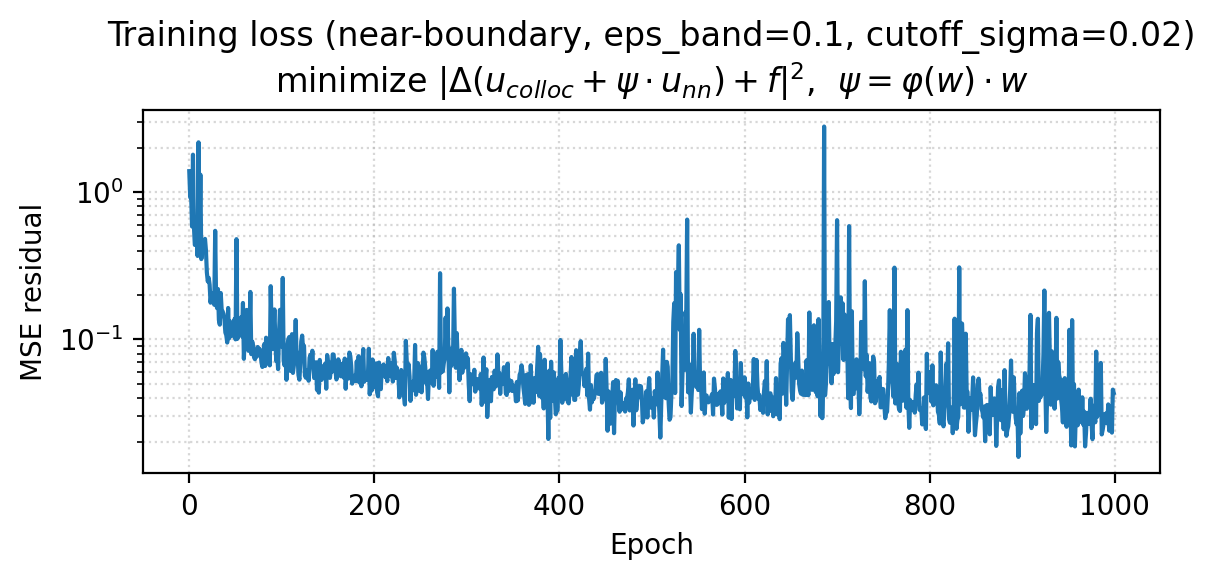

In [24]:
# ==========================================================================
# TRAINING LOOP
# Ansatz: u = u_colloc + psi * u_nn   where psi = phi(w) * w
# Loss:   mean( |colloc_residual + Δ(psi·u_nn)|² )
# Δ(psi·u_nn) = Δpsi·u_nn + 2(∇psi·∇u_nn) + psi·Δu_nn
# ==========================================================================
loss_history = []
rng_train = np.random.default_rng(123)

for epoch in range(NUM_EPOCHS):
    # Sub-sample a batch from the pre-computed pool
    idx = rng_train.choice(POOL_SIZE, size=BATCH_SIZE, replace=False)

    bx, by = pool_x[idx], pool_y[idx]
    b_colloc_res = pool_colloc_residual[idx]
    b_psi = pool_psi[idx]
    b_psi_x = pool_psi_x[idx]
    b_psi_y = pool_psi_y[idx]
    b_psi_xx = pool_psi_xx[idx]
    b_psi_yy = pool_psi_yy[idx]

    # Convert pre-computed constants to tensors
    colloc_residual_t = torch.tensor(b_colloc_res, dtype=torch.float64)
    psi_t = torch.tensor(b_psi, dtype=torch.float64)
    psi_x_t = torch.tensor(b_psi_x, dtype=torch.float64)
    psi_y_t = torch.tensor(b_psi_y, dtype=torch.float64)
    psi_xx_t = torch.tensor(b_psi_xx, dtype=torch.float64)
    psi_yy_t = torch.tensor(b_psi_yy, dtype=torch.float64)

    # ---- Neural network part (live tensors for autograd) ----
    crd = torch.tensor(np.stack([bx, by], axis=-1), dtype=torch.float64,
                       requires_grad=True)
    dists = compute_edge_distances(crd, VERTS_T)
    u_nn = model_nn(dists).squeeze() * DOWNSCALE

    # First derivatives via autograd
    grad_u_nn = torch.autograd.grad(
        u_nn, crd, grad_outputs=torch.ones_like(u_nn),
        create_graph=True, retain_graph=True
    )[0]
    u_nn_x = grad_u_nn[:, 0]
    u_nn_y = grad_u_nn[:, 1]

    # Second derivatives
    u_nn_xx = torch.autograd.grad(
        u_nn_x, crd, grad_outputs=torch.ones_like(u_nn_x),
        create_graph=True, retain_graph=True
    )[0][:, 0]
    u_nn_yy = torch.autograd.grad(
        u_nn_y, crd, grad_outputs=torch.ones_like(u_nn_y),
        create_graph=True, retain_graph=True
    )[0][:, 1]

    # Laplacian of (psi * u_nn) via product rule:
    # Δ(psi·u_nn) = Δpsi·u_nn + 2(∇psi·∇u_nn) + psi·Δu_nn
    laplacian_psi_u_nn = (
        (psi_xx_t + psi_yy_t) * u_nn
        + 2.0 * (psi_x_t * u_nn_x + psi_y_t * u_nn_y)
        + psi_t * (u_nn_xx + u_nn_yy)
    )

    total_residual = colloc_residual_t + laplacian_psi_u_nn
    loss = (total_residual ** 2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_val = loss.item()
    loss_history.append(loss_val)
    if epoch % 50 == 0 or epoch == NUM_EPOCHS - 1:
        print(f"epoch {epoch:4d}  loss={loss_val:.6e}")

# Plot training loss
fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogy(loss_history)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE residual")
ax.set_title(
    f"Training loss (near-boundary, eps_band={EPS_BAND}, cutoff_sigma={CUTOFF_SIGMA})\n"
    r"minimize $|\Delta(u_{colloc} + \psi \cdot u_{nn}) + f|^2$,  $\psi = \varphi(w) \cdot w$"
)
ax.grid(True, which="both", ls=":", alpha=0.5)
fig.tight_layout()
plt.show()

Sweep config: geom=triangle SDF R-function  n=2  H=32
Near-boundary sampling: eps_band=0.1, cutoff_sigma=0.02

Collocation only:      err_max=1.257e-03  err_mean=1.784e-05
Colloc + psi*u_nn:     err_max=1.692e-04   err_mean=8.850e-06
Improvement:           max err 7.4x  mean err 2.0x


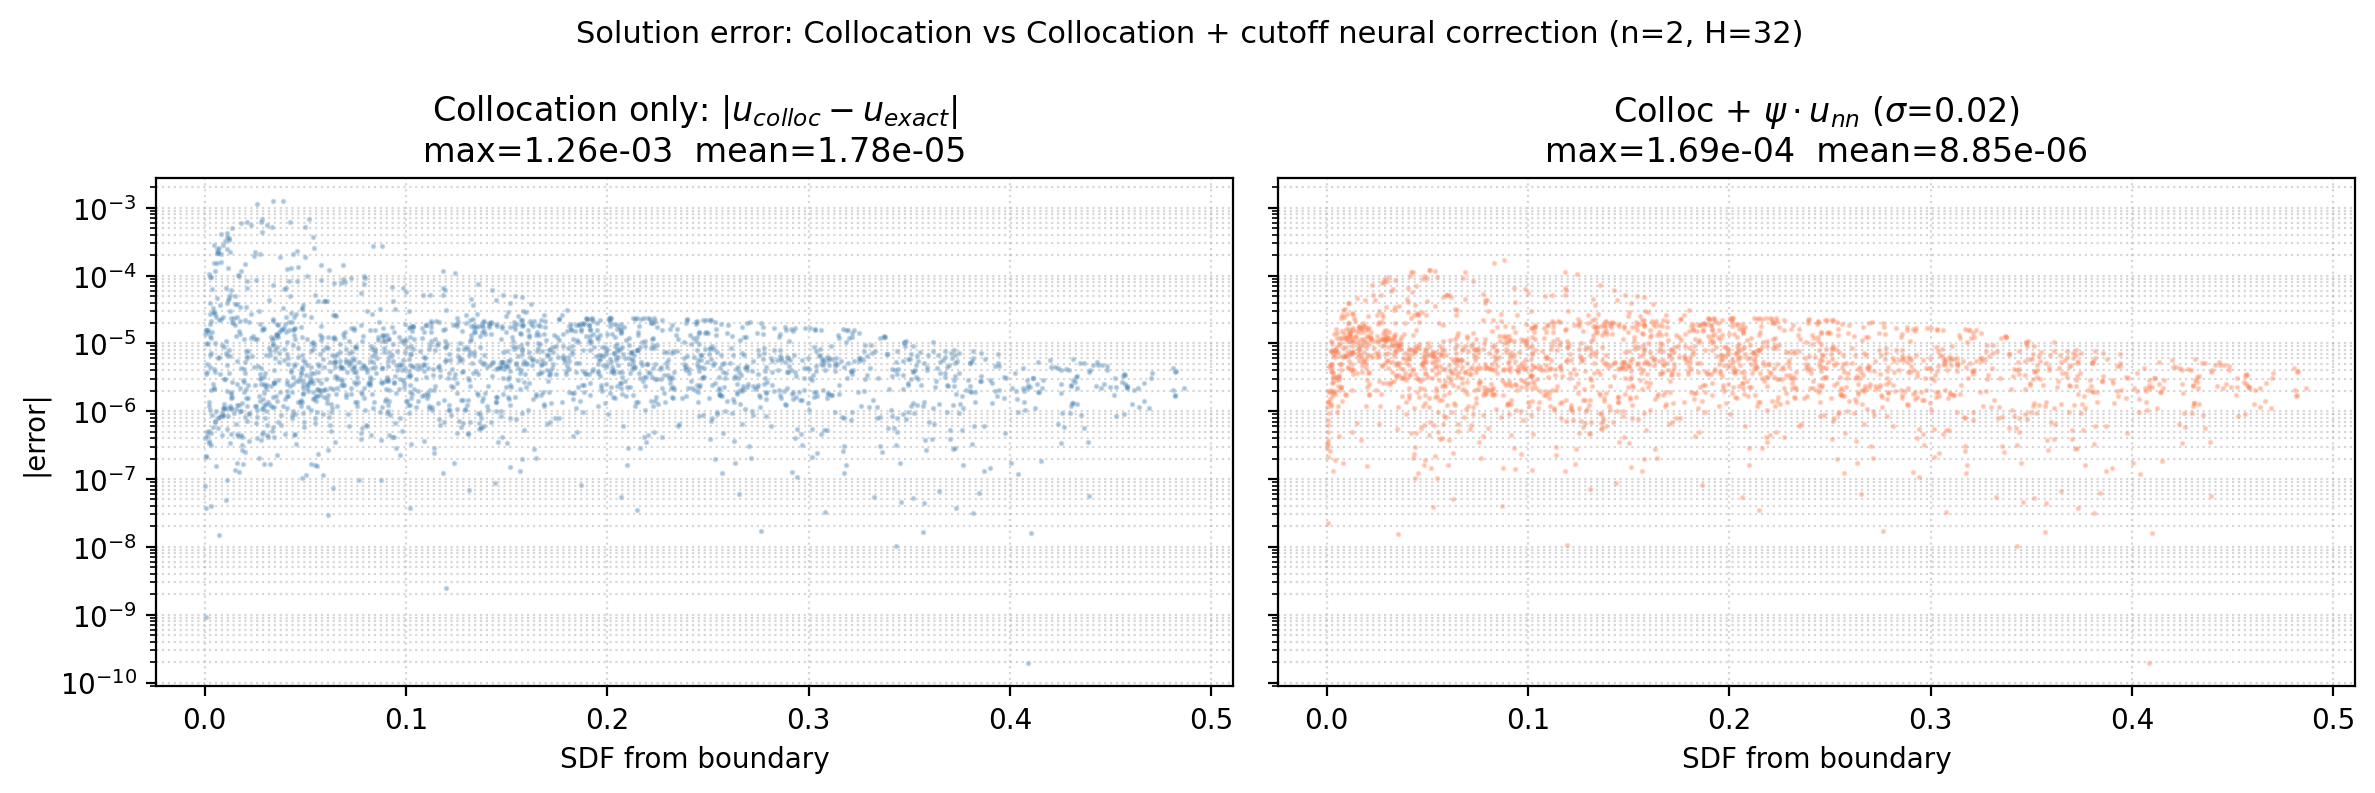

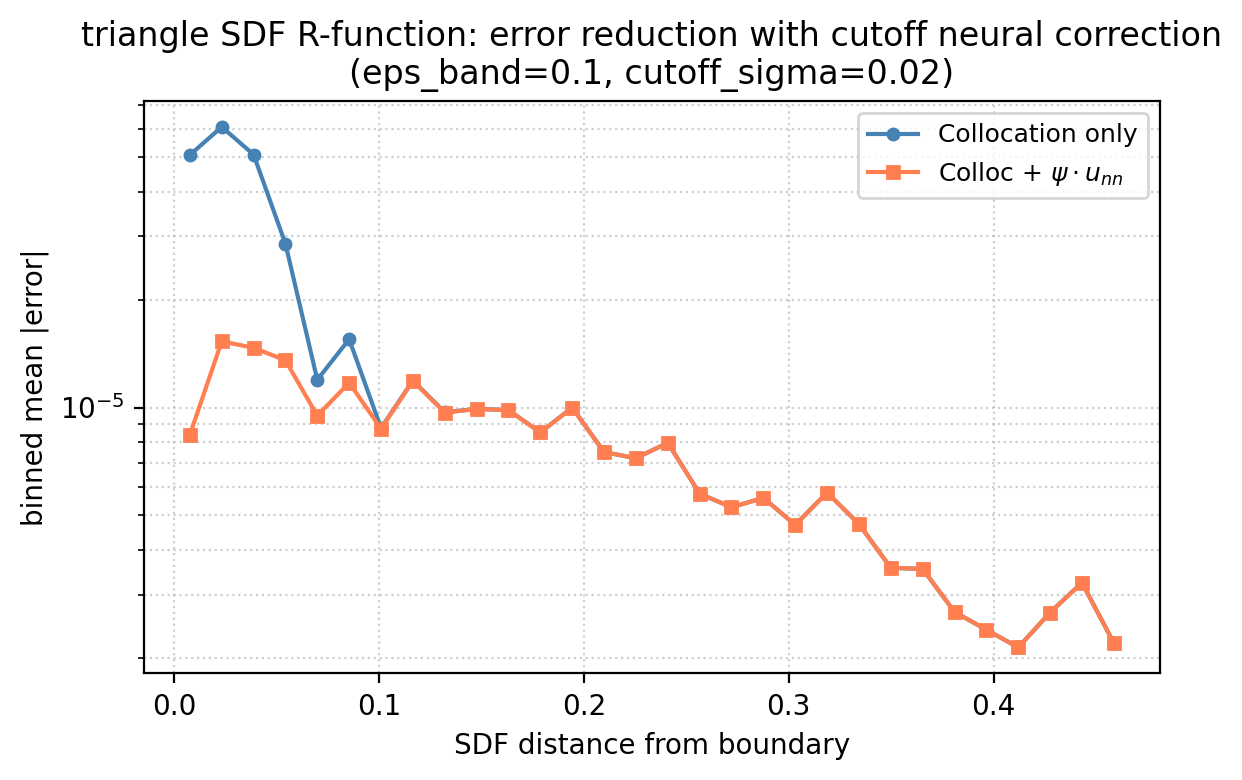

C:\Users\csapo\AppData\Local\Temp\ipykernel_2612\2989132661.py:441: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cf.collections:


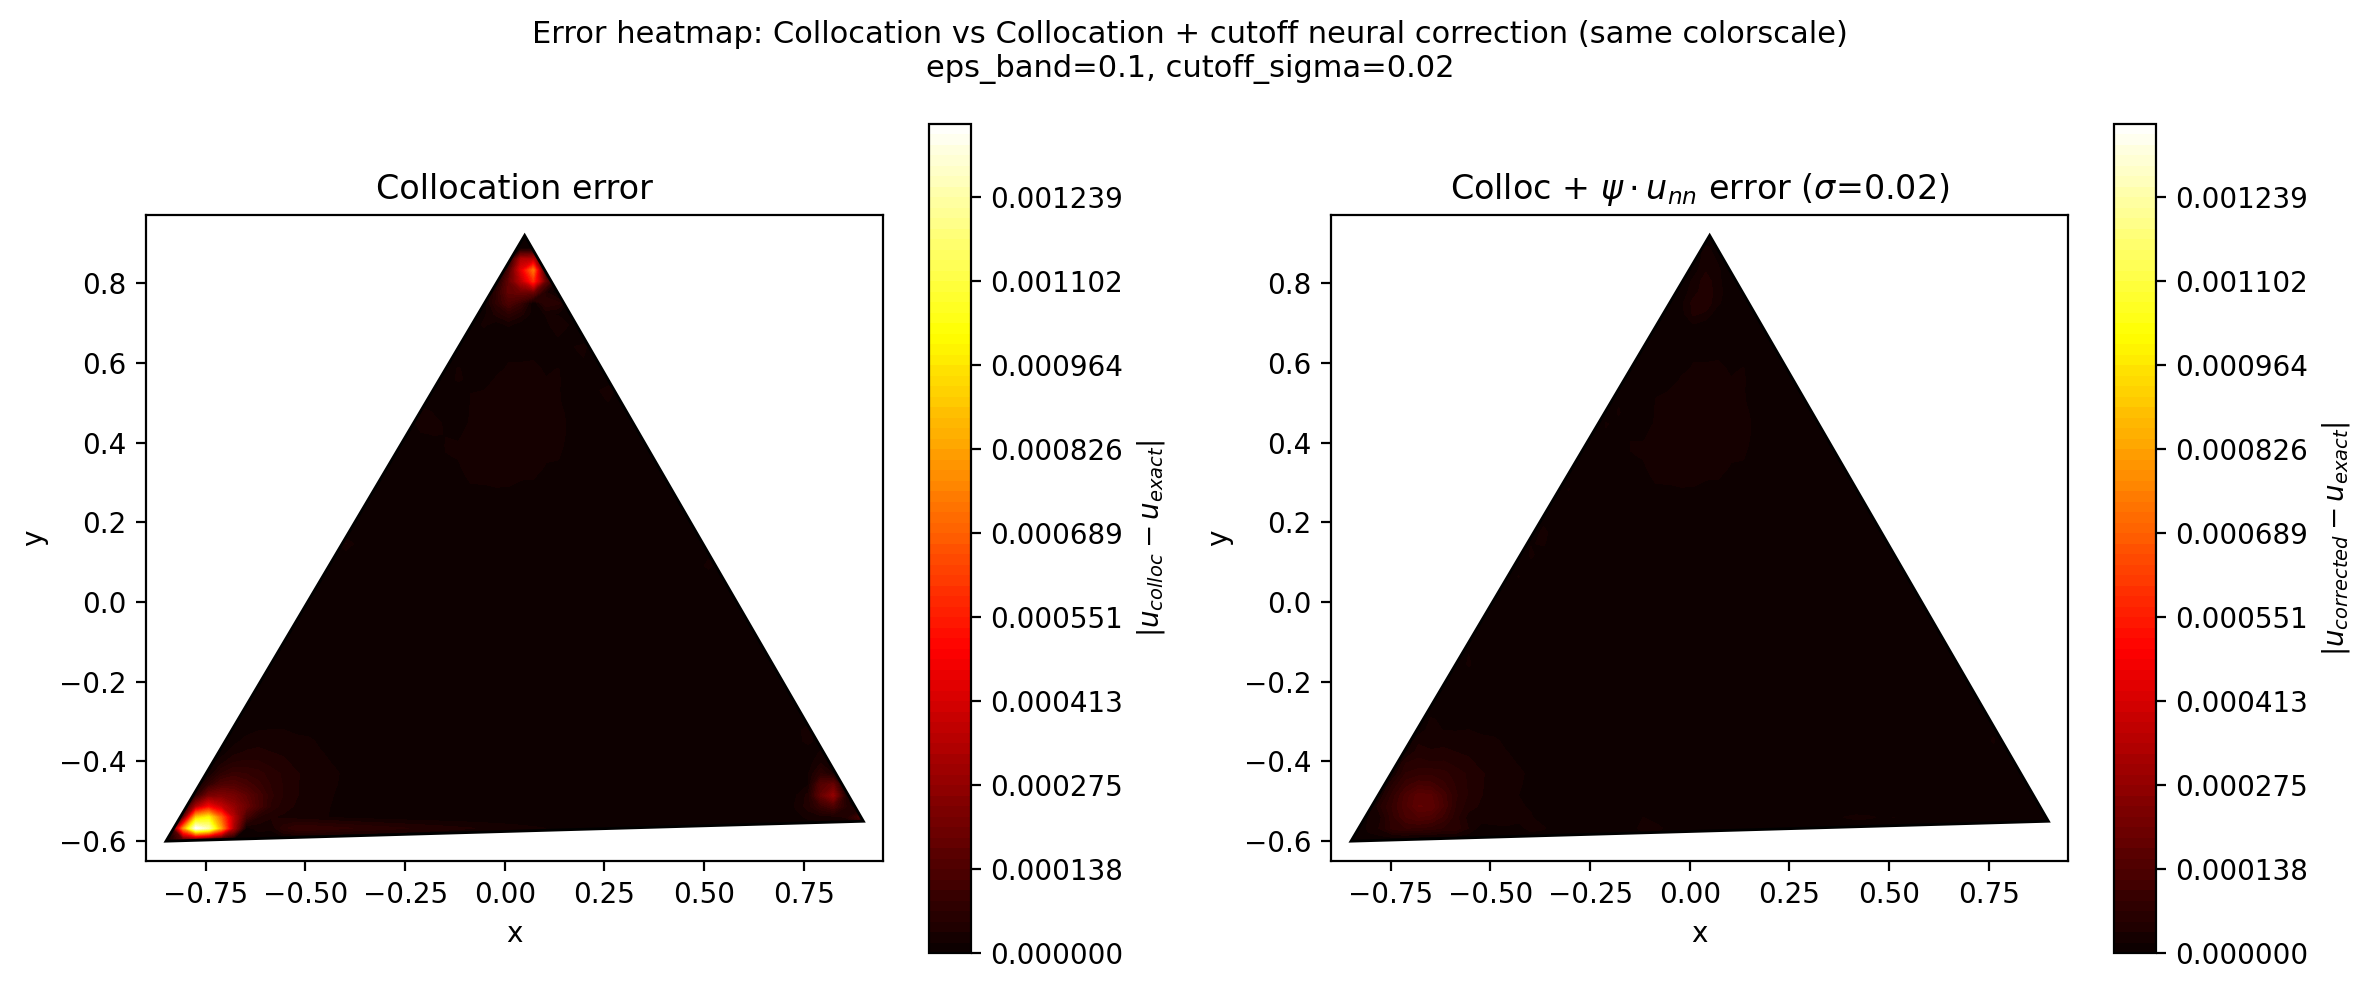

In [25]:
# ---- Evaluate the neural correction: u_corrected = u_colloc + psi * u_nn ----
# psi = phi(w) * w, where phi(w) = exp(-w^2 / (2*sigma^2))

N_EVAL = 2000

# Sample random interior points for evaluation
def _sample_interior(model, verts_np, n_pts):
    rng = np.random.default_rng(42)
    xmin, xmax = float(verts_np[:, 0].min()), float(verts_np[:, 0].max())
    ymin, ymax = float(verts_np[:, 1].min()), float(verts_np[:, 1].max())
    pts_x, pts_y = [], []
    while len(pts_x) < n_pts:
        batch = max(n_pts * 3, 5000)
        rx = rng.uniform(xmin, xmax, size=batch)
        ry = rng.uniform(ymin, ymax, size=batch)
        crd = torch.tensor(np.stack([rx, ry], axis=-1), dtype=torch.float64)
        verts_t = crd.new_tensor(verts_np)
        inside_mask = geom._point_in_convex_polygon_ccw(crd, verts_t).numpy()
        pts_x.append(rx[inside_mask])
        pts_y.append(ry[inside_mask])
    return np.concatenate(pts_x)[:n_pts], np.concatenate(pts_y)[:n_pts]

pts_x_plot, pts_y_plot = _sample_interior(model_corr, verts_np_corr, N_EVAL)

# ---- Collocation solution at evaluation points (B-spline basis) ----
u_h = colloc.reconstruct_collocation_at_points(pts_x_plot, pts_y_plot, recon_info_corr, wfct_phys_corr)

# ---- Exact solution ----
u_ex = u_exact_phys_corr(pts_x_plot, pts_y_plot)

# ---- Weight function w at evaluation points ----
w_eval, *_ = wfct_phys_corr(pts_x_plot, pts_y_plot)
w_eval = np.asarray(w_eval).ravel()

# ---- Cutoff phi(w) = exp(-w^2 / (2*sigma^2)) ----
phi_eval = np.exp(-w_eval**2 / (2.0 * CUTOFF_SIGMA**2))
psi_eval = phi_eval * w_eval

# ---- SDF for plotting ----
with torch.no_grad():
    crd_plot = torch.tensor(np.stack([pts_x_plot, pts_y_plot], axis=-1), dtype=torch.float64)
    verts_t = crd_plot.new_tensor(verts_np_corr)
    sdf_plot = geom.convex_polygon_sdf(crd_plot, verts_t).numpy().ravel()

# ---- Neural network correction at evaluation points ----
dists_plot = compute_edge_distances(crd_plot, VERTS_T)
with torch.no_grad():
    u_nn_eval = model_nn(dists_plot).squeeze().numpy()
u_nn_eval = u_nn_eval * DOWNSCALE

# Corrected solution: u = u_colloc + psi * u_nn  (psi = phi * w)
u_corrected = u_h + psi_eval * u_nn_eval

# ---- Errors ----
err_before = np.abs(u_h - u_ex)
err_after = np.abs(u_corrected - u_ex)

s_corr = res_corr["summary"]
print(f"Sweep config: geom={s_corr['geom']}  n={s_corr['n']}  H={s_corr['H']}")
print(f"Near-boundary sampling: eps_band={EPS_BAND}, cutoff_sigma={CUTOFF_SIGMA}")
print(f"\nCollocation only:      err_max={err_before.max():.3e}  err_mean={err_before.mean():.3e}")
print(f"Colloc + psi*u_nn:     err_max={err_after.max():.3e}   err_mean={err_after.mean():.3e}")
print(f"Improvement:           max err {err_before.max()/max(err_after.max(), 1e-30):.1f}x  "
      f"mean err {err_before.mean()/max(err_after.mean(), 1e-30):.1f}x")

valid = sdf_plot > 0

# ---- Binned error comparison ----
bins_before = compute_near_boundary_binning(w_inside=sdf_plot, err_inside=err_before, n_bins=30)
bins_after = compute_near_boundary_binning(w_inside=sdf_plot, err_inside=err_after, n_bins=30)

# ---- Plot 1: Scatter — error vs SDF before and after ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax1.scatter(sdf_plot[valid], err_before[valid], s=1, alpha=0.3, c="steelblue", rasterized=True)
ax1.set_yscale("log")
ax1.set_xlabel("SDF from boundary")
ax1.set_ylabel("|error|")
ax1.set_title(f"Collocation only: |$u_{{colloc}} - u_{{exact}}$|\n"
              f"max={err_before.max():.2e}  mean={err_before.mean():.2e}")
ax1.grid(True, which="both", ls=":", alpha=0.5)

ax2.scatter(sdf_plot[valid], err_after[valid], s=1, alpha=0.3, c="coral", rasterized=True)
ax2.set_yscale("log")
ax2.set_xlabel("SDF from boundary")
ax2.set_title(r"Colloc + $\psi \cdot u_{nn}$" + f" ($\\sigma$={CUTOFF_SIGMA})\n"
              f"max={err_after.max():.2e}  mean={err_after.mean():.2e}")
ax2.grid(True, which="both", ls=":", alpha=0.5)

fig.suptitle(f"Solution error: Collocation vs Collocation + cutoff neural correction "
             f"(n={s_corr['n']}, H={s_corr['H']})",
             fontsize=11)
fig.tight_layout()
plt.show()

# ---- Plot 2: Binned error comparison ----
fig, ax = plt.subplots(figsize=(6, 4))
if not bins_before.empty:
    ax.plot(bins_before["w_mid"], bins_before["err_mean"], marker="o", ms=4, lw=1.5,
            label="Collocation only", color="steelblue")
if not bins_after.empty:
    ax.plot(bins_after["w_mid"], bins_after["err_mean"], marker="s", ms=4, lw=1.5,
            label=r"Colloc + $\psi \cdot u_{nn}$", color="coral")
ax.set_yscale("log")
ax.set_xlabel("SDF distance from boundary")
ax.set_ylabel("binned mean |error|")
ax.set_title(f"{CORR_GEOM_NAME}: error reduction with cutoff neural correction\n"
             f"(eps_band={EPS_BAND}, cutoff_sigma={CUTOFF_SIGMA})")
ax.legend(fontsize=9)
ax.grid(True, which="both", ls=":", alpha=0.6)
fig.tight_layout()
plt.show()

# ---- Plot 3: Spatial error heatmap before/after ----
xmin_v, xmax_v = float(verts_np_corr[:, 0].min()), float(verts_np_corr[:, 0].max())
ymin_v, ymax_v = float(verts_np_corr[:, 1].min()), float(verts_np_corr[:, 1].max())
HN = 60
hm_x = np.linspace(xmin_v - 0.05, xmax_v + 0.05, HN)
hm_y = np.linspace(ymin_v - 0.05, ymax_v + 0.05, HN)
HX, HY = np.meshgrid(hm_x, hm_y)

# Evaluate on heatmap grid using B-spline basis
hm_flat_x = HX.ravel()
hm_flat_y = HY.ravel()
hm_u_colloc = colloc.reconstruct_collocation_at_points(hm_flat_x, hm_flat_y, recon_info_corr, wfct_phys_corr)
hm_u_ex = u_exact_phys_corr(hm_flat_x, hm_flat_y)

# Weight for masking
hm_w, *_ = wfct_phys_corr(hm_flat_x, hm_flat_y)
hm_w = np.asarray(hm_w).ravel()
hm_inside = hm_w > 0

# Neural correction on heatmap grid
hm_phi = np.exp(-hm_w**2 / (2.0 * CUTOFF_SIGMA**2))
hm_psi = hm_phi * hm_w

hm_crd = torch.tensor(np.stack([hm_flat_x, hm_flat_y], axis=-1), dtype=torch.float64)
hm_dists = compute_edge_distances(hm_crd, VERTS_T)
with torch.no_grad():
    hm_u_nn = model_nn(hm_dists).squeeze().numpy() * DOWNSCALE
hm_u_corr = hm_u_colloc + hm_psi * hm_u_nn

err_colloc_grid = np.abs(hm_u_colloc - hm_u_ex).reshape(HX.shape)
err_corr_grid = np.abs(hm_u_corr - hm_u_ex).reshape(HX.shape)
valid_grid = hm_inside.reshape(HX.shape)

# Set outside values to 0 for smooth contourf boundary
err_colloc_plot = err_colloc_grid.copy()
err_colloc_plot[~valid_grid] = 0.0
err_corr_plot = err_corr_grid.copy()
err_corr_plot[~valid_grid] = 0.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

vmax = np.max(err_colloc_grid[valid_grid]) if np.any(valid_grid) else 1e-6
levels_hm = np.linspace(0, vmax, 80)

im1 = ax1.contourf(HX, HY, err_colloc_plot, levels=levels_hm, cmap="hot")
_clip_contourf_to_polygon(im1, ax1, verts_np_corr)
fig.colorbar(im1, ax=ax1, label=r"$|u_{colloc} - u_{exact}|$")
ax1.set_title("Collocation error")
ax1.set_aspect("equal")

im2 = ax2.contourf(HX, HY, err_corr_plot, levels=levels_hm, cmap="hot")
_clip_contourf_to_polygon(im2, ax2, verts_np_corr)
fig.colorbar(im2, ax=ax2, label=r"$|u_{corrected} - u_{exact}|$")
ax2.set_title(r"Colloc + $\psi \cdot u_{nn}$ error ($\sigma$=" + f"{CUTOFF_SIGMA})")
ax2.set_aspect("equal")

# Draw exact polygon boundary on both
for ax in [ax1, ax2]:
    poly_patch = plt.Polygon(verts_np_corr, closed=True, fill=False,
                             edgecolor="k", linewidth=1.0)
    ax.add_patch(poly_patch)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.suptitle(f"Error heatmap: Collocation vs Collocation + cutoff neural correction (same colorscale)\n"
             f"eps_band={EPS_BAND}, cutoff_sigma={CUTOFF_SIGMA}", fontsize=11)
fig.tight_layout()
plt.show()

Derivative errors: triangle SDF R-function | n=2 H=32
DOWNSCALE=1, cutoff_sigma=0.02

 Deriv    Colloc max    Correc max   Improvement
   u_x     3.129e-02     2.832e-03          11.0x
   u_y     8.240e-02     5.070e-03          16.3x
  u_xx     1.802e+00     3.841e-01           4.7x
  u_yy     1.306e+01     8.556e-01          15.3x

      Norm    Colloc max    Correc max   Improvement
|grad err|     8.243e-02     5.075e-03          16.2x
|hess err|     1.306e+01     8.568e-01          15.2x


C:\Users\csapo\AppData\Local\Temp\ipykernel_2612\2989132661.py:441: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cf.collections:


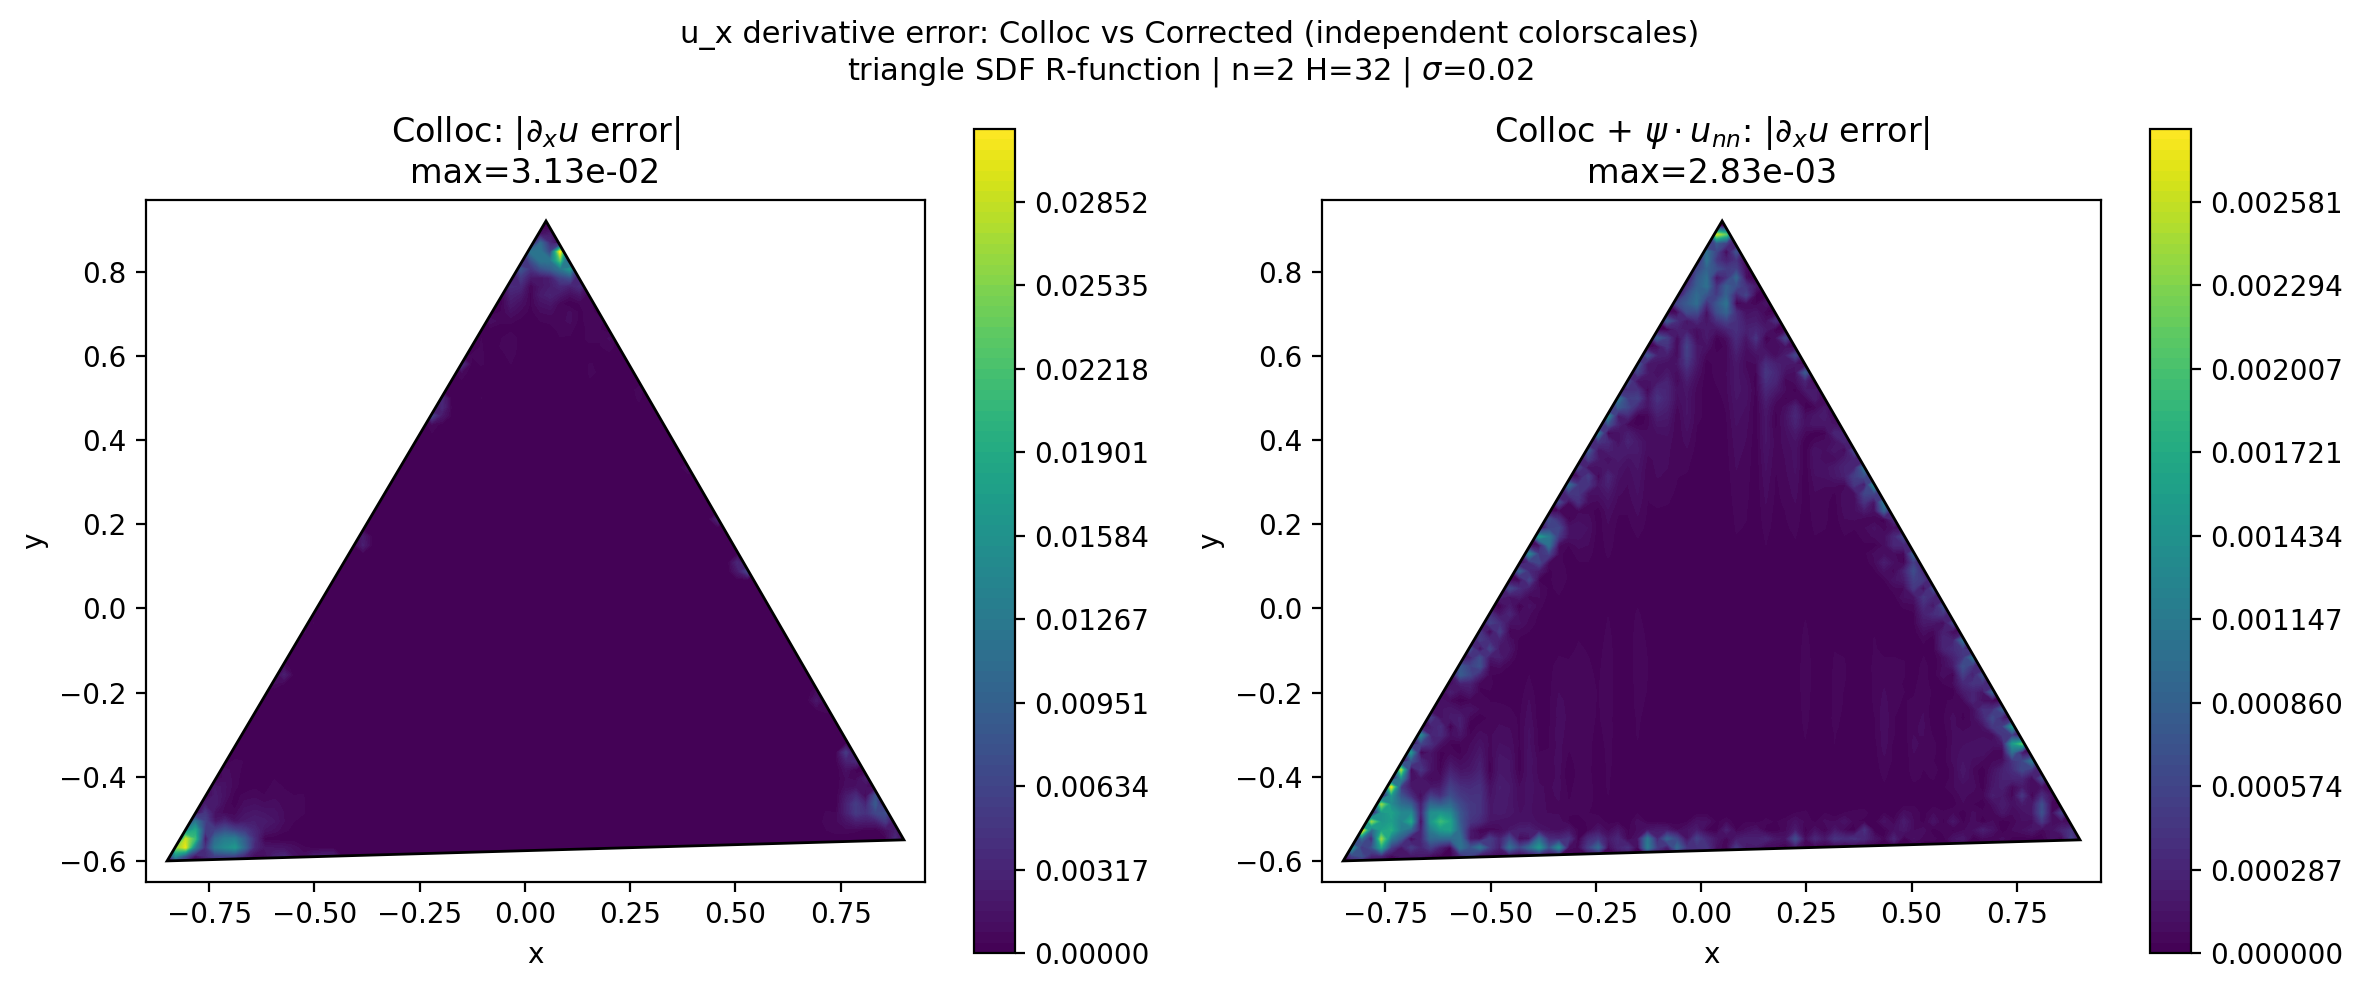

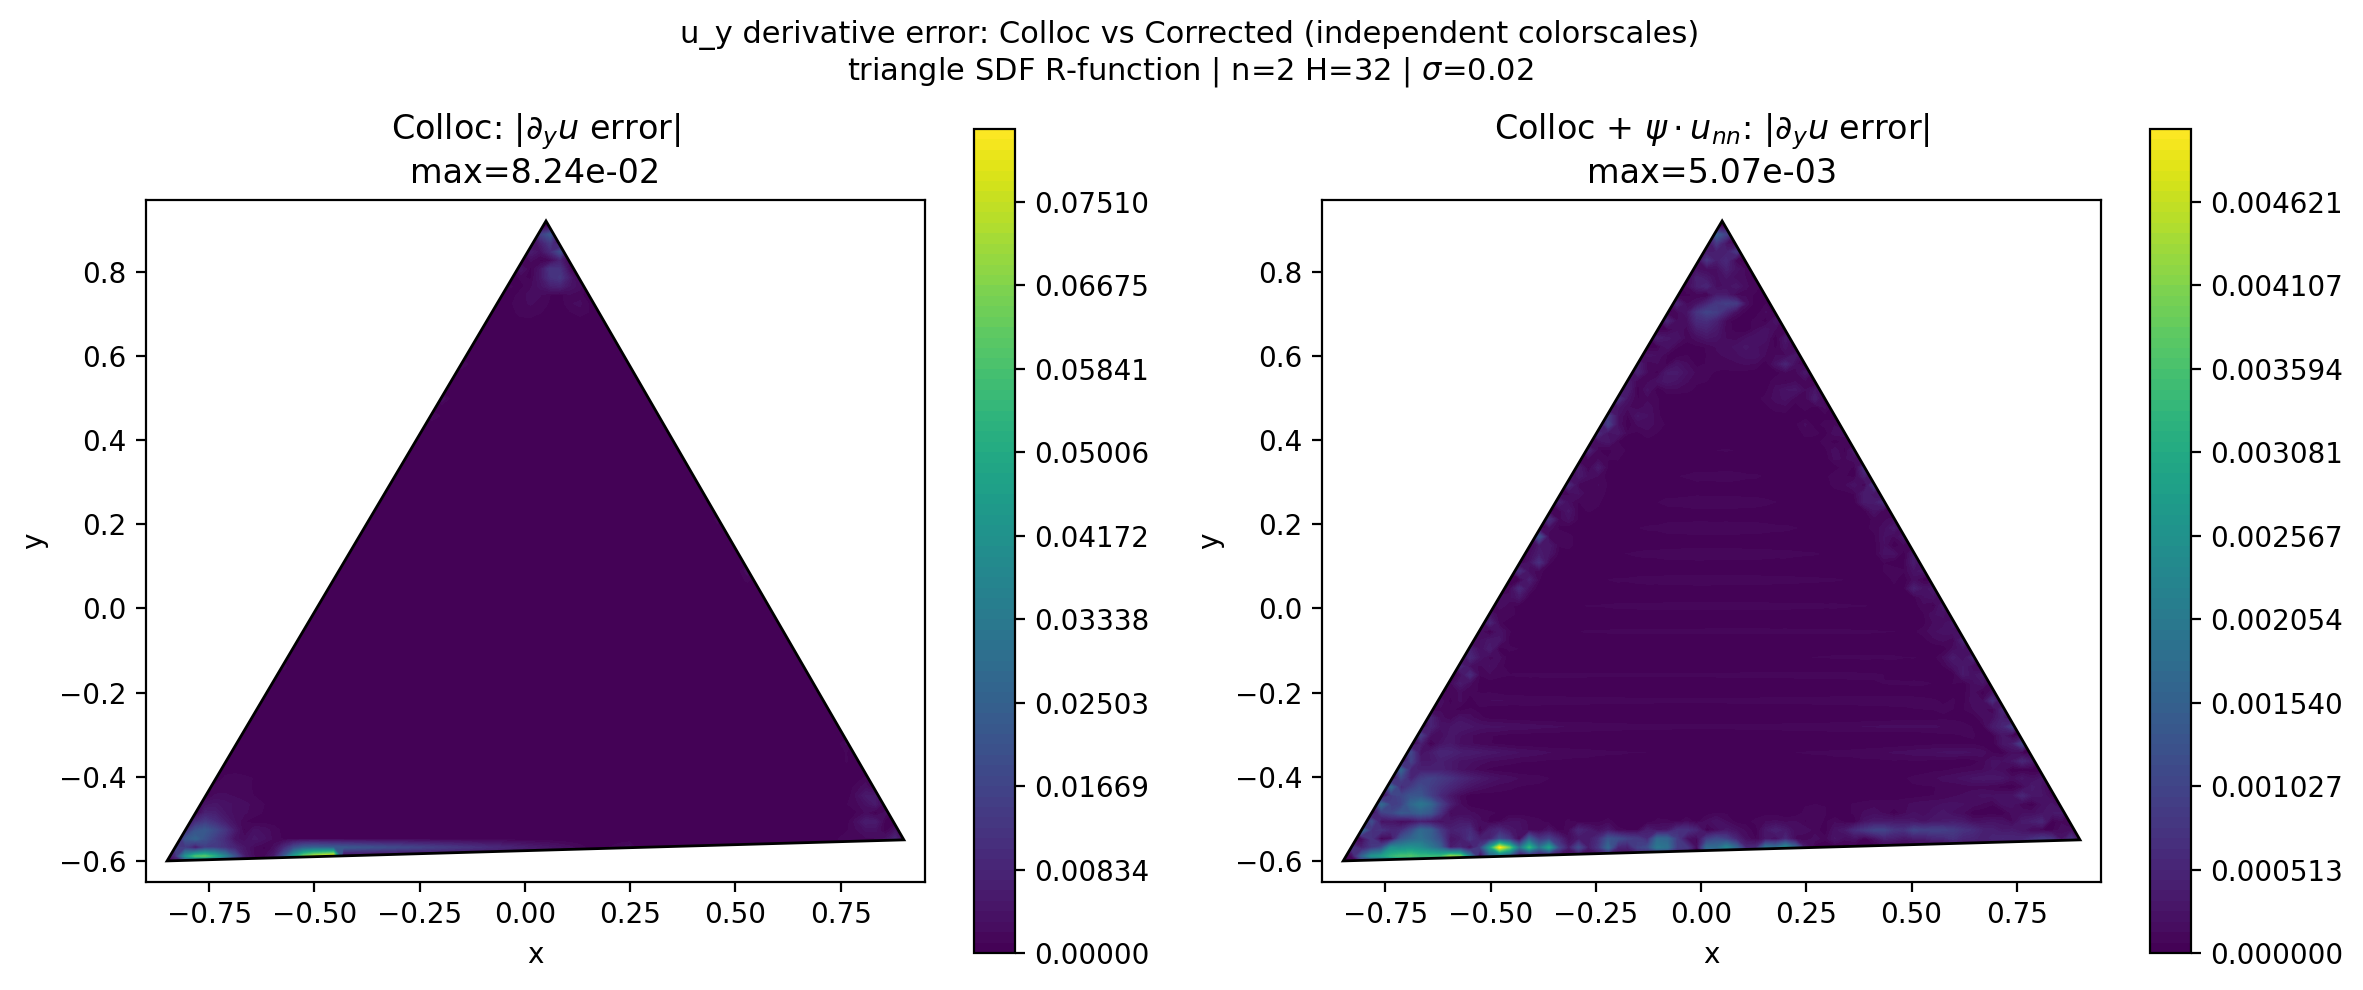

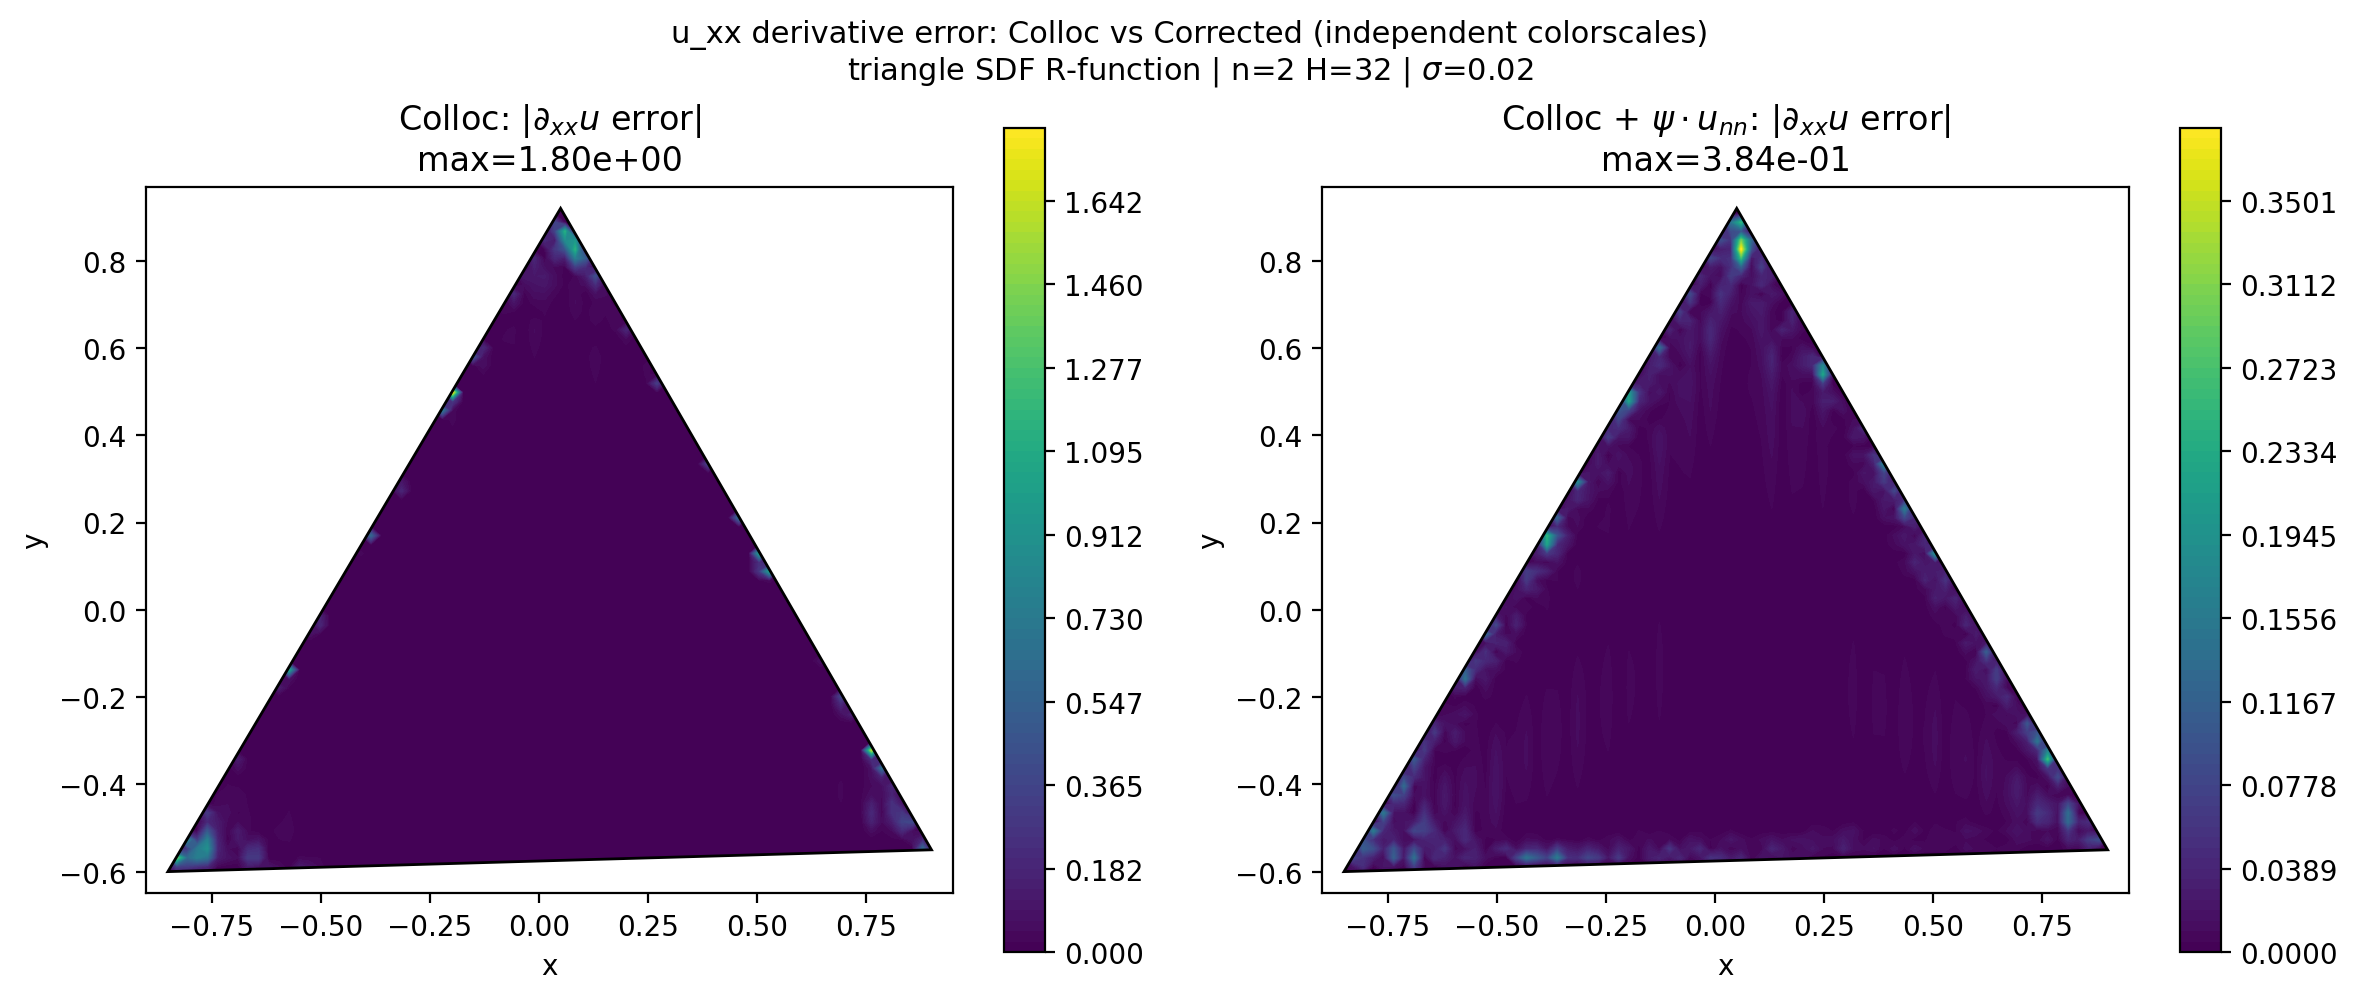

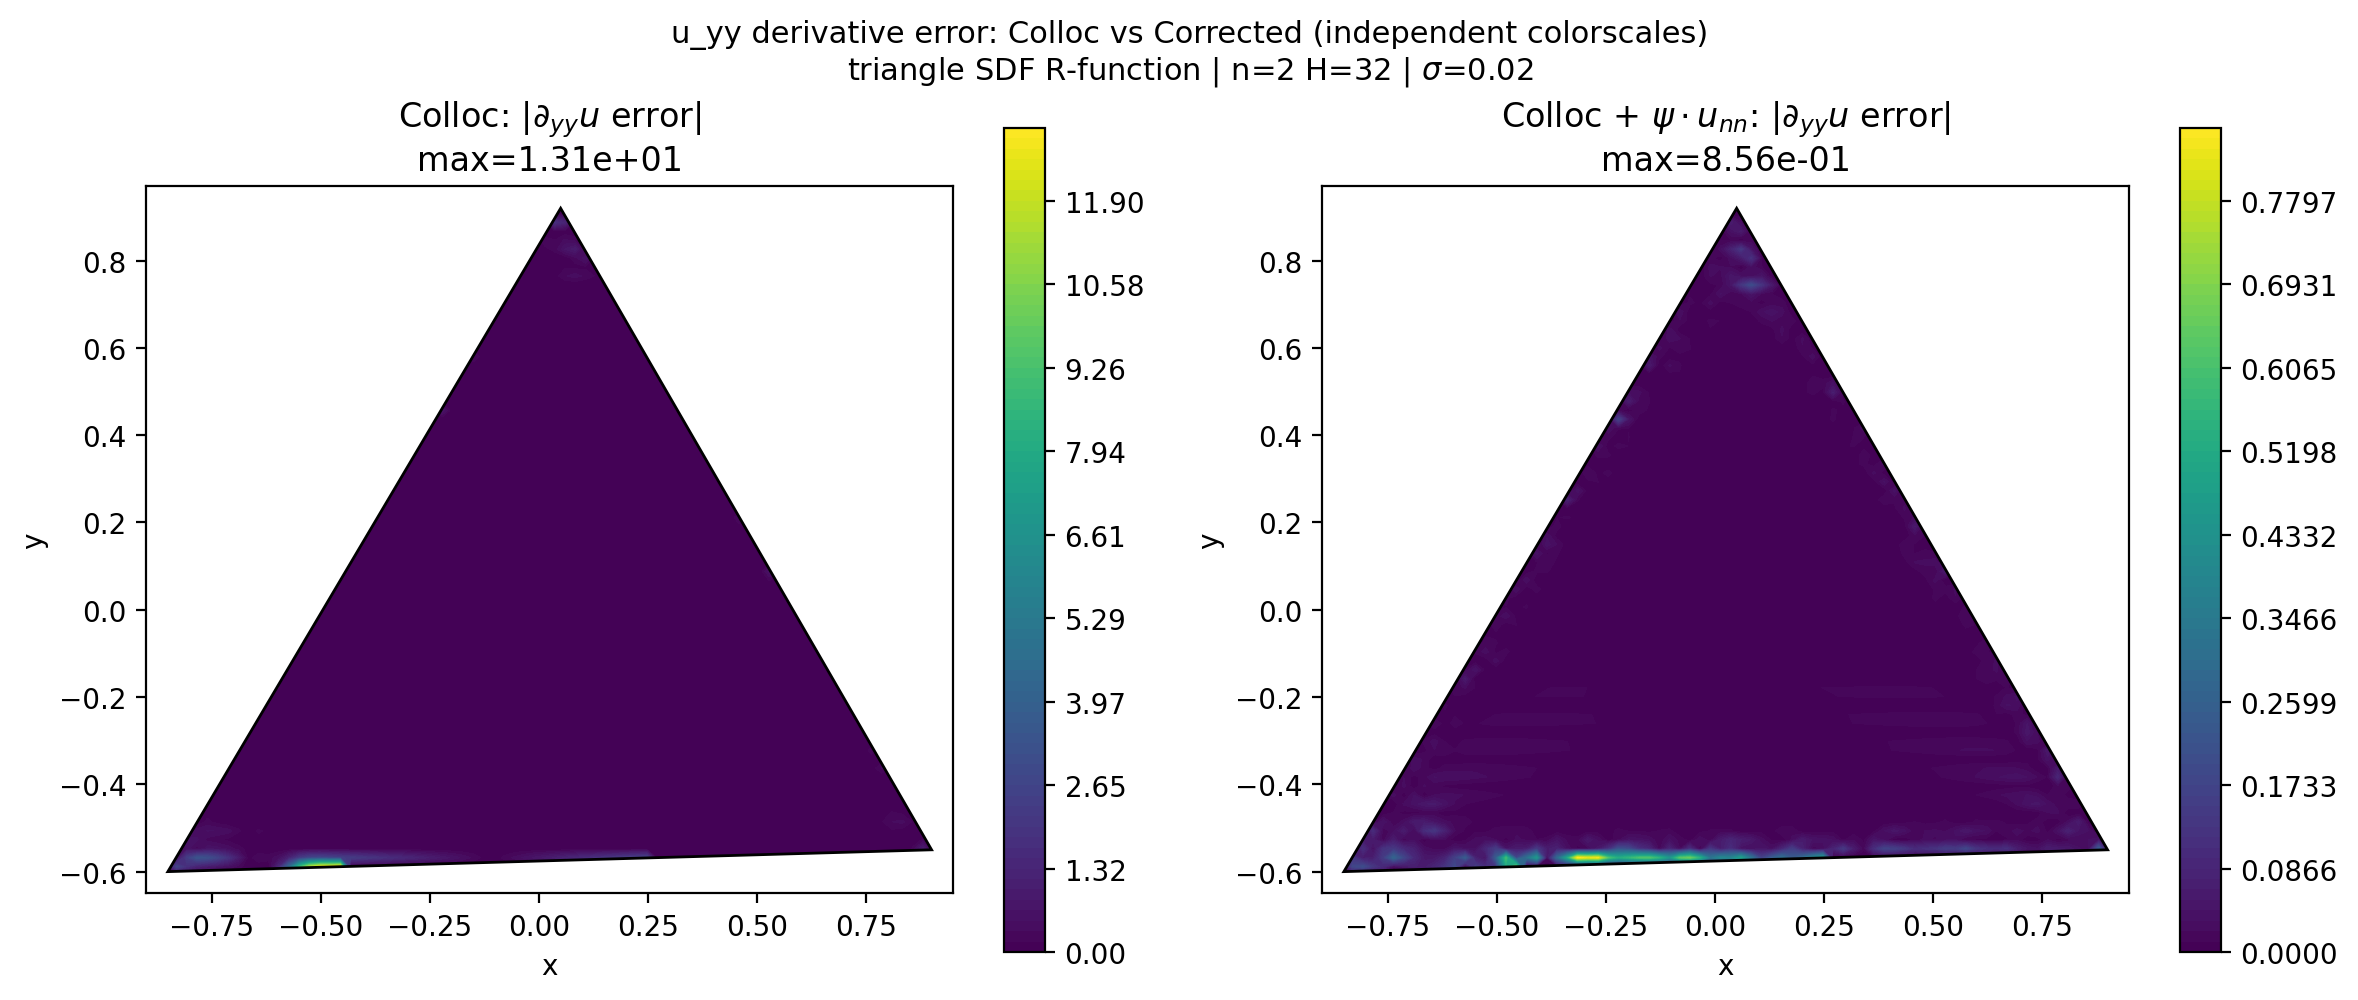

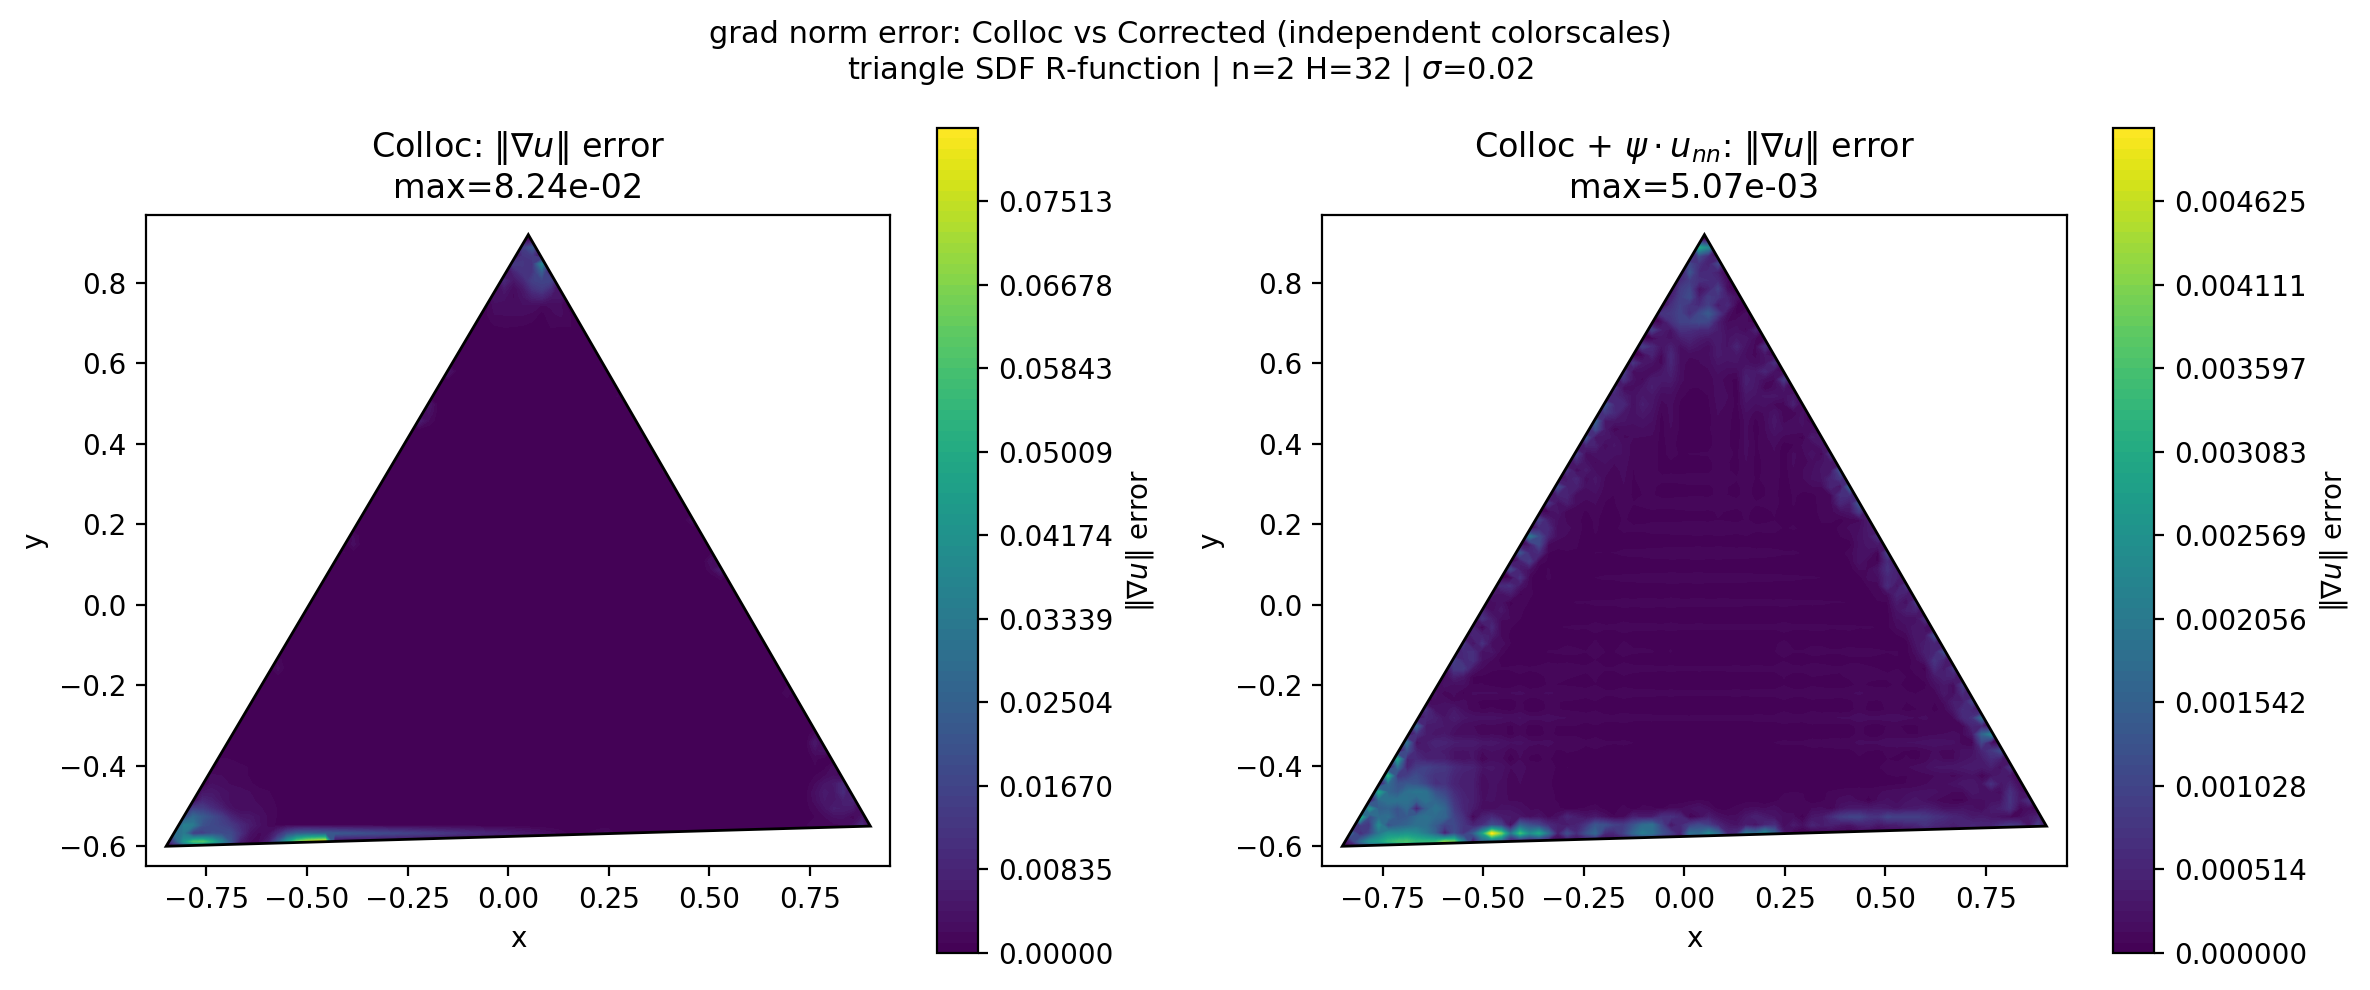

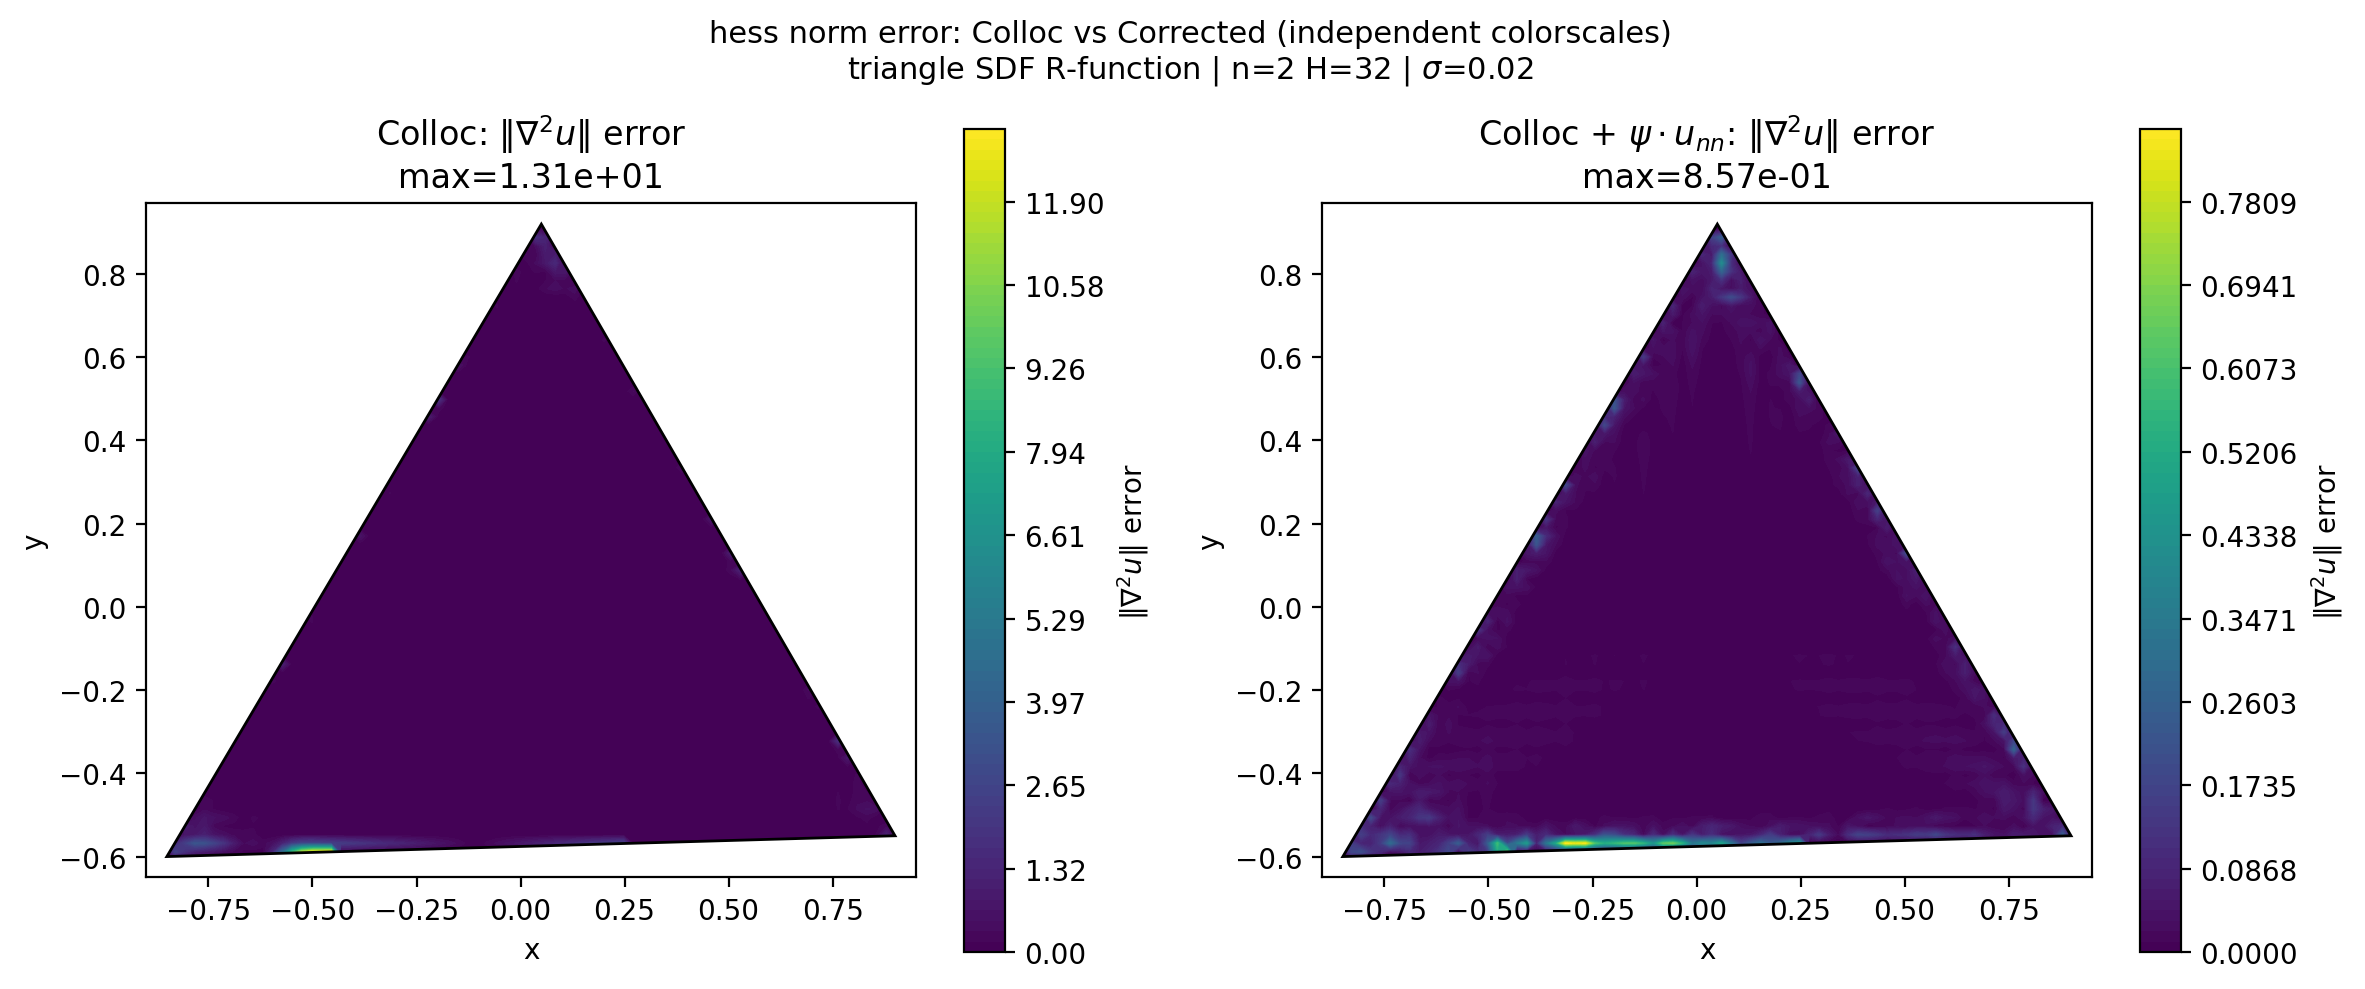

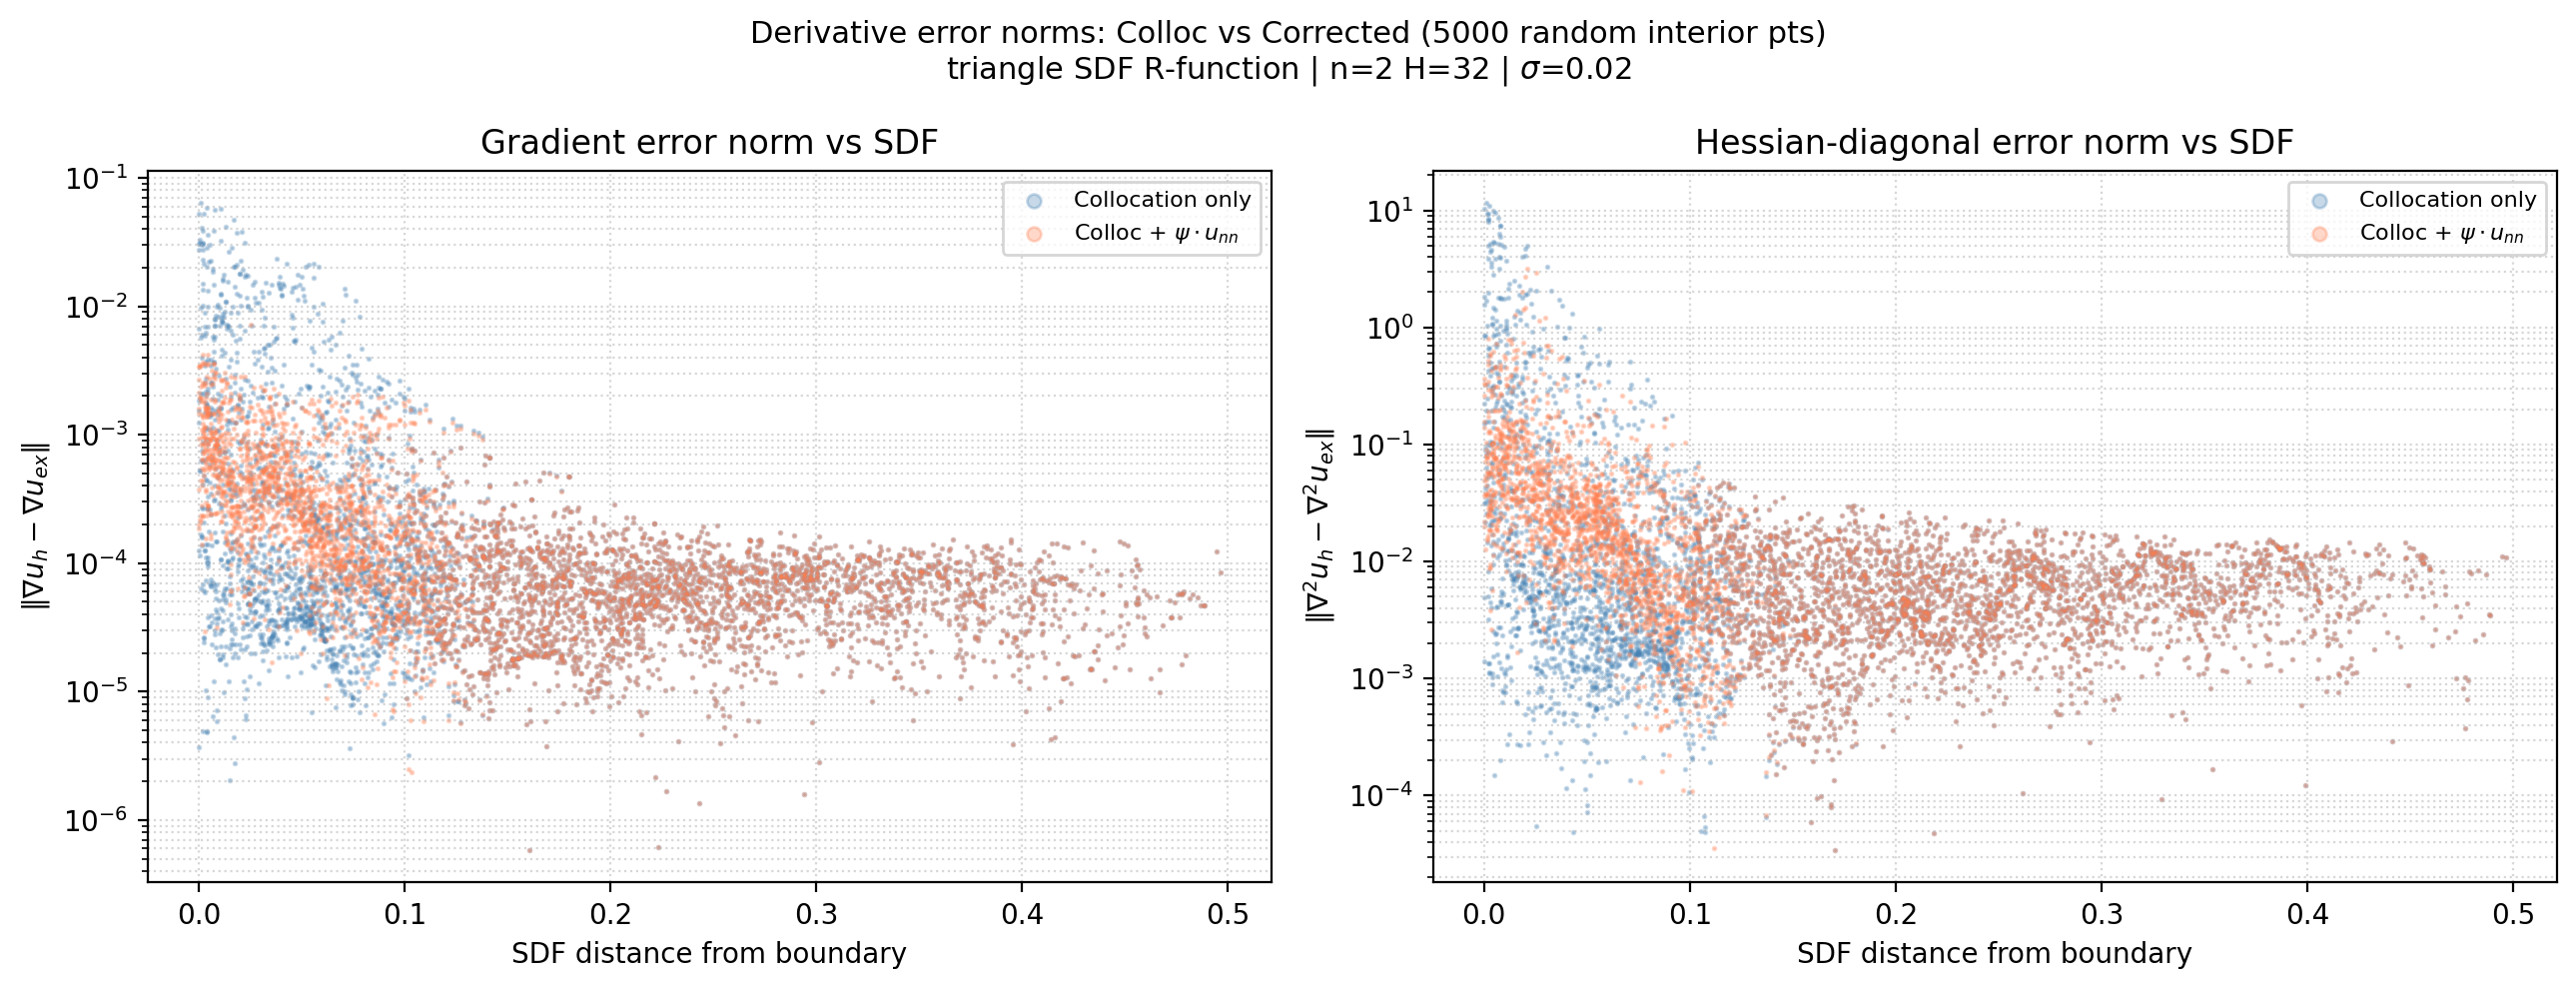

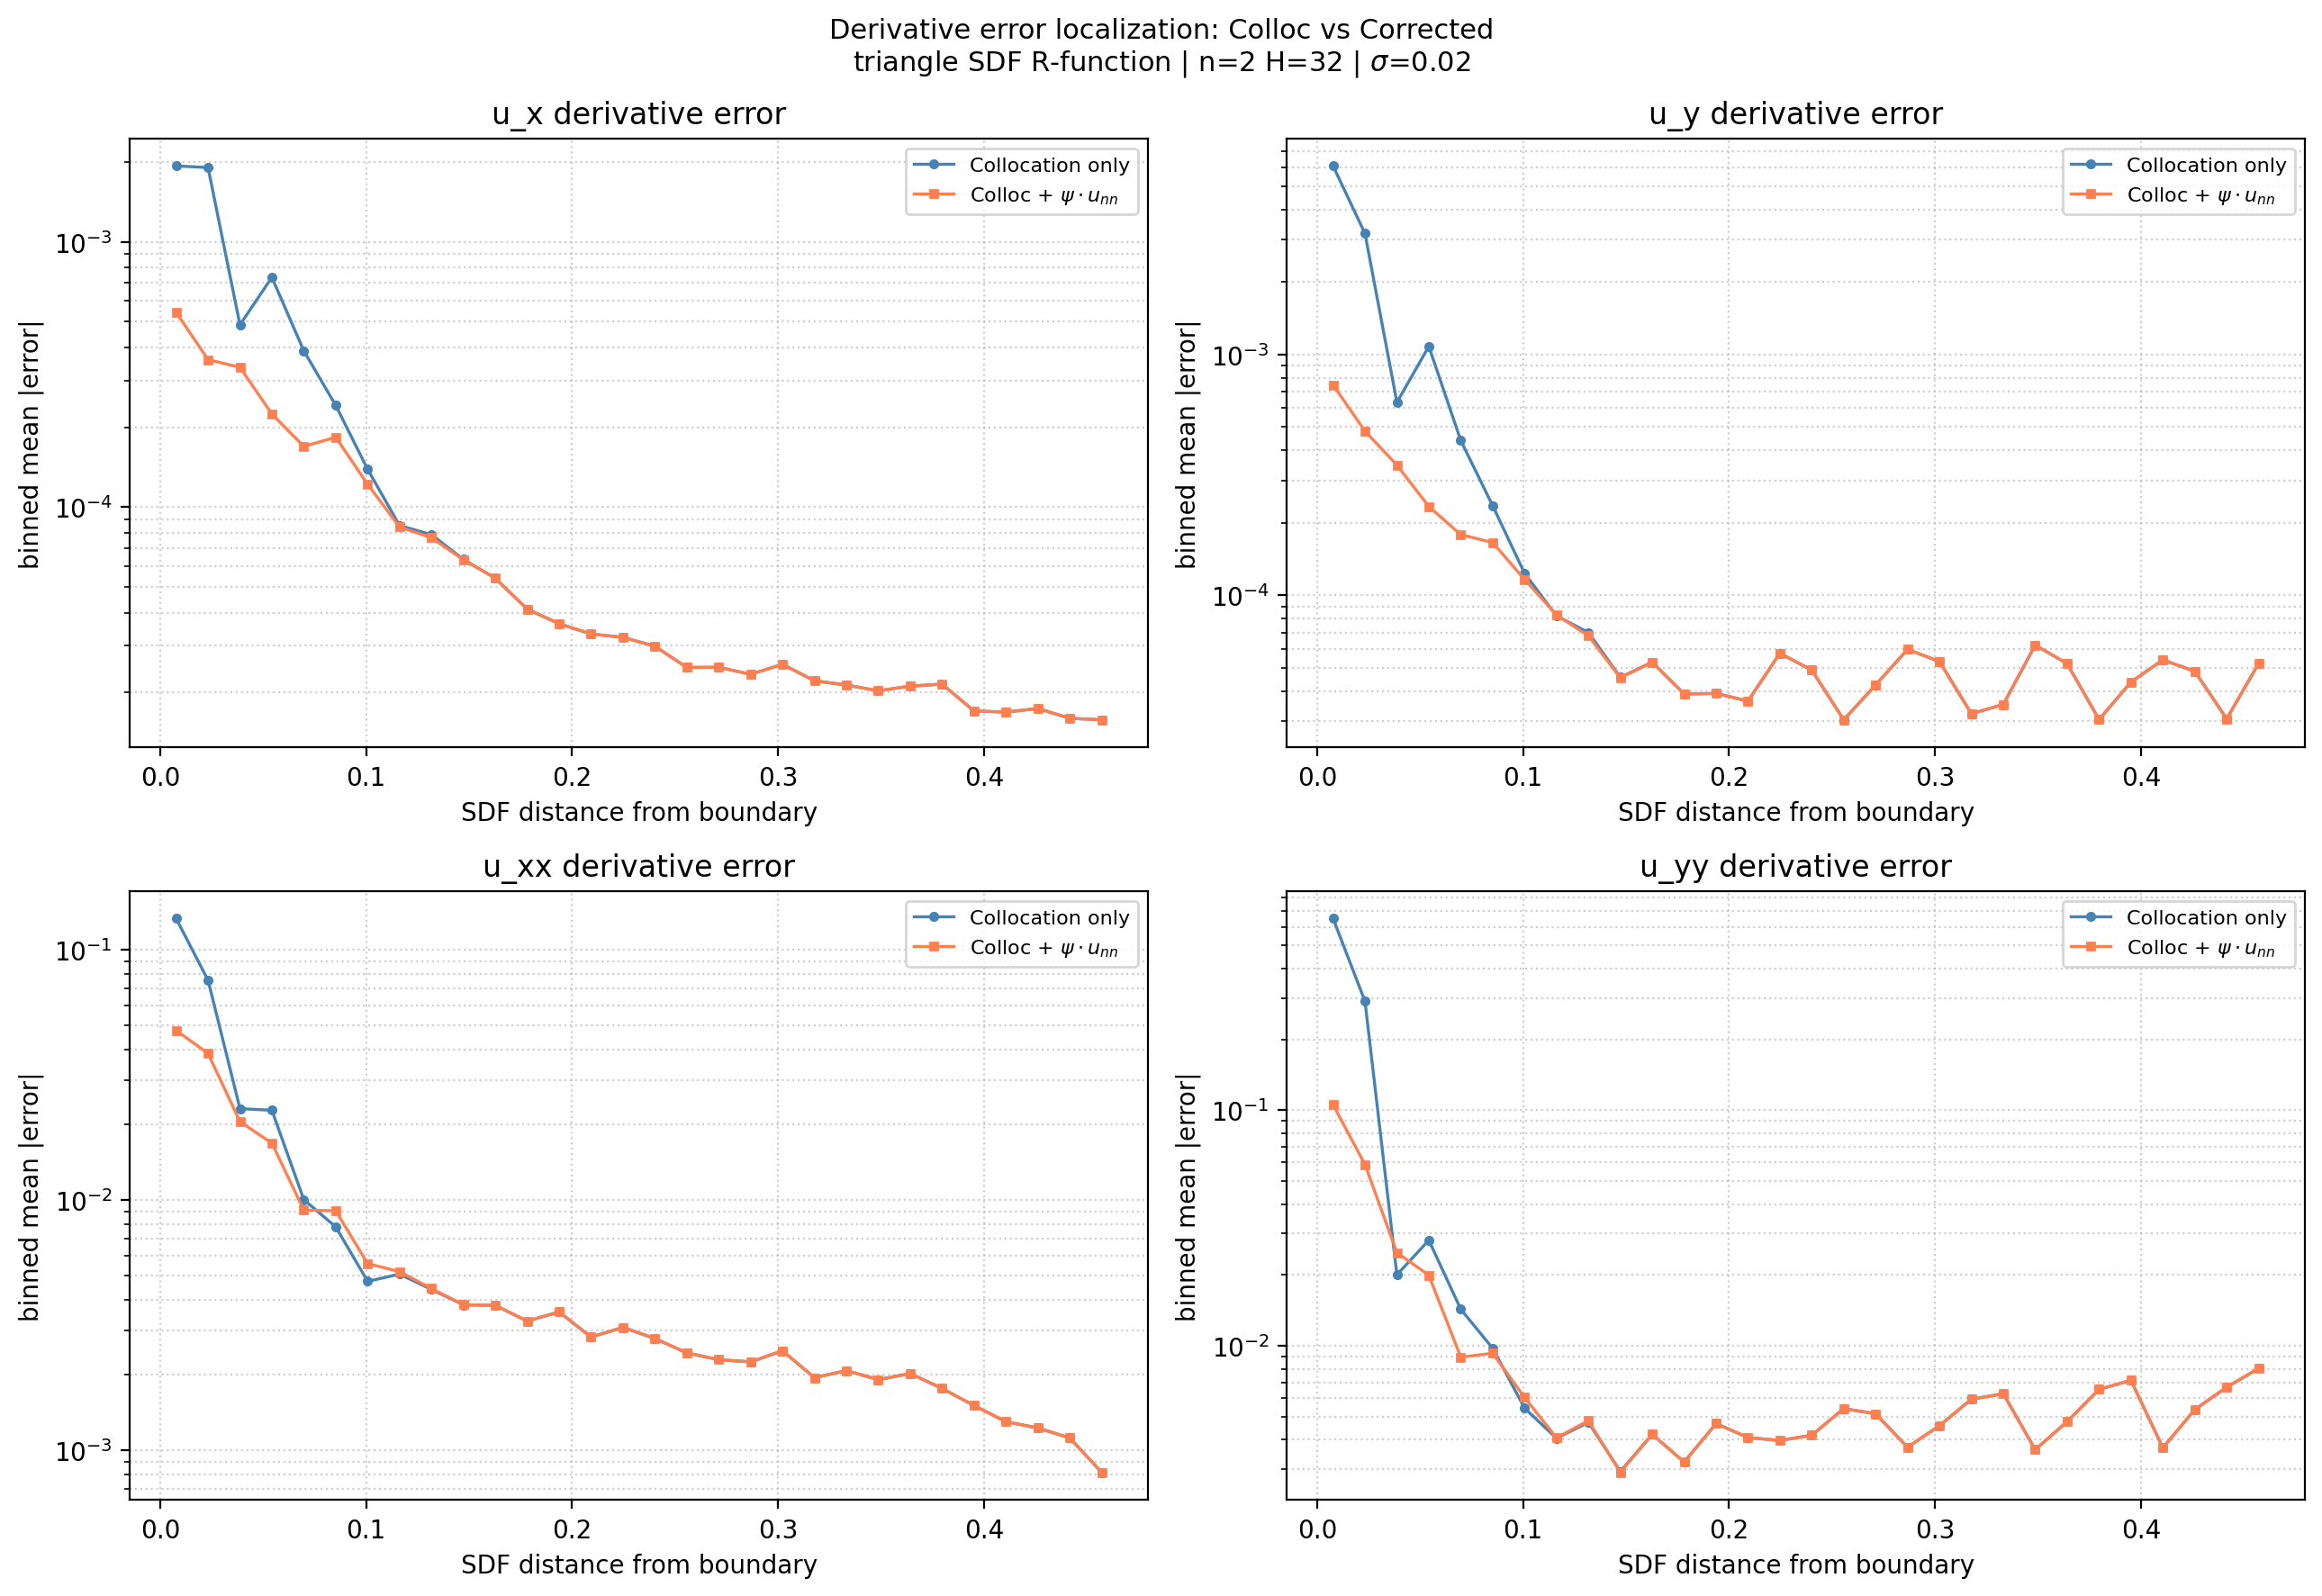

In [27]:
# ==========================================================================
# DERIVATIVE ERROR: Collocation vs Collocation + Neural Correction
# ==========================================================================
# All derivatives are computed analytically (no numeric finite differences):
#   - Collocation: B-spline basis differentiation (reconstruct_collocation_hessian_diag)
#   - Cutoff psi = phi(w)*w: chain + product rule from w derivatives
#   - Neural network u_nn: PyTorch autograd through halfplane distances
#
# Corrected solution:  u_corr = u_colloc + psi * u_nn
#   (u_corr)_x  = (u_colloc)_x  + psi_x * u_nn + psi * (u_nn)_x
#   (u_corr)_xx = (u_colloc)_xx + psi_xx * u_nn + 2*psi_x*(u_nn)_x + psi*(u_nn)_xx

HN_d = 80
xmin_d = float(verts_np_corr[:, 0].min()) - 0.05
xmax_d = float(verts_np_corr[:, 0].max()) + 0.05
ymin_d = float(verts_np_corr[:, 1].min()) - 0.05
ymax_d = float(verts_np_corr[:, 1].max()) + 0.05
gx_d = np.linspace(xmin_d, xmax_d, HN_d)
gy_d = np.linspace(ymin_d, ymax_d, HN_d)
GX_d, GY_d = np.meshgrid(gx_d, gy_d)
flat_xd, flat_yd = GX_d.ravel(), GY_d.ravel()

# --- Step 1: Collocation solution derivatives (analytical via B-spline) ---
u_col, ux_col, uy_col, uxx_col, uyy_col = colloc.reconstruct_collocation_hessian_diag(
    flat_xd, flat_yd, recon_info_corr, wfct_phys_corr)

# --- Step 2: Weight function w and its derivatives ---
w_d, wx_d, wy_d, wxx_d, wyy_d = wfct_phys_corr(flat_xd, flat_yd)
w_d, wx_d, wy_d, wxx_d, wyy_d = [np.asarray(a).ravel()
                                   for a in (w_d, wx_d, wy_d, wxx_d, wyy_d)]
inside_d = w_d > 0
valid_d = inside_d.reshape(GX_d.shape)

# --- Step 3: Cutoff psi = phi(w) * w and its spatial derivatives ---
s2_d = CUTOFF_SIGMA ** 2
phi_d = np.exp(-w_d**2 / (2.0 * s2_d))
phi_prime_d = -w_d / s2_d * phi_d
phi_dprime_d = (-1.0 / s2_d + w_d**2 / s2_d**2) * phi_d

phi_x_d = phi_prime_d * wx_d
phi_y_d = phi_prime_d * wy_d
phi_xx_d = phi_dprime_d * wx_d**2 + phi_prime_d * wxx_d
phi_yy_d = phi_dprime_d * wy_d**2 + phi_prime_d * wyy_d

psi_d = phi_d * w_d
psi_x_d = phi_x_d * w_d + phi_d * wx_d
psi_y_d = phi_y_d * w_d + phi_d * wy_d
psi_xx_d = phi_xx_d * w_d + 2.0 * phi_x_d * wx_d + phi_d * wxx_d
psi_yy_d = phi_yy_d * w_d + 2.0 * phi_y_d * wy_d + phi_d * wyy_d

# --- Step 4: Neural network u_nn and its derivatives via PyTorch autograd ---
crd_d = torch.tensor(np.stack([flat_xd, flat_yd], axis=-1), dtype=torch.float64,
                     requires_grad=True)
dists_d = compute_edge_distances(crd_d, VERTS_T)
u_nn_d = model_nn(dists_d).squeeze() * DOWNSCALE

# First derivatives
grad_u_nn_d = torch.autograd.grad(
    u_nn_d.sum(), crd_d, create_graph=True, retain_graph=True)[0]
u_nn_x_d = grad_u_nn_d[:, 0]
u_nn_y_d = grad_u_nn_d[:, 1]

# Second derivatives
u_nn_xx_d = torch.autograd.grad(
    u_nn_x_d.sum(), crd_d, create_graph=False, retain_graph=True)[0][:, 0]
u_nn_yy_d = torch.autograd.grad(
    u_nn_y_d.sum(), crd_d, create_graph=False)[0][:, 1]

# Convert to numpy
u_nn_np = u_nn_d.detach().numpy()
u_nn_x_np = u_nn_x_d.detach().numpy()
u_nn_y_np = u_nn_y_d.detach().numpy()
u_nn_xx_np = u_nn_xx_d.detach().numpy()
u_nn_yy_np = u_nn_yy_d.detach().numpy()

# --- Step 5: Corrected solution derivatives via product rule ---
ux_corr = ux_col + psi_x_d * u_nn_np + psi_d * u_nn_x_np
uy_corr = uy_col + psi_y_d * u_nn_np + psi_d * u_nn_y_np
uxx_corr = uxx_col + psi_xx_d * u_nn_np + 2.0 * psi_x_d * u_nn_x_np + psi_d * u_nn_xx_np
uyy_corr = uyy_col + psi_yy_d * u_nn_np + 2.0 * psi_y_d * u_nn_y_np + psi_d * u_nn_yy_np

# --- Step 6: Exact solution derivatives ---
ux_ex_d, uy_ex_d, uxx_ex_d, uyy_ex_d = compute_exact_derivatives(
    wfct_phys_corr, flat_xd, flat_yd, U_EXACT_TYPE)

# --- Step 7: Derivative errors ---
err_ux_col = np.abs(ux_col - ux_ex_d)
err_uy_col = np.abs(uy_col - uy_ex_d)
err_uxx_col = np.abs(uxx_col - uxx_ex_d)
err_uyy_col = np.abs(uyy_col - uyy_ex_d)

err_ux_corr = np.abs(ux_corr - ux_ex_d)
err_uy_corr = np.abs(uy_corr - uy_ex_d)
err_uxx_corr = np.abs(uxx_corr - uxx_ex_d)
err_uyy_corr = np.abs(uyy_corr - uyy_ex_d)

# --- Print summary ---
print(f"Derivative errors: {CORR_GEOM_NAME} | n={CORR_N} H={CORR_H}")
print(f"DOWNSCALE={DOWNSCALE}, cutoff_sigma={CUTOFF_SIGMA}")
print(f"\n{'Deriv':>6s}  {'Colloc max':>12s}  {'Correc max':>12s}  {'Improvement':>12s}")
for label, e_col, e_corr in [
    ("u_x", err_ux_col, err_ux_corr),
    ("u_y", err_uy_col, err_uy_corr),
    ("u_xx", err_uxx_col, err_uxx_corr),
    ("u_yy", err_uyy_col, err_uyy_corr),
]:
    mc = float(np.max(e_col[inside_d])) if np.any(inside_d) else float("nan")
    mr = float(np.max(e_corr[inside_d])) if np.any(inside_d) else float("nan")
    imp = mc / max(mr, 1e-30)
    print(f"{label:>6s}  {mc:12.3e}  {mr:12.3e}  {imp:12.1f}x")

# --- Gradient and Hessian-diagonal error norms ---
grad_err_col = np.sqrt(err_ux_col**2 + err_uy_col**2)
grad_err_corr = np.sqrt(err_ux_corr**2 + err_uy_corr**2)
hess_err_col = np.sqrt(err_uxx_col**2 + err_uyy_col**2)
hess_err_corr = np.sqrt(err_uxx_corr**2 + err_uyy_corr**2)

print(f"\n{'Norm':>10s}  {'Colloc max':>12s}  {'Correc max':>12s}  {'Improvement':>12s}")
for label, e_col, e_corr in [
    ("|grad err|", grad_err_col, grad_err_corr),
    ("|hess err|", hess_err_col, hess_err_corr),
]:
    mc = float(np.max(e_col[inside_d])) if np.any(inside_d) else float("nan")
    mr = float(np.max(e_corr[inside_d])) if np.any(inside_d) else float("nan")
    imp = mc / max(mr, 1e-30)
    print(f"{label:>10s}  {mc:12.3e}  {mr:12.3e}  {imp:12.1f}x")

# --- SDF for binning ---
with torch.no_grad():
    crd_sdf = torch.tensor(np.stack([flat_xd, flat_yd], axis=-1), dtype=torch.float64)
    verts_sdf = crd_sdf.new_tensor(verts_np_corr)
    sdf_d = geom.convex_polygon_sdf(crd_sdf, verts_sdf).numpy().ravel()
sdf_inside_d = sdf_d[inside_d]

# --- Heatmaps: before/after for each derivative (INDEPENDENT colorscales) ---
deriv_compare = [
    (r"$\partial_x u$", "u_x", err_ux_col, err_ux_corr),
    (r"$\partial_y u$", "u_y", err_uy_col, err_uy_corr),
    (r"$\partial_{xx} u$", "u_xx", err_uxx_col, err_uxx_corr),
    (r"$\partial_{yy} u$", "u_yy", err_uyy_col, err_uyy_corr),
]

for latex_label, short_label, e_col, e_corr in deriv_compare:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    e_col_grid = e_col.reshape(GX_d.shape)
    e_corr_grid = e_corr.reshape(GX_d.shape)

    # Set outside to 0 for smooth boundary
    e_col_plot = e_col_grid.copy()
    e_col_plot[~valid_d] = 0.0
    e_corr_plot = e_corr_grid.copy()
    e_corr_plot[~valid_d] = 0.0

    # Independent colorscale per subplot
    emax_col = float(np.max(e_col_grid[valid_d])) if np.any(valid_d) else 1e-10
    emax_corr = float(np.max(e_corr_grid[valid_d])) if np.any(valid_d) else 1e-10
    levels_col = np.linspace(0, emax_col, 80)
    levels_corr = np.linspace(0, emax_corr, 80)

    im1 = ax1.contourf(GX_d, GY_d, e_col_plot, levels=levels_col)
    _clip_contourf_to_polygon(im1, ax1, verts_np_corr)
    fig.colorbar(im1, ax=ax1)
    ax1.set_title(f"Colloc: |{latex_label} error|\nmax={emax_col:.2e}")
    ax1.set_aspect("equal")

    im2 = ax2.contourf(GX_d, GY_d, e_corr_plot, levels=levels_corr)
    _clip_contourf_to_polygon(im2, ax2, verts_np_corr)
    fig.colorbar(im2, ax=ax2)
    ax2.set_title("Colloc + " + r"$\psi \cdot u_{nn}$" + f": |{latex_label} error|\nmax={emax_corr:.2e}")
    ax2.set_aspect("equal")

    for ax in [ax1, ax2]:
        poly_patch = plt.Polygon(verts_np_corr, closed=True, fill=False,
                                 edgecolor="k", linewidth=1.0)
        ax.add_patch(poly_patch)
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    fig.suptitle(
        f"{short_label} derivative error: Colloc vs Corrected (independent colorscales)\n"
        f"{CORR_GEOM_NAME} | n={CORR_N} H={CORR_H} | "
        + r"$\sigma$" + f"={CUTOFF_SIGMA}",
        fontsize=11)
    fig.tight_layout()
    plt.show()

# --- Heatmaps: gradient and Hessian error norms (independent colorscales) ---
norm_compare = [
    (r"$\|\nabla u\|$ error", "grad", grad_err_col, grad_err_corr),
    (r"$\|\nabla^2 u\|$ error", "hess", hess_err_col, hess_err_corr),
]

for latex_label, short_label, e_col, e_corr in norm_compare:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    e_col_grid = e_col.reshape(GX_d.shape)
    e_corr_grid = e_corr.reshape(GX_d.shape)

    e_col_plot = e_col_grid.copy()
    e_col_plot[~valid_d] = 0.0
    e_corr_plot = e_corr_grid.copy()
    e_corr_plot[~valid_d] = 0.0

    emax_col = float(np.max(e_col_grid[valid_d])) if np.any(valid_d) else 1e-10
    emax_corr = float(np.max(e_corr_grid[valid_d])) if np.any(valid_d) else 1e-10
    levels_col = np.linspace(0, emax_col, 80)
    levels_corr = np.linspace(0, emax_corr, 80)

    im1 = ax1.contourf(GX_d, GY_d, e_col_plot, levels=levels_col)
    _clip_contourf_to_polygon(im1, ax1, verts_np_corr)
    fig.colorbar(im1, ax=ax1, label=latex_label)
    ax1.set_title(f"Colloc: {latex_label}\nmax={emax_col:.2e}")
    ax1.set_aspect("equal")

    im2 = ax2.contourf(GX_d, GY_d, e_corr_plot, levels=levels_corr)
    _clip_contourf_to_polygon(im2, ax2, verts_np_corr)
    fig.colorbar(im2, ax=ax2, label=latex_label)
    ax2.set_title("Colloc + " + r"$\psi \cdot u_{nn}$" + f": {latex_label}\nmax={emax_corr:.2e}")
    ax2.set_aspect("equal")

    for ax in [ax1, ax2]:
        poly_patch = plt.Polygon(verts_np_corr, closed=True, fill=False,
                                 edgecolor="k", linewidth=1.0)
        ax.add_patch(poly_patch)
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    fig.suptitle(
        f"{short_label} norm error: Colloc vs Corrected (independent colorscales)\n"
        f"{CORR_GEOM_NAME} | n={CORR_N} H={CORR_H} | "
        + r"$\sigma$" + f"={CUTOFF_SIGMA}",
        fontsize=11)
    fig.tight_layout()
    plt.show()

# --- Scatter plot: derivative error norms vs SDF (random interior points) ---
N_SCATTER_D = 5000
rng_d = np.random.default_rng(99)

# Rejection sample interior points
xmin_s = float(verts_np_corr[:, 0].min())
xmax_s = float(verts_np_corr[:, 0].max())
ymin_s = float(verts_np_corr[:, 1].min())
ymax_s = float(verts_np_corr[:, 1].max())
sc_x, sc_y = [], []
while len(sc_x) < N_SCATTER_D:
    batch = max(N_SCATTER_D * 3, 10000)
    rx = rng_d.uniform(xmin_s, xmax_s, size=batch)
    ry = rng_d.uniform(ymin_s, ymax_s, size=batch)
    crd_s = torch.tensor(np.stack([rx, ry], axis=-1), dtype=torch.float64)
    verts_s = crd_s.new_tensor(verts_np_corr)
    mask_s = geom._point_in_convex_polygon_ccw(crd_s, verts_s).numpy()
    sc_x.append(rx[mask_s])
    sc_y.append(ry[mask_s])
sc_x = np.concatenate(sc_x)[:N_SCATTER_D]
sc_y = np.concatenate(sc_y)[:N_SCATTER_D]

# Collocation derivatives at scatter points
_, sux_col, suy_col, suxx_col, suyy_col = colloc.reconstruct_collocation_hessian_diag(
    sc_x, sc_y, recon_info_corr, wfct_phys_corr)

# Weight function + psi derivatives at scatter points
sw, swx, swy, swxx, swyy = wfct_phys_corr(sc_x, sc_y)
sw, swx, swy, swxx, swyy = [np.asarray(a).ravel() for a in (sw, swx, swy, swxx, swyy)]

sphi = np.exp(-sw**2 / (2.0 * s2_d))
sphi_p = -sw / s2_d * sphi
sphi_pp = (-1.0 / s2_d + sw**2 / s2_d**2) * sphi
sphi_x = sphi_p * swx
sphi_y = sphi_p * swy
sphi_xx = sphi_pp * swx**2 + sphi_p * swxx
sphi_yy = sphi_pp * swy**2 + sphi_p * swyy
spsi = sphi * sw
spsi_x = sphi_x * sw + sphi * swx
spsi_y = sphi_y * sw + sphi * swy
spsi_xx = sphi_xx * sw + 2.0 * sphi_x * swx + sphi * swxx
spsi_yy = sphi_yy * sw + 2.0 * sphi_y * swy + sphi * swyy

# Neural network derivatives at scatter points (autograd)
scrd = torch.tensor(np.stack([sc_x, sc_y], axis=-1), dtype=torch.float64, requires_grad=True)
sdists = compute_edge_distances(scrd, VERTS_T)
su_nn = model_nn(sdists).squeeze() * DOWNSCALE
sgrad_nn = torch.autograd.grad(su_nn.sum(), scrd, create_graph=True, retain_graph=True)[0]
su_nn_x = sgrad_nn[:, 0]
su_nn_y = sgrad_nn[:, 1]
su_nn_xx = torch.autograd.grad(su_nn_x.sum(), scrd, create_graph=False, retain_graph=True)[0][:, 0]
su_nn_yy = torch.autograd.grad(su_nn_y.sum(), scrd, create_graph=False)[0][:, 1]
su_nn_np = su_nn.detach().numpy()
su_nn_x_np = su_nn_x.detach().numpy()
su_nn_y_np = su_nn_y.detach().numpy()
su_nn_xx_np = su_nn_xx.detach().numpy()
su_nn_yy_np = su_nn_yy.detach().numpy()

# Corrected derivatives at scatter points
sux_corr = sux_col + spsi_x * su_nn_np + spsi * su_nn_x_np
suy_corr = suy_col + spsi_y * su_nn_np + spsi * su_nn_y_np
suxx_corr = suxx_col + spsi_xx * su_nn_np + 2.0 * spsi_x * su_nn_x_np + spsi * su_nn_xx_np
suyy_corr = suyy_col + spsi_yy * su_nn_np + 2.0 * spsi_y * su_nn_y_np + spsi * su_nn_yy_np

# Exact derivatives at scatter points
sux_ex, suy_ex, suxx_ex, suyy_ex = compute_exact_derivatives(
    wfct_phys_corr, sc_x, sc_y, U_EXACT_TYPE)

# Derivative error norms
sgrad_err_col = np.sqrt((sux_col - sux_ex)**2 + (suy_col - suy_ex)**2)
sgrad_err_corr = np.sqrt((sux_corr - sux_ex)**2 + (suy_corr - suy_ex)**2)
shess_err_col = np.sqrt((suxx_col - suxx_ex)**2 + (suyy_col - suyy_ex)**2)
shess_err_corr = np.sqrt((suxx_corr - suxx_ex)**2 + (suyy_corr - suyy_ex)**2)

# SDF at scatter points
with torch.no_grad():
    scrd_sdf = torch.tensor(np.stack([sc_x, sc_y], axis=-1), dtype=torch.float64)
    sverts = scrd_sdf.new_tensor(verts_np_corr)
    ssdf = geom.convex_polygon_sdf(scrd_sdf, sverts).numpy().ravel()

svalid = np.isfinite(sgrad_err_col) & np.isfinite(ssdf) & (ssdf > 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.scatter(ssdf[svalid], sgrad_err_col[svalid], s=1, alpha=0.3, c="steelblue",
            rasterized=True, label="Collocation only")
ax1.scatter(ssdf[svalid], sgrad_err_corr[svalid], s=1, alpha=0.3, c="coral",
            rasterized=True, label=r"Colloc + $\psi \cdot u_{nn}$")
ax1.set_yscale("log")
ax1.set_xlabel("SDF distance from boundary")
ax1.set_ylabel(r"$\|\nabla u_h - \nabla u_{ex}\|$")
ax1.set_title("Gradient error norm vs SDF")
ax1.legend(fontsize=8, markerscale=5)
ax1.grid(True, which="both", ls=":", alpha=0.5)

ax2.scatter(ssdf[svalid], shess_err_col[svalid], s=1, alpha=0.3, c="steelblue",
            rasterized=True, label="Collocation only")
ax2.scatter(ssdf[svalid], shess_err_corr[svalid], s=1, alpha=0.3, c="coral",
            rasterized=True, label=r"Colloc + $\psi \cdot u_{nn}$")
ax2.set_yscale("log")
ax2.set_xlabel("SDF distance from boundary")
ax2.set_ylabel(r"$\|\nabla^2 u_h - \nabla^2 u_{ex}\|$")
ax2.set_title("Hessian-diagonal error norm vs SDF")
ax2.legend(fontsize=8, markerscale=5)
ax2.grid(True, which="both", ls=":", alpha=0.5)

fig.suptitle(
    f"Derivative error norms: Colloc vs Corrected ({N_SCATTER_D} random interior pts)\n"
    f"{CORR_GEOM_NAME} | n={CORR_N} H={CORR_H} | "
    + r"$\sigma$" + f"={CUTOFF_SIGMA}",
    fontsize=11)
fig.tight_layout()
plt.show()

# --- Binned derivative error comparison ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (latex_label, short_label, e_col, e_corr) in zip(axes.ravel(), deriv_compare):
    bins_col = compute_near_boundary_binning(sdf_inside_d, e_col[inside_d], n_bins=30)
    bins_corr = compute_near_boundary_binning(sdf_inside_d, e_corr[inside_d], n_bins=30)
    if not bins_col.empty:
        ax.plot(bins_col["w_mid"], bins_col["err_mean"], marker="o", ms=3, lw=1.2,
                label="Collocation only", color="steelblue")
    if not bins_corr.empty:
        ax.plot(bins_corr["w_mid"], bins_corr["err_mean"], marker="s", ms=3, lw=1.2,
                label=r"Colloc + $\psi \cdot u_{nn}$", color="coral")
    ax.set_yscale("log")
    ax.set_xlabel("SDF distance from boundary")
    ax.set_ylabel("binned mean |error|")
    ax.set_title(f"{short_label} derivative error")
    ax.legend(fontsize=8)
    ax.grid(True, which="both", ls=":", alpha=0.6)

fig.suptitle(
    f"Derivative error localization: Colloc vs Corrected\n"
    f"{CORR_GEOM_NAME} | n={CORR_N} H={CORR_H} | "
    + r"$\sigma$" + f"={CUTOFF_SIGMA}",
    fontsize=11)
fig.tight_layout()
plt.show()
